In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import statsmodels.api as sm
from datetime import datetime
import lightgbm as lgb # type: ignore
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

def examine_url(url_str: str) -> datetime.date: # type: ignore
    """
    Extract article date from the url string to date.

    This function takes a string representing the url, and extracts the date of the article. 

    Args:
        url_str (str): The URL string.

    Returns:
        date: The date of the article.
    """

    if pd.isna(url_str):
        return None
    
    # Regular expression to extract years and months
    date_match = re.search(r'http://mashable\.com/(\d{4})/(\d{2})/(\d{2})/', url_str)
        
    if date_match:
        years_match = date_match.group(1)
        months_match = date_match.group(2)
        days_match = date_match.group(3)
    if months_match and years_match and days_match: # type: ignore
        date_str = f"{years_match}-{months_match}-{days_match}"
        return datetime.strptime(date_str, '%Y-%m-%d').date()   


# Set the aesthetic style of the plots below
sns.set_style("whitegrid")

def create_scatterplot(x, y, data, x_label, y_label, title):
    """
    Create a scatterplot.    
    Parameters:
    - x (str): Column name in data to plot.
    - y (str): Column name in data to plot.
    - x_label (str): Custom x-axis label. Defaults to x if None. 
    - y_label (str): Custom y-axis label. Defaults to y if None. 
    - title (str): Title of the plot.
    """
    plt.figure(figsize=(10, 6))
    try: 
        plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')
    except ValueError as e:
        print(f"Error: {e}. Ensure '{x}' contains numeric data. Converting to numeric...")
        data[x] = pd.to_numeric(data[x], errors='coerce')
        plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points', na_rm=True)  # Remove NaN values
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True)
    plt.show()

def create_countplot(x, data, title):
    """
    Create a countplot.    
    Parameters:
    - x (str): Column name in data to plot.
    - hue (str): Additional column name in data to plot in different colors within various x-values to show more information
    - data (pandas.DataFrame): DataFrame containing the column.
    - title (str): Title of the plot.
    """
    # Bar chart for x=column with annotations
    plt.figure(figsize=(10, 6))
    try:
        ax = sns.countplot(x=x, data=data)
    except ValueError as e:
        print(f"Error: {e}. Ensure '{x}' contains numeric data. Converting to numeric...")
        data[x] = pd.to_numeric(data[x], errors='coerce')
        ax = sns.countplot(x=x, data=data, na_rm=True)  # Remove NaN values
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    # Annotate the bars with the frequency count
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',  # Use int to avoid .0f formatting # type: ignore
                    (p.get_x() + p.get_width() / 2., p.get_height()), # type: ignore
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')
    plt.tight_layout()  # Adjust layout to prevent label cutoff
    plt.show()

def create_boxplot(x, y, data, title):
    """
    Create a boxplot.    
    Parameters:
    - x (str): Column name in data to plot.
    - y (str): Column name in data to plot.
    - data (pandas.DataFrame): DataFrame containing the column.
    - title (str): Title of the plot.
    """
    plt.figure(figsize=(24, 16))
    try:
        sns.boxplot(x=x, y=y, data=data)
    except ValueError as e:
        print(f"Error: {e}. Ensure '{x}' contains numeric data. Converting to numeric...")
        data[x] = pd.to_numeric(data[x], errors='coerce')
        sns.boxplot(x=x, y=y, data=data, na_rm=True)  # Remove NaN values
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=0)
    plt.show()

def create_histogram(x, data, title, xlabel=None):
    """
    Create a histogram with a kernel density estimate (KDE).
    
    Parameters:
    - x (str): Column name in data to plot.
    - data (pandas.DataFrame): DataFrame containing the column.
    - title (str): Title of the plot.
    - xlabel (str, optional): Custom x-axis label. Defaults to x if None.
    """
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # Create histogram, handling non-numeric data
    try:
        sns.histplot(data=data, x=x, kde=True)
    except ValueError as e:
        print(f"Error: {e}. Ensure '{x}' contains numeric data. Converting to numeric...")
        data[x] = pd.to_numeric(data[x], errors='coerce')
        sns.histplot(data=data, x=x, kde=True, na_rm=True)  # Remove NaN values
    
    # Set title and labels
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x)
    plt.ylabel('Frequency')
    
    # Display plot
    plt.show()

def create_pie_chart(data, labels, title):
    """
    Create a pie_chart.     
    Parameters:
    - data (pandas.DataFrame): DataFrame containing the column.
    - labels (str): labels of the various sectors in the pie.
    - title (str): Title of the plot.
    """
    plt.figure(figsize=(8, 8))
    try:
        # Ensure data is numeric and convert if possible
        data = pd.to_numeric(data, errors='coerce')
        # Check for NaN values and remove them along with corresponding labels
        valid_mask = ~np.isnan(data)
        data = data[valid_mask]
        labels = [labels[i] for i in range(len(labels)) if valid_mask[i]]
        if len(data) == 0:
            raise ValueError("No valid numeric data after conversion.")
        plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=90)
    except ValueError as e:
        print(f"Error: {e}. Ensure data contains valid numeric values.")
        return  # Exit function if data is invalid
    plt.title(title)
    plt.axis('equal')
    plt.show()

# Load the dataset
try:
    df = pd.read_csv('./data/mini_project_1_data.csv')
except FileNotFoundError:
    print('File not found. Please check the path.')

display(df.head()) # type: ignore
display(df.info()) # type: ignore
display(df.isnull().sum()) # type: ignore
# Shows there are no NaN rows.
display(df.describe().T) # type: ignore
display(df.duplicated().sum()) # type: ignore
# Shows there are no duplicated rows.
for column in df.columns: # type: ignore
    print(f"{column}  Unique Values: {df[column].nunique()}") # type: ignore

,ID,URL,timedelta,weekday,shares,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,...,num_keywords,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg
0,0,http://mashable.com/2013/01/07/amazon-instant-...,731,monday,593,12,219,0.663594,1.0,0.815385,...,5,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
1,1,http://mashable.com/2013/01/07/ap-samsung-spon...,731,monday,711,9,255,0.604743,1.0,0.791946,...,4,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
2,2,http://mashable.com/2013/01/07/apple-40-billio...,731,monday,1500,9,211,0.575130,1.0,0.663866,...,6,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
3,3,http://mashable.com/2013/01/07/astronaut-notre...,731,monday,1200,9,531,0.503788,1.0,0.665635,...,7,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
4,4,http://mashable.com/2013/01/07/att-u-verse-apps/,731,monday,505,13,1072,0.415646,1.0,0.540890,...,7,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 35680 entries, 0 to 35679
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         35680 non-null  int64  
 1   URL                        35680 non-null  str    
 2   timedelta                  35680 non-null  int64  
 3   weekday                    35680 non-null  str    
 4   shares                     35680 non-null  int64  
 5   n_tokens_title             35680 non-null  int64  
 6   n_tokens_content           35680 non-null  int64  
 7   n_unique_tokens            35680 non-null  float64
 8   n_non_stop_words           35680 non-null  float64
 9   n_non_stop_unique_tokens   35680 non-null  float64
 10  num_hrefs                  34959 non-null  float64
 11  num_self_hrefs             34959 non-null  float64
 12  num_imgs                   34261 non-null  float64
 13  num_videos                 18925 non-null  float64
 14  n

None

ID                               0
URL                              0
timedelta                        0
weekday                          0
shares                           0
n_tokens_title                   0
n_tokens_content                 0
n_unique_tokens                  0
n_non_stop_words                 0
n_non_stop_unique_tokens         0
num_hrefs                      721
num_self_hrefs                 721
num_imgs                      1419
num_videos                   16755
n_comments                       0
average_token_length             0
data_channel                  5462
self_reference_min_shares      721
self_reference_max_shares      721
self_reference_avg_shares      721
num_keywords                     0
kw_min_min                       0
kw_max_min                       0
kw_avg_min                       0
kw_min_max                       0
kw_max_max                       0
kw_avg_max                       0
kw_min_avg                       0
kw_max_avg          

,count,mean,std,min,25%,50%,75%,max
ID,35680.0,19823.468918,11452.292291,0.0,9890.750000,19801.500000,29788.250000,39643.000000
timedelta,35680.0,354.523234,214.301086,8.0,163.000000,339.000000,543.000000,731.000000
shares,35680.0,3402.054961,11934.878541,4.0,946.000000,1400.000000,2800.000000,843300.000000
n_tokens_title,35680.0,10.395432,2.114600,2.0,9.000000,10.000000,12.000000,23.000000
n_tokens_content,35680.0,545.995123,469.550052,0.0,247.000000,410.000000,716.000000,8474.000000
n_unique_tokens,35680.0,0.530461,0.136935,0.0,0.471030,0.539011,0.608203,1.000000
n_non_stop_words,35680.0,0.970263,0.169862,0.0,1.000000,1.000000,1.000000,1.000000
n_non_stop_unique_tokens,35680.0,0.672738,0.153881,0.0,0.625912,0.690323,0.754036,1.000000
num_hrefs,34959.0,10.866358,11.260971,0.0,4.000000,8.000000,14.000000,304.000000
num_self_hrefs,34959.0,3.282531,3.834065,0.0,1.000000,3.000000,4.000000,116.000000


np.int64(0)

ID  Unique Values: 35680
URL  Unique Values: 35680
timedelta  Unique Values: 724
weekday  Unique Values: 7
shares  Unique Values: 1418
n_tokens_title  Unique Values: 20
n_tokens_content  Unique Values: 2324
n_unique_tokens  Unique Values: 23075
n_non_stop_words  Unique Values: 51
n_non_stop_unique_tokens  Unique Values: 19829
num_hrefs  Unique Values: 128
num_self_hrefs  Unique Values: 57
num_imgs  Unique Values: 89
num_videos  Unique Values: 46
n_comments  Unique Values: 834
average_token_length  Unique Values: 27595
data_channel  Unique Values: 6
self_reference_min_shares  Unique Values: 1231
self_reference_max_shares  Unique Values: 1119
self_reference_avg_shares  Unique Values: 7853
num_keywords  Unique Values: 10
kw_min_min  Unique Values: 22
kw_max_min  Unique Values: 1064
kw_avg_min  Unique Values: 15949
kw_min_max  Unique Values: 1006
kw_max_max  Unique Values: 31
kw_avg_max  Unique Values: 28284
kw_min_avg  Unique Values: 14686
kw_max_avg  Unique Values: 18053
kw_avg_avg  Uniq

In [10]:
# Investigate 'ID'
###############################################################################################################################################################################################################
print(f" 'ID' Unique Values: {df['ID'].nunique()}")
# Shows there are 35680 unique 'ID's, but the 'ID' itself comes up to 39643; there is a gap of nearly 4000. 

# Sort by ID to ensure consecutive checking
df = df.sort_values(by='ID')

# Calculate the difference between current ID and the previous ID
df['ID_diff'] = df['ID'] - df['ID'].shift(1)
df['ID_diff'][0] = 0 

# Find rows where the difference is not 1 (indicating a gap)
gaps = df[df['ID_diff'] != 1].copy()

print("Gaps found row by row:")

if not gaps.empty:
    for index, row in gaps.iterrows():
        print(f"ID: {row['ID']}  Rows having weird number: {row['ID_diff']}")
else:
    print("No gaps found between consecutive rows.")

# There are 3553 rows where there is a gap size of more than 1 between 'ID' and the previous 'ID'. 

# Get the count of unique values in the 'Survive' column, sorted in descending order
ID_diff_counts = df.groupby('ID_diff').size().sort_values(ascending=False)
# Print the full list with enumeration
for index, (id_value, count) in enumerate(ID_diff_counts.items(), 1):
    print(f"{index}. ID_diff: {id_value}, Count: {count}")

###############################################################################################################################################################################################################


 'ID' Unique Values: 35680
Gaps found row by row:
ID: 0  Rows having weird number: nan
ID: 10  Rows having weird number: 2.0
ID: 56  Rows having weird number: 2.0
ID: 61  Rows having weird number: 2.0
ID: 78  Rows having weird number: 2.0
ID: 83  Rows having weird number: 2.0
ID: 98  Rows having weird number: 2.0
ID: 106  Rows having weird number: 2.0
ID: 113  Rows having weird number: 2.0
ID: 118  Rows having weird number: 2.0
ID: 127  Rows having weird number: 3.0
ID: 137  Rows having weird number: 2.0
ID: 139  Rows having weird number: 2.0
ID: 142  Rows having weird number: 2.0
ID: 146  Rows having weird number: 2.0
ID: 156  Rows having weird number: 2.0
ID: 160  Rows having weird number: 2.0
ID: 164  Rows having weird number: 4.0
ID: 175  Rows having weird number: 2.0
ID: 191  Rows having weird number: 3.0
ID: 194  Rows having weird number: 3.0
ID: 198  Rows having weird number: 2.0
ID: 204  Rows having weird number: 2.0
ID: 208  Rows having weird number: 3.0
ID: 236  Rows having w

C:\Users\User\AppData\Local\Temp\ipykernel_37800\3035387581.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df['ID_diff'][0] = 0


ID: 27644  Rows having weird number: 2.0
ID: 27664  Rows having weird number: 2.0
ID: 27692  Rows having weird number: 2.0
ID: 27694  Rows having weird number: 2.0
ID: 27697  Rows having weird number: 2.0
ID: 27713  Rows having weird number: 2.0
ID: 27717  Rows having weird number: 2.0
ID: 27724  Rows having weird number: 2.0
ID: 27729  Rows having weird number: 2.0
ID: 27735  Rows having weird number: 3.0
ID: 27748  Rows having weird number: 2.0
ID: 27752  Rows having weird number: 2.0
ID: 27765  Rows having weird number: 2.0
ID: 27767  Rows having weird number: 2.0
ID: 27770  Rows having weird number: 2.0
ID: 27789  Rows having weird number: 2.0
ID: 27795  Rows having weird number: 2.0
ID: 27799  Rows having weird number: 2.0
ID: 27809  Rows having weird number: 2.0
ID: 27811  Rows having weird number: 2.0
ID: 27841  Rows having weird number: 2.0
ID: 27849  Rows having weird number: 2.0
ID: 27857  Rows having weird number: 2.0
ID: 27861  Rows having weird number: 2.0
ID: 27870  Rows 

                                                     URL article_date
0      http://mashable.com/2013/01/07/amazon-instant-...   2013-01-07
1      http://mashable.com/2013/01/07/ap-samsung-spon...   2013-01-07
2      http://mashable.com/2013/01/07/apple-40-billio...   2013-01-07
3      http://mashable.com/2013/01/07/astronaut-notre...   2013-01-07
4       http://mashable.com/2013/01/07/att-u-verse-apps/   2013-01-07
...                                                  ...          ...
35675  http://mashable.com/2014/12/27/protests-contin...   2014-12-27
35676  http://mashable.com/2014/12/27/samsung-app-aut...   2014-12-27
35677  http://mashable.com/2014/12/27/seth-rogen-jame...   2014-12-27
35678     http://mashable.com/2014/12/27/ukraine-blasts/   2014-12-27
35679  http://mashable.com/2014/12/27/youtube-channel...   2014-12-27

[35680 rows x 2 columns]
 No. of 'article_date' Unique Values: 720


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


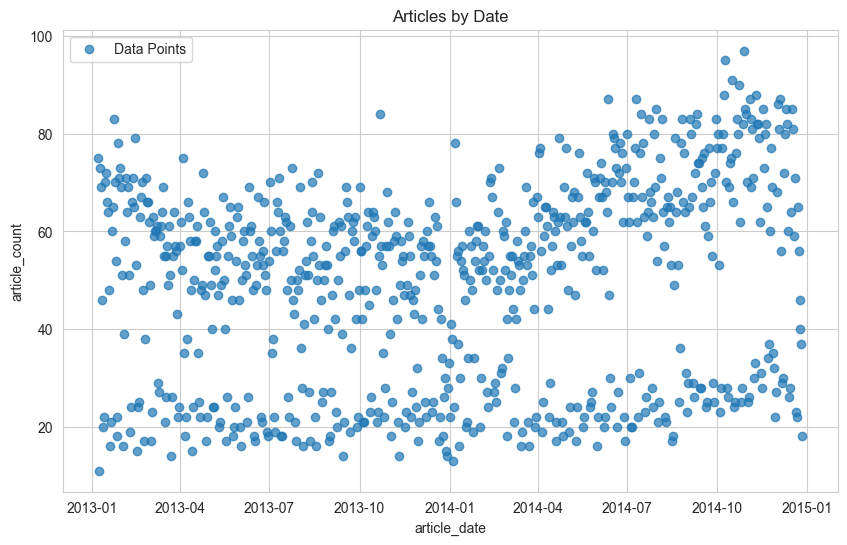

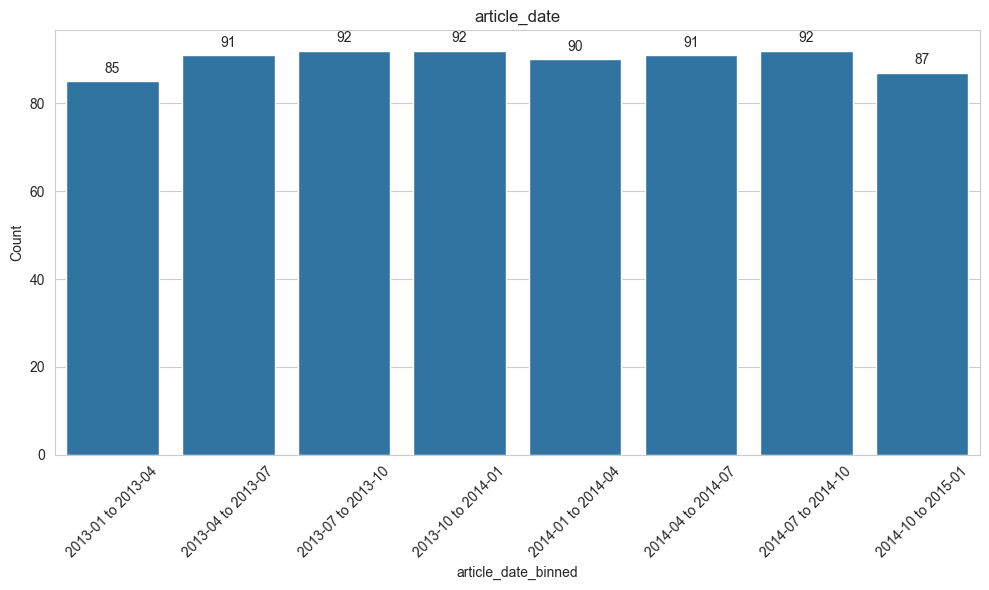

In [11]:
# Investigate 'URL'
###############################################################################################################################################################################################################
df['article_date'] = df['URL'].apply(examine_url)
print(df[['URL', 'article_date']])
print(f" No. of 'article_date' Unique Values: {df['article_date'].nunique()}") #720
# 35,680 rows of data / 720 unique dates ~= 50 articles per unqiue date. 

# Convert article_date to datetime if it's not already
df['article_date'] = pd.to_datetime(df['article_date'], errors='coerce')

# Drop any rows with NaT (if conversion failed)
df = df.dropna(subset=['article_date'])

# Group by article_date and count articles
articles_by_date = df.groupby('article_date').size().reset_index(name='article_count')

# Convert article_count to int64 if it's not already
articles_by_date['article_count'] = pd.to_numeric(articles_by_date['article_count'], errors='coerce').astype('int64')

# Create the line plot
create_scatterplot(x=articles_by_date['article_date'], y=articles_by_date['article_count'], title='Articles by Date', x_label='article_date', y_label='article_count', data=articles_by_date)

# Bin article_date into intervals 
bins = [pd.Timestamp(datetime(2013, 1, 1)), pd.Timestamp(datetime(2013, 4, 1)), pd.Timestamp(datetime(2013, 7, 1)), pd.Timestamp(datetime(2013, 10, 1)), pd.Timestamp(datetime(2014, 1, 1)), 
        pd.Timestamp(datetime(2014, 4, 1)), pd.Timestamp(datetime(2014, 7, 1)), pd.Timestamp(datetime(2014, 10, 1)), pd.Timestamp(datetime(2015, 1, 1))]# Adjust bins as needed
labels = ['2013-01 to 2013-04', '2013-04 to 2013-07', '2013-07 to 2013-10', '2013-10 to 2014-01','2014-01 to 2014-04', '2014-04 to 2014-07', '2014-07 to 2014-10', '2014-10 to 2015-01']
articles_by_date['article_date_binned'] = pd.cut(articles_by_date['article_date'], bins=bins, labels=labels, include_lowest=True)
create_countplot(x='article_date_binned', data=articles_by_date, title='article_date')
# Both graphs show that the articles were published in rather consistent pace; i.e. around 90 articles every 3 months.

###############################################################################################################################################################################################################


 No. of 'timedelta' Unique Values: 724
0        720 to 810 days
1        720 to 810 days
2        720 to 810 days
3        720 to 810 days
4        720 to 810 days
              ...       
35675       0 to 90 days
35676       0 to 90 days
35677       0 to 90 days
35678       0 to 90 days
35679       0 to 90 days
Name: timedelta_binned, Length: 35680, dtype: category
Categories (9, str): ['0 to 90 days' < '90 to 180 days' < '180 to 270 days' < '270 to 360 days' ... '450 to 540 days' < '540 to 630 days' < '630 to 720 days' < '720 to 810 days']


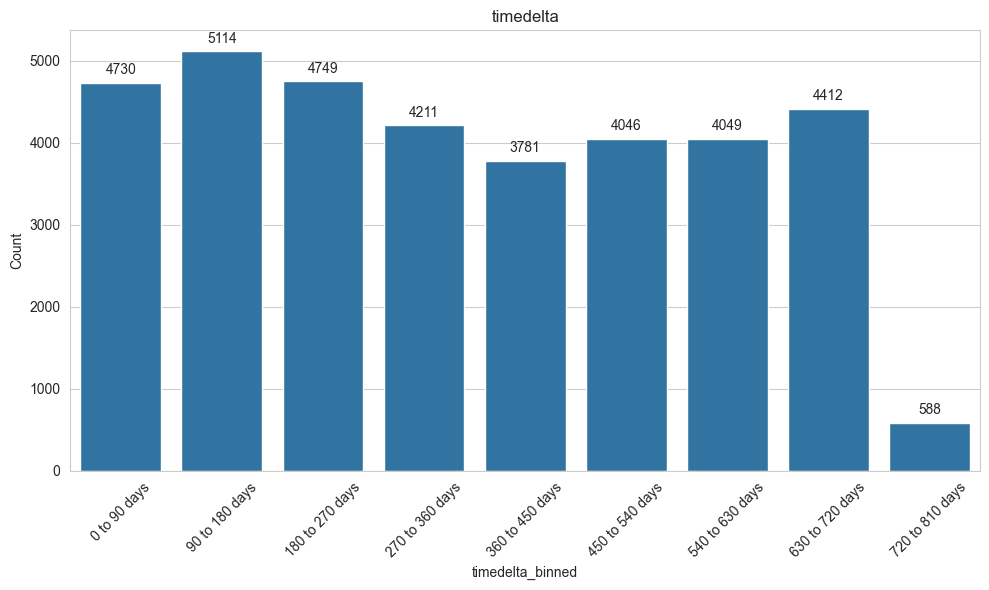

In [12]:
# Investigate 'timedelta'
###############################################################################################################################################################################################################

print(f" No. of 'timedelta' Unique Values: {df['timedelta'].nunique()}") #724 ; roughly equal to that of article_date

# Bin timedelta into intervals 
bins = [0, 90, 180, 270, 360, 450, 540, 630, 720, 810]# Adjust bins as needed
labels = ['0 to 90 days', '90 to 180 days', '180 to 270 days', '270 to 360 days', '360 to 450 days', '450 to 540 days', '540 to 630 days', '630 to 720 days', '720 to 810 days']
df['timedelta_binned'] = pd.cut(df['timedelta'], bins=bins, labels=labels, include_lowest=True)
print(df['timedelta_binned'])
create_countplot(x='timedelta_binned', data=df, title='timedelta')
# Also shows a more or less consistent pace of articles publishing; roughly 50 articles per day.

###############################################################################################################################################################################################################


 No. of 'weekday' Unique Values: 7


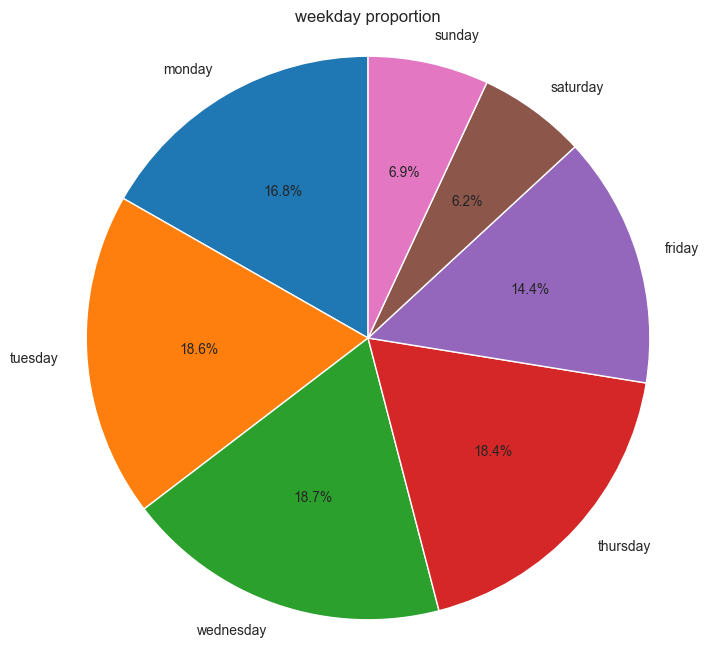

ANOVA F-Statistic: 3.052556251121725, p-value: 0.0054987520387659436


In [13]:
# Investigate 'weekday'
###############################################################################################################################################################################################################
print(f" No. of 'weekday' Unique Values: {df['weekday'].nunique()}") #724 ; roughly equal to that of article_date

# Use a different variable name to avoid shadowing the built-in dict
weekday_map = {'monday': 1, 'tuesday': 2, 'wednesday': 3, 'thursday': 4, 'friday': 5, 'saturday': 6, 'sunday': 7}

# Replace weekday strings with integers, ensuring case sensitivity is handled
df['weekday_enum'] = df['weekday'].str.lower().replace(weekday_map)

# Optional: Check for unmatched values
unmatched = df[~df['weekday_enum'].isin(weekday_map.values()) & df['weekday_enum'].notna()]
if not unmatched.empty:
    print("Unmatched weekday values found:")
    print(unmatched['weekday_enum'].unique())

weekday_counts = df['weekday_enum'].value_counts().sort_index()  
data = weekday_counts.values  
labels = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday'] 

create_pie_chart(data=data, labels=labels, title='weekday proportion')
# Show a slight tendency for articles to be published from Monday to Thursday compared to Friday and the weekend (minimal). 

# Example with 'shares' as continuous and 'weekday_enum' as categorical
groups = [df[df['weekday_enum'] == i]['shares'].dropna() for i in range(1, 8)]  # Assuming weekday is mapped to 1-7
statistic, p_value = f_oneway(*groups)
print(f"ANOVA F-Statistic: {statistic}, p-value: {p_value}")
# Results: ANOVA F-Statistic: 3.0525562511217257, p-value: 0.005498752038679132
# There is a significant difference in the means of the continuous variable (e.g., 'shares') across the categories of the categorical variable (e.g., 'weekday'). Practical Significance: The F-statistic (3.05) is moderate, 
# indicating some variability between groups.

###############################################################################################################################################################################################################


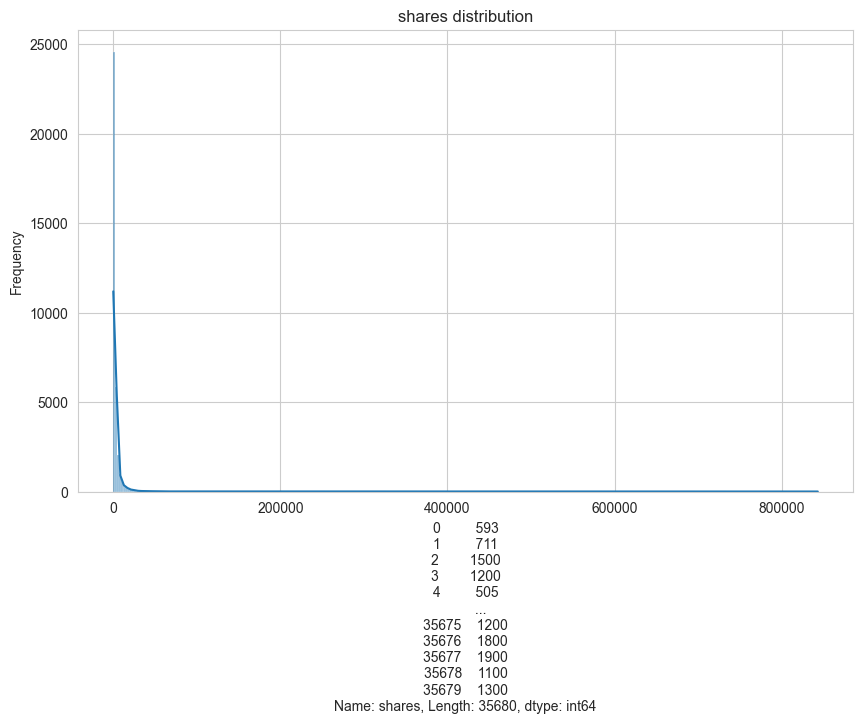

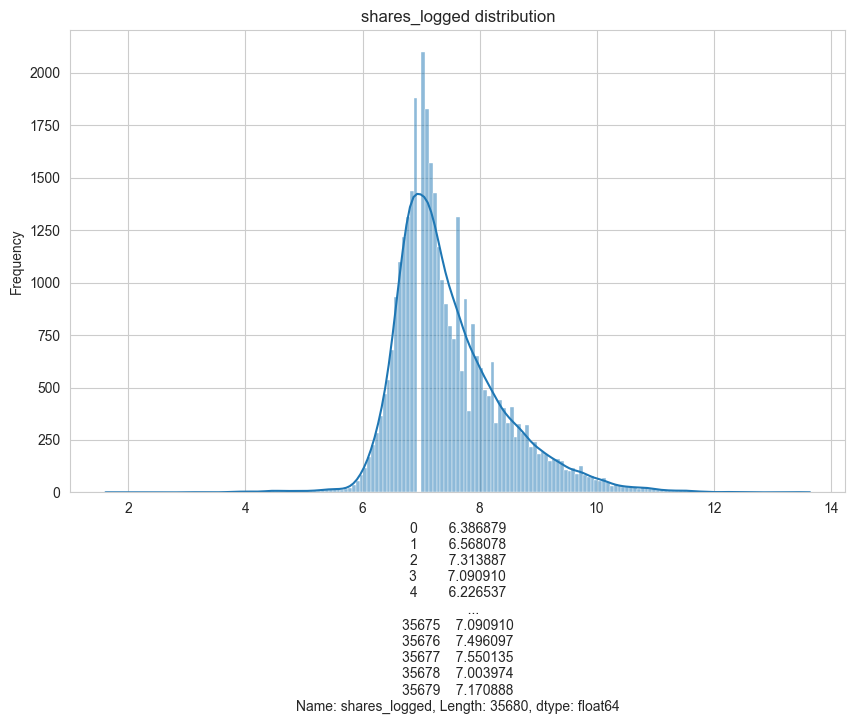

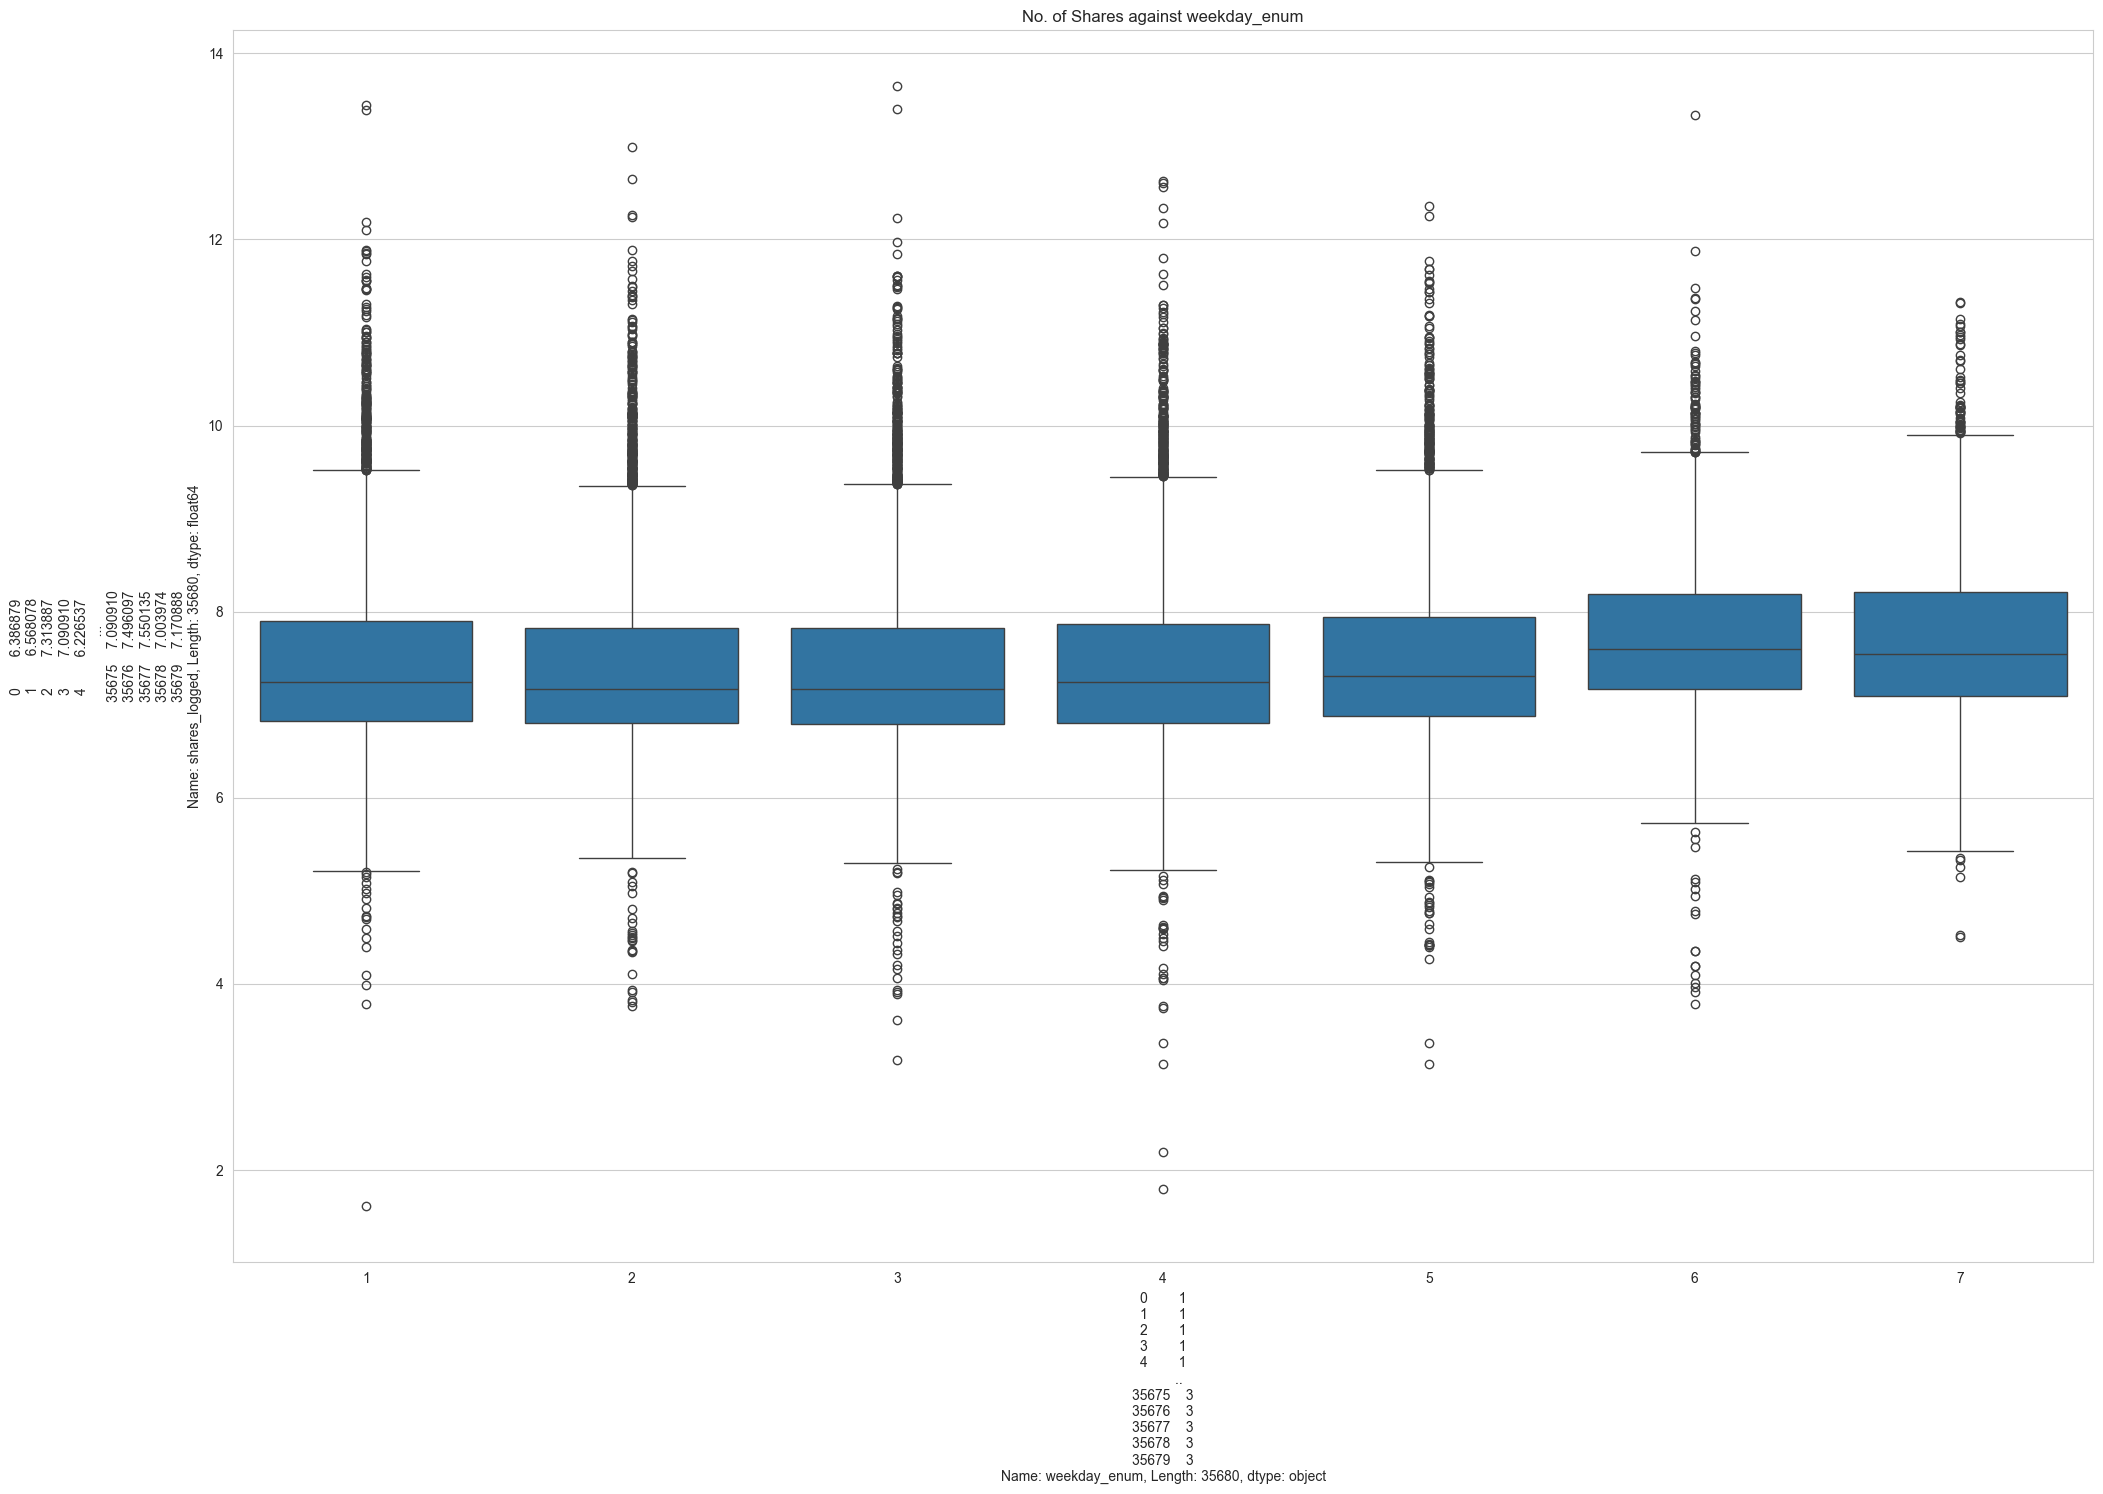

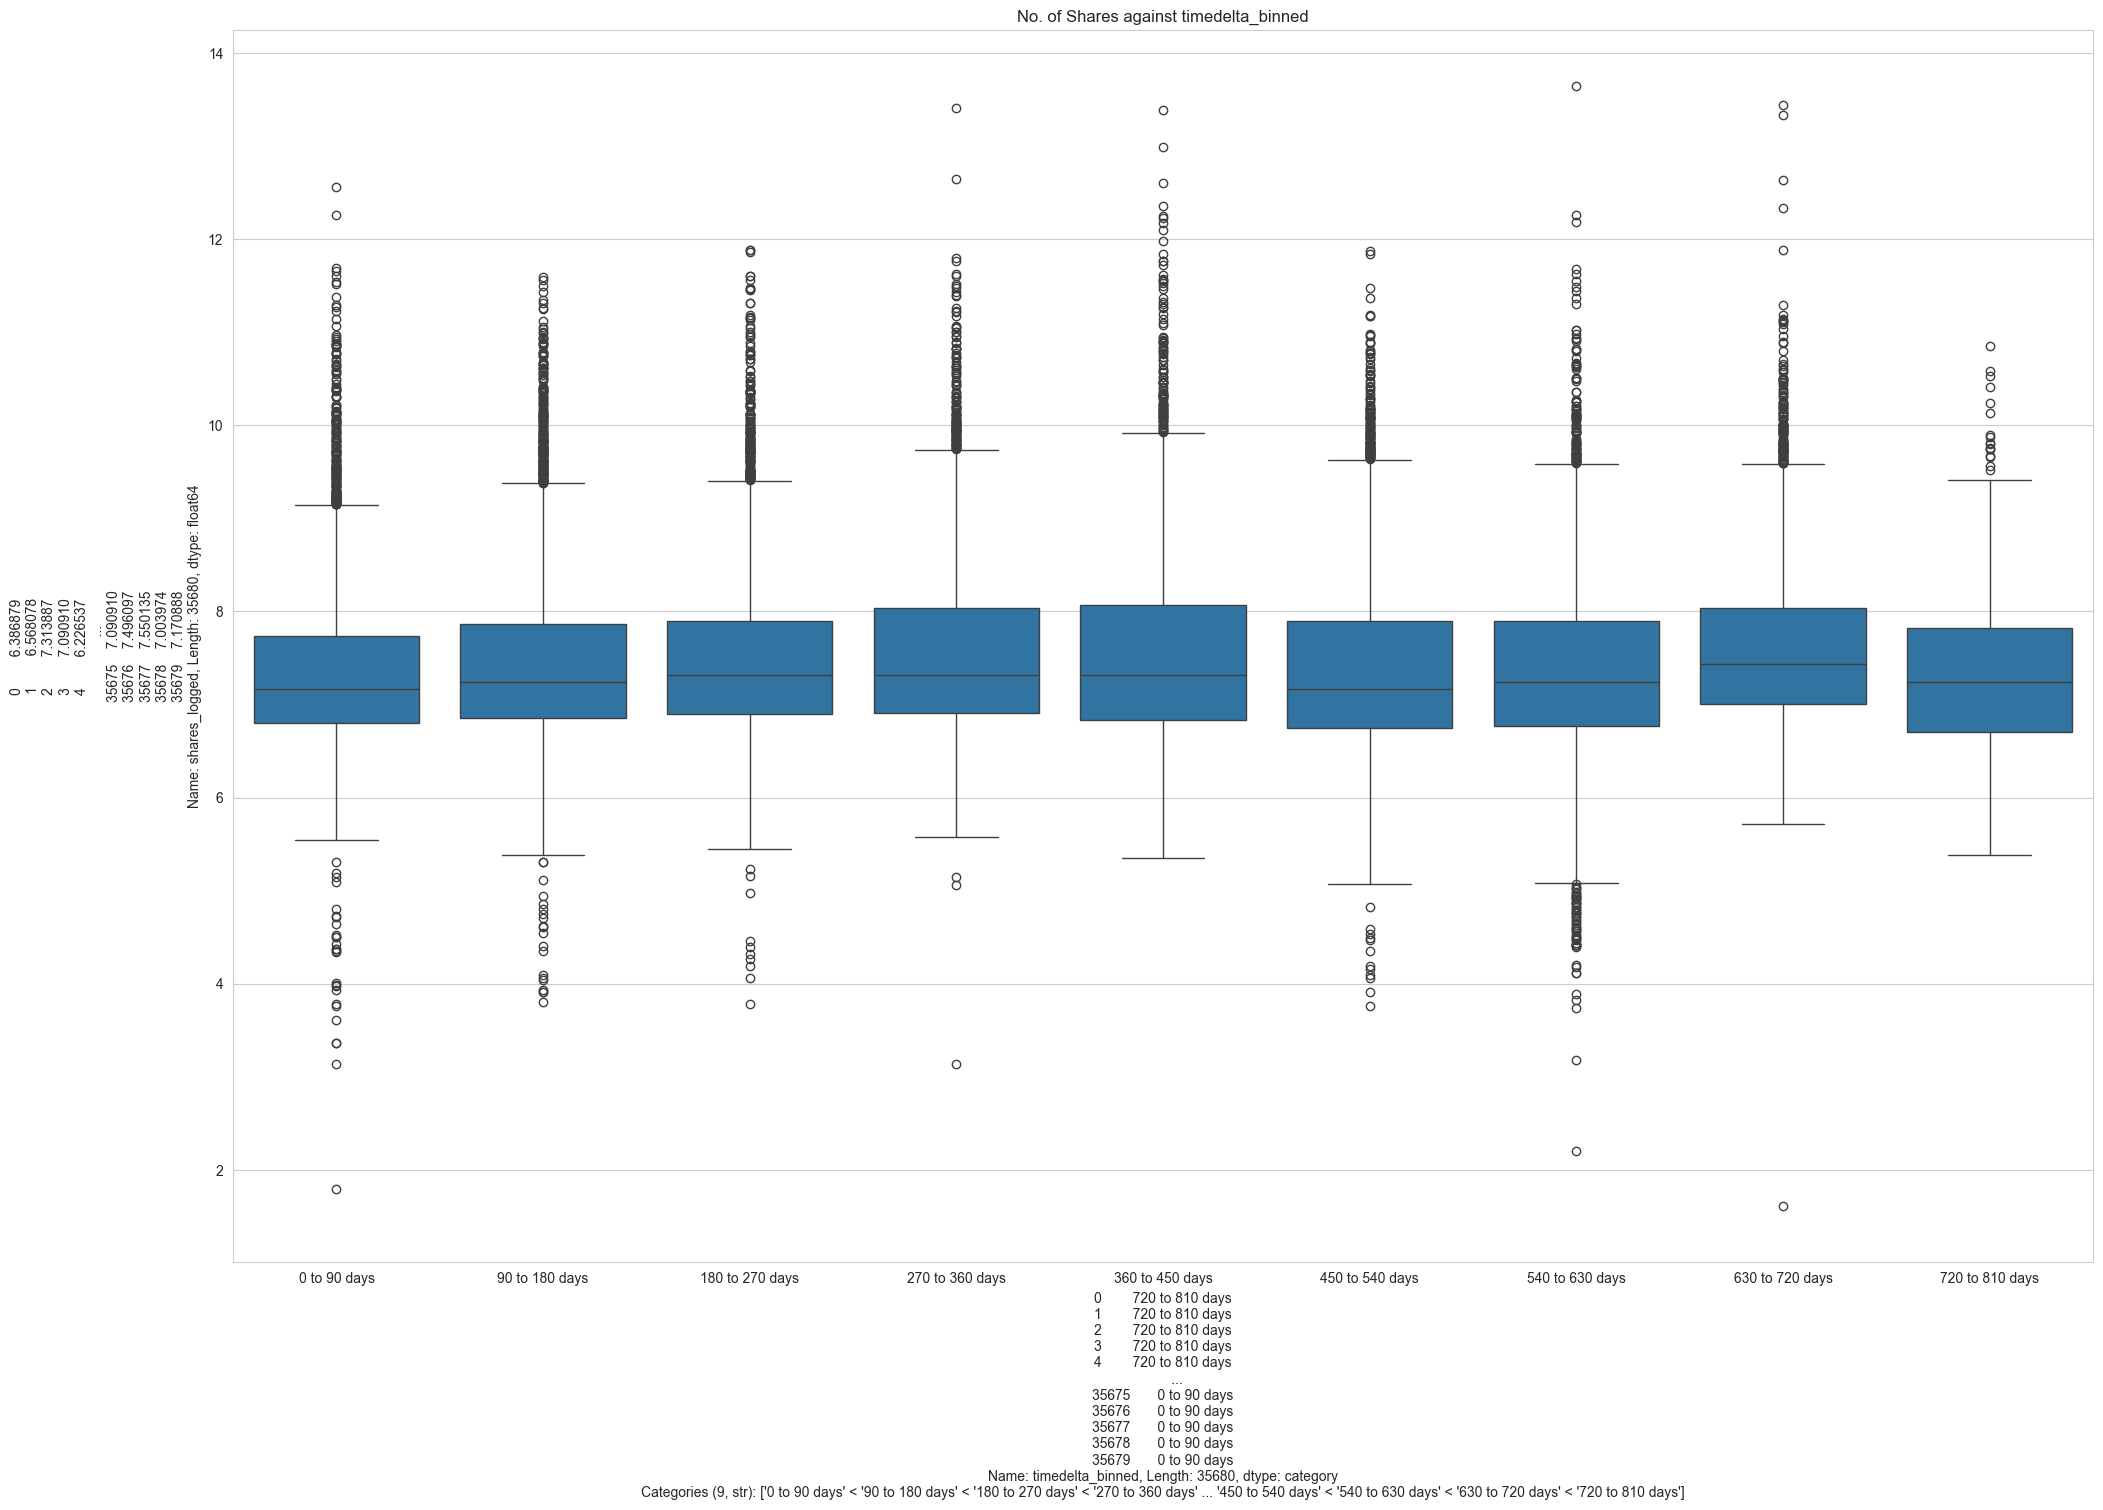

In [14]:
# Investigate 'shares'
###############################################################################################################################################################################################################

create_histogram(x=df['shares'], data=df, title='shares distribution', xlabel=None)
# Shows almost a flat line, except that a few shares like 2 and 3 had 1,000+ frequencies that occured. 

# Apply clipping
# Q1 = df['shares'].quantile(0.25)
# Q3 = df['shares'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# df['shares_clipped'] = df['shares'].clip(lower_bound, upper_bound)

df['shares_logged'] = np.log1p(df['shares'])

create_histogram(x=df['shares_logged'], data=df, title='shares_logged distribution', xlabel=None)
# Now shows a tendency for viral articles to be shared 5000+ times; it's happened in 4000+ instances. 

create_boxplot(x=df['weekday_enum'], y=df['shares_logged'], data=df, title='No. of Shares against weekday_enum')
# Shows that there is a significant tendency for more shares to occur during the weekend. 

create_boxplot(x=df['timedelta_binned'], y=df['shares_logged'], data=df, title='No. of Shares against timedelta_binned')
# Does not show much patterns except that there is a very slight tendency for shares to occur for articles published 270 to 450 days ago.

# df['shares'] would be the target variable, i.e. y = df['shares']

###############################################################################################################################################################################################################


 No. of 'n_tokens_content' Unique Values: 2324


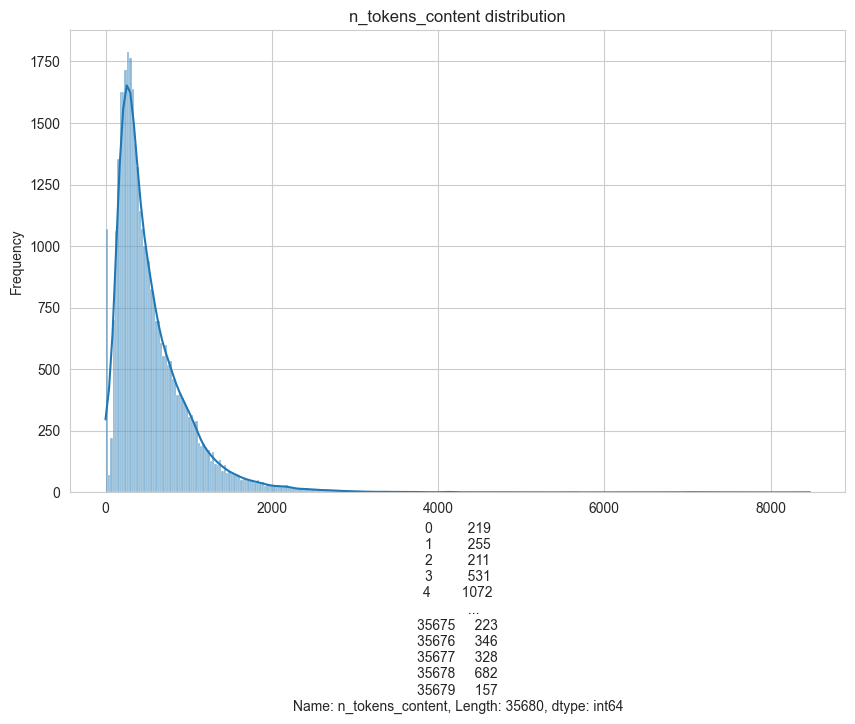

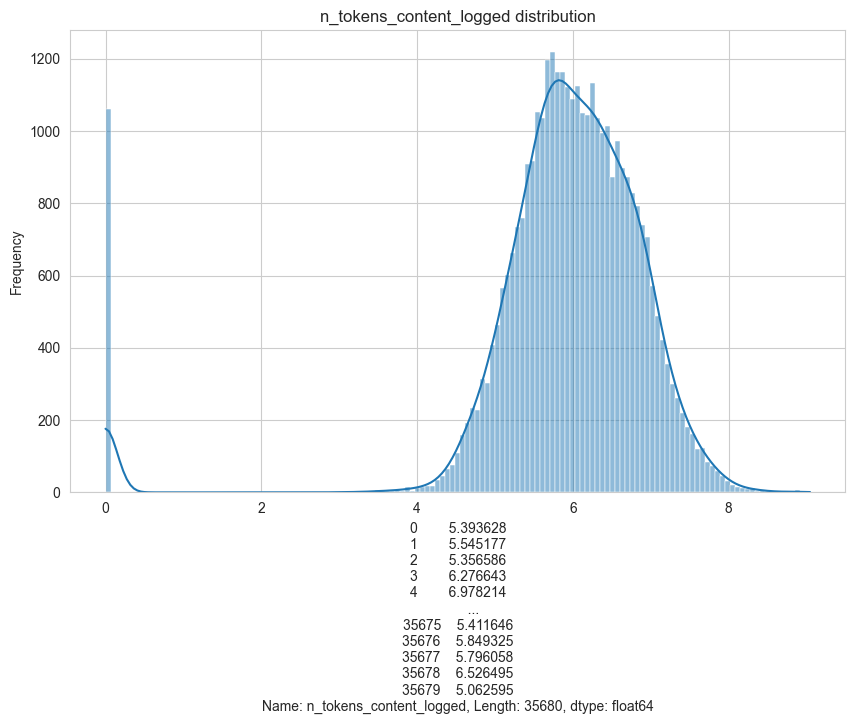

C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


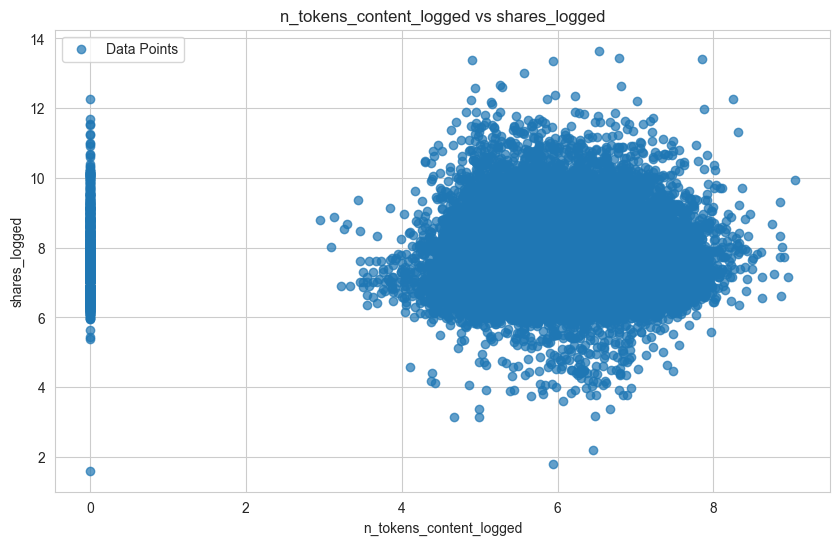

Pearson Correlation: -0.021842992200728256, p-value: 3.686409687623444e-05
Spearman Correlation: 0.008885639109045449, p-value: 0.09326980693707912


In [15]:
# Investigate 'n_tokens_content'
###############################################################################################################################################################################################################
print(f" No. of 'n_tokens_content' Unique Values: {df['n_tokens_content'].nunique()}") #2324 unique values

# Apply clipping
# Q1 = df['n_tokens_content'].quantile(0.25)
# Q3 = df['n_tokens_content'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# df['n_tokens_content_clipped'] = df['n_tokens_content'].clip(lower_bound, upper_bound)

df['n_tokens_content_logged'] = np.log1p(df['n_tokens_content'])

create_histogram(x=df['n_tokens_content'], data=df, title='n_tokens_content distribution', xlabel=None)
# Shows a left-slanted normal distribution centred about 360 words, and the tail extends to 9000 words.

create_histogram(x=df['n_tokens_content_logged'], data=df, title='n_tokens_content_logged distribution', xlabel=None)
# Shows a left-slanted normal distribution centred about 360 words, with a curious hook at 1400 words. 

create_scatterplot(x=df['n_tokens_content_logged'], y=df['shares_logged'], data=df, x_label='n_tokens_content_logged', y_label='shares_logged', title='n_tokens_content_logged vs shares_logged')

correlation, p_value = pearsonr(df['n_tokens_content_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.0031049221906531664, p-value: 0.5575568363773401

correlation, p_value = spearmanr(df['n_tokens_content_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.008885639109045449, p-value: 0.09326980693707915

# Almost no relationship at all between n_tokens_content and shares. 
###############################################################################################################################################################################################################


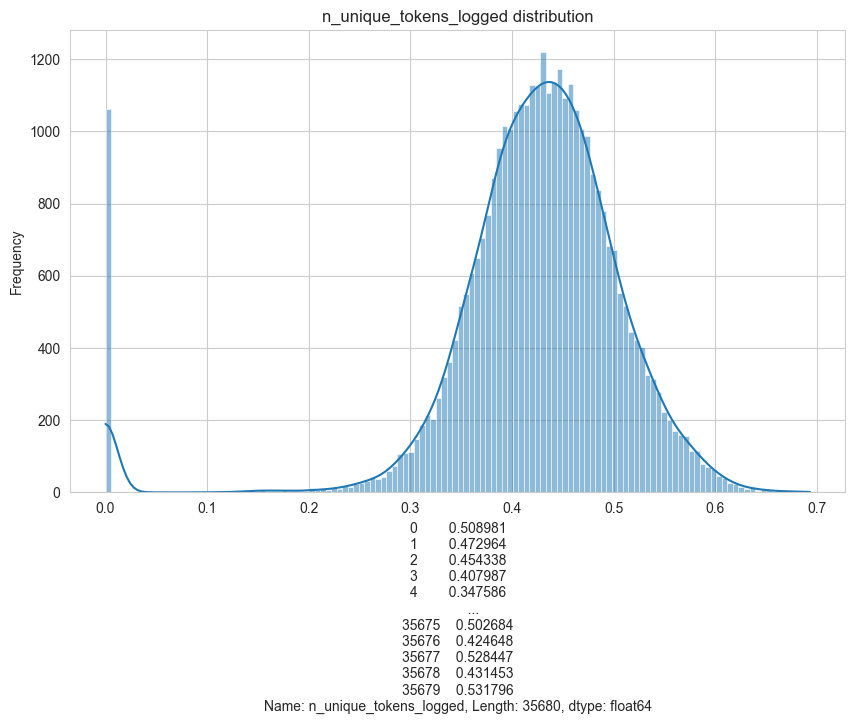

C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


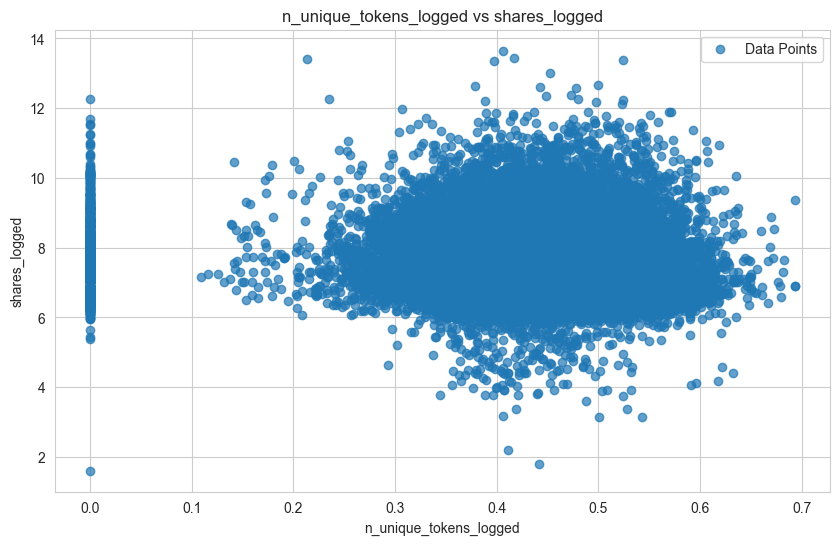

Pearson Correlation: -0.038416816600076516, p-value: 3.898602054052091e-13
Spearman Correlation: -0.0427748196891861, p-value: 6.308057391451556e-16


In [16]:
# Investigate 'n_unique_tokens'
###############################################################################################################################################################################################################
# Apply clipping
# Q1 = df['n_unique_tokens'].quantile(0.25)
# Q3 = df['n_unique_tokens'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# df['n_unique_tokens_clipped'] = df['n_unique_tokens'].clip(lower_bound, upper_bound)

df['n_unique_tokens_logged'] = np.log1p(df['n_unique_tokens'])

create_histogram(x=df['n_unique_tokens_logged'], data=df, title='n_unique_tokens_logged distribution', xlabel=None)
# Shows a normal distribution with spikes in both ends. 

create_scatterplot(x=df['n_unique_tokens_logged'], y=df['shares_logged'], data=df, x_label='n_unique_tokens_logged', y_label='shares_logged', title='n_unique_tokens_logged vs shares_logged')

correlation, p_value = pearsonr(df['n_unique_tokens_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: -0.003962814121727463, p-value: 0.45414739174558405

correlation, p_value = spearmanr(df['n_unique_tokens_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: -0.042777234704116776, p-value: 6.284463380204408e-16

# Almost no relationship at all between n_unique_tokens and shares. 
###############################################################################################################################################################################################################


       n_non_stop_words  n_non_stop_unique_tokens
0        0.999999992000            0.815384609000
1        0.999999993000            0.791946303000
2        0.999999992000            0.663865541000
3        0.999999997000            0.665634673000
4        0.999999999000            0.540889526000
...                 ...                       ...
35675    0.999999992000            0.825757570000
35676    0.999999995000            0.684782605000
35677    0.999999994000            0.885057466000
35678    0.999999998000            0.692660549000
35679    0.999999989000            0.846153837000

[35680 rows x 2 columns]
Number of entries with n_non_stop_words = 0: 1061
Number of entries with n_non_stop_words > 0: 34619
Number of entries with n_non_stop_unique_tokens = 0: 1061
Number of entries with n_non_stop_unique_tokens > 0: 34619


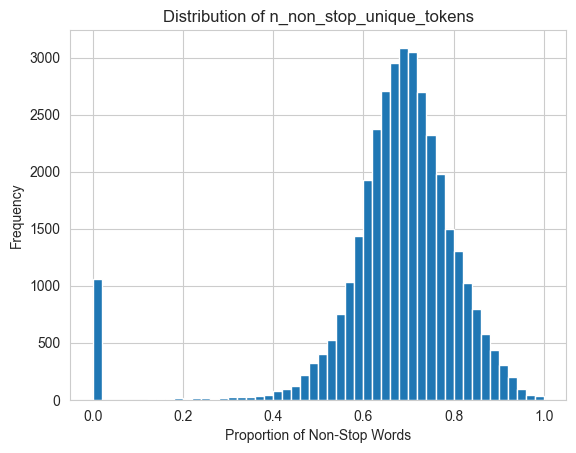

In [17]:
# Investigate 'n_non_stop_words' and n_non_stop_unique_tokens
###############################################################################################################################################################################################################
# On examination of this column, it seems that it is a float with 12 decimal places. 

# Read the CSV with high precision
high_precision_df = pd.read_csv('./data/mini_project_1_data.csv', dtype={'n_non_stop_words': float, 'n_non_stop_unique_tokens': float}) 

# Display with more decimal places
pd.set_option('display.float_format', '{:.12f}'.format)  # Show 12 decimal places
print(df[['n_non_stop_words', 'n_non_stop_unique_tokens']])

# Separate entries with n_non_stop_words = 0
df_zero = df[df['n_non_stop_words'] == 0]
df_non_zero = df[df['n_non_stop_words'] > 0]

# Display the number of entries
print(f"Number of entries with n_non_stop_words = 0: {len(df_zero)}")
print(f"Number of entries with n_non_stop_words > 0: {len(df_non_zero)}")

# Optional: Save to new CSV files
# df_zero.to_csv('n_non_stop_words_zero.csv', index=False)
# df_non_zero.to_csv('n_non_stop_words_non_zero.csv', index=False)

# Shows that there are 1061 datapoints with 0 non_stop words, which is quite strange. There should be no sentences having no non_stop words. 

# Separate entries with n_non_stop_words = 0
df_zero_unique = df[df['n_non_stop_unique_tokens'] == 0]
df_non_zero_unique = df[df['n_non_stop_unique_tokens'] > 0]

# Display the number of entries
print(f"Number of entries with n_non_stop_unique_tokens = 0: {len(df_zero_unique)}")
print(f"Number of entries with n_non_stop_unique_tokens > 0: {len(df_non_zero_unique)}")
# Also shows that there are 1061 df_zero_unique. The distribution is exactly the same. 

# Due to much higher variety of n_non_stop_unique_tokens data points, analyze n_non_stop_unique_tokens. 

df['n_non_stop_unique_tokens'].hist(bins=50)
plt.title('Distribution of n_non_stop_unique_tokens')
plt.xlabel('Proportion of Non-Stop Words')
plt.ylabel('Frequency')
plt.show()

# Shows a normal distribution centred around 0.7 but with a hook at 0, going with the 1061 non-zeros. Those probably are input errors. I would KNN-impute these values.

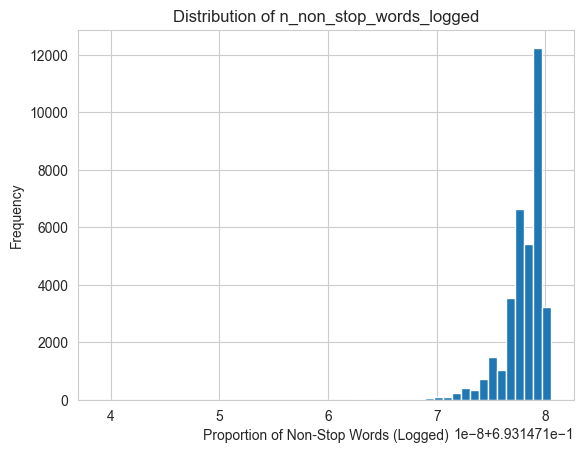

C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


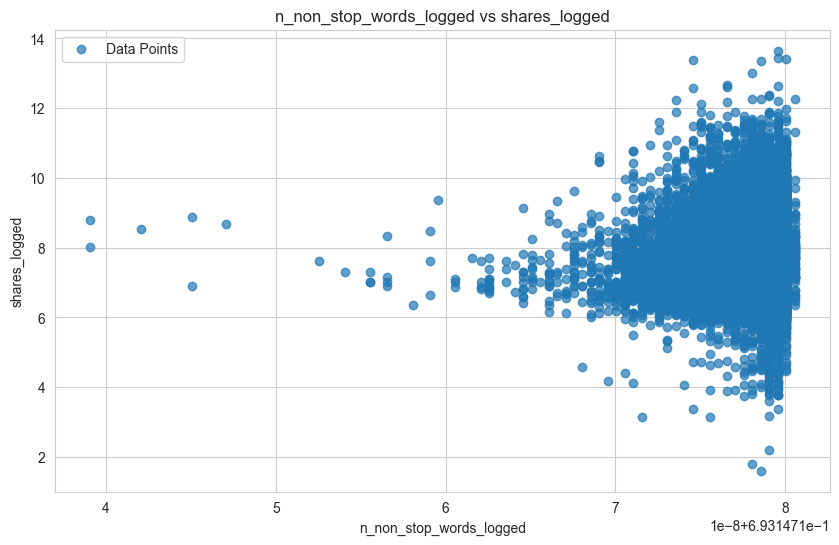

Pearson Correlation: -0.000722623681171904, p-value: 0.8914317878595308
Spearman Correlation: 0.014719181548232995, p-value: 0.005429506690439164


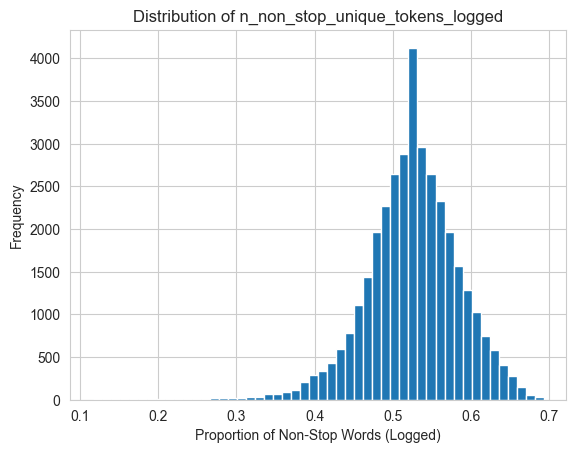

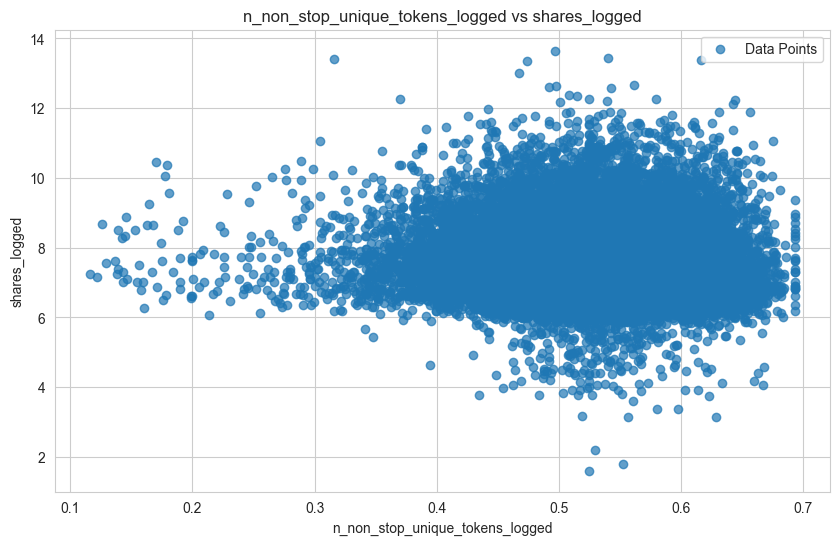

Pearson Correlation: -0.051955725527597856, p-value: 9.208400677179367e-23
Spearman Correlation: -0.06536877089332895, p-value: 4.2805585872955276e-35


In [18]:
df['n_non_stop_words'] = df['n_non_stop_words'].replace(0, df['n_non_stop_words'].median())
df['n_non_stop_unique_tokens'] = df['n_non_stop_unique_tokens'].replace(0, df['n_non_stop_unique_tokens'].median())

df['n_non_stop_words_logged'] = np.log1p(df['n_non_stop_words'])
df['n_non_stop_unique_tokens_logged'] = np.log1p(df['n_non_stop_unique_tokens'])

df['n_non_stop_words_logged'].hist(bins=50)
plt.title('Distribution of n_non_stop_words_logged')
plt.xlabel('Proportion of Non-Stop Words (Logged)')
plt.ylabel('Frequency')
plt.show()

create_scatterplot(x=df['n_non_stop_words_logged'], y=df['shares_logged'], data=df, x_label='n_non_stop_words_logged', y_label='shares_logged', title='n_non_stop_words_logged vs shares_logged')

correlation, p_value = pearsonr(df['n_non_stop_words_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")

correlation, p_value = spearmanr(df['n_non_stop_words_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")

df['n_non_stop_unique_tokens_logged'].hist(bins=50)
plt.title('Distribution of n_non_stop_unique_tokens_logged')
plt.xlabel('Proportion of Non-Stop Words (Logged)')
plt.ylabel('Frequency')
plt.show()

create_scatterplot(x=df['n_non_stop_unique_tokens_logged'], y=df['shares_logged'], data=df, x_label='n_non_stop_unique_tokens_logged', y_label='shares_logged', title='n_non_stop_unique_tokens_logged vs shares_logged')

correlation, p_value = pearsonr(df['n_non_stop_unique_tokens_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")

correlation, p_value = spearmanr(df['n_non_stop_unique_tokens_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")

# Almost no relationship at all between n_non_stop_words, n_non_stop_unique_tokens and shares. 
###############################################################################################################################################################################################################


 No. of 'num_hrefs' Unique Values: 128
count   35680.000000000000
mean       10.808436098655
std        11.153904570718
min         0.000000000000
25%         4.000000000000
50%         8.000000000000
75%        13.000000000000
max       304.000000000000
Name: num_hrefs, dtype: float64


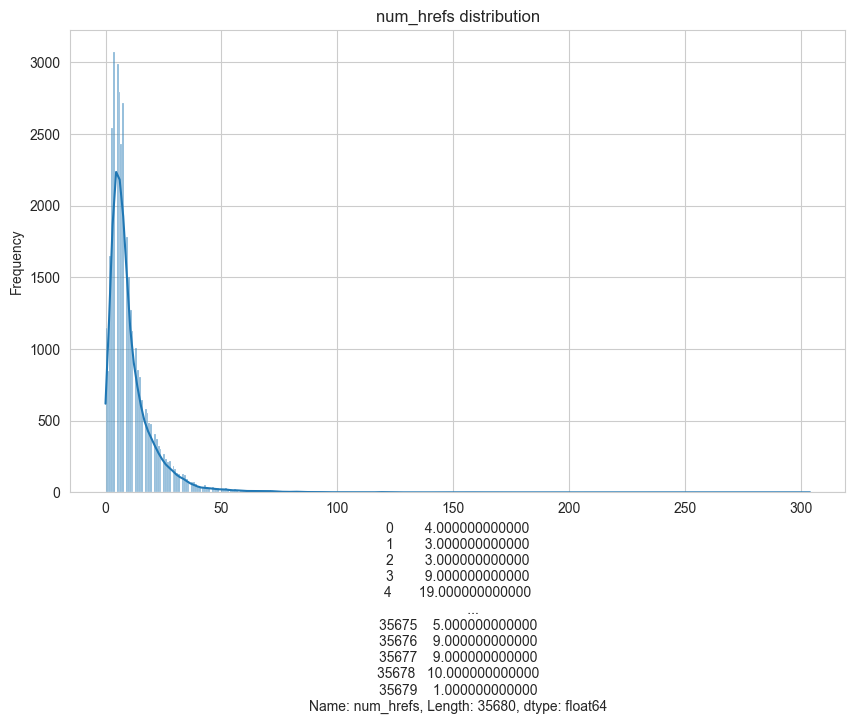

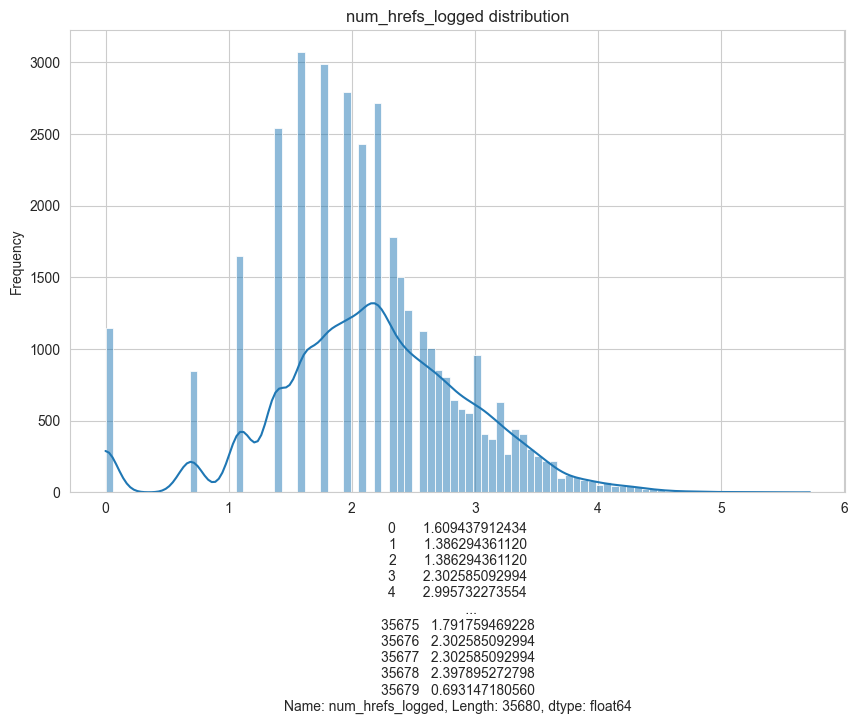

R-squared: 0.006373115254893036
Pearson Correlation: 0.07983179350918378, p-value: 1.5443108082854314e-51
Spearman Correlation: 0.08870993949796085, p-value: 2.9339075208920526e-63


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


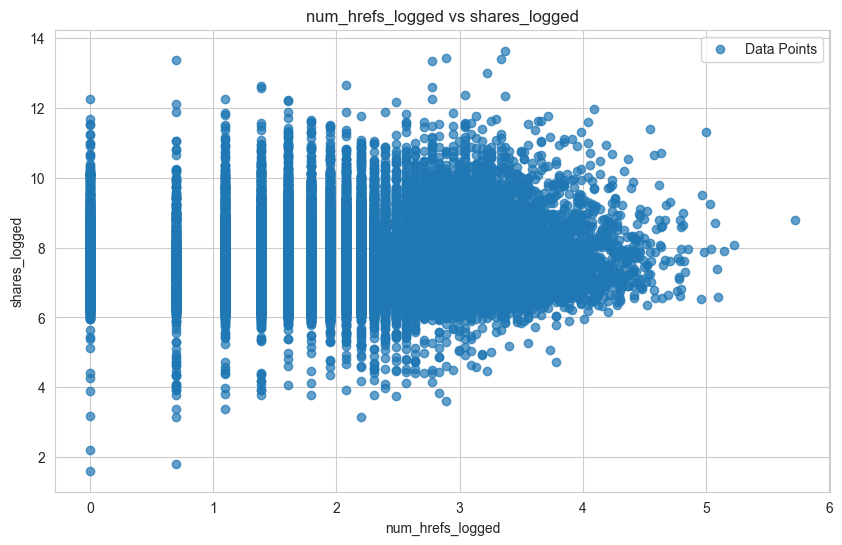

In [19]:
# Investigate 'num_hrefs'.
###############################################################################################################################################################################################################
print(f" No. of 'num_hrefs' Unique Values: {df['num_hrefs'].nunique()}") #128 unique values
# Earlier analysis showed there were 721 NaN values.

# Calculate the median of num_hrefs and replace NaN values
median_value = df['num_hrefs'].median()
df['num_hrefs'] = df['num_hrefs'].fillna(median_value)

print(df['num_hrefs'].describe())

create_histogram(x=df['num_hrefs'], data=df, title='num_hrefs distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a very long positive tail. 

# Apply clipping
# Q1 = df['num_hrefs'].quantile(0.25)
# Q3 = df['num_hrefs'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# df['num_hrefs_clipped'] = df['num_hrefs'].clip(lower_bound, upper_bound)

df['num_hrefs_logged'] = np.log1p(df['num_hrefs'])

create_histogram(x=df['num_hrefs_logged'], data=df, title='num_hrefs_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a long positive tail. 

X = df['num_hrefs_logged'].values.reshape(-1, 1) # type: ignore
y = df['shares_logged'].values
model = LinearRegression().fit(X, y) # type: ignore
r_squared = model.score(X, y) # type: ignore
print(f"R-squared: {r_squared}")
# R-squared: 0.002184725207706517；num_hrefs is a very weak predictor of shares. 

correlation, p_value = pearsonr(df['num_hrefs_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.0467410441443784, p-value: 1.0144619789031347e-18

correlation, p_value = spearmanr(df['num_hrefs_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.08854534441929522, p-value: 4.966715778001704e-63

# The correlations (0.0467 Pearson, 0.0885 Spearman) are weak but statistically significant due to the large sample size. The Spearman value suggests a slight monotonic increase in 'shares_logged' with 'n_non_stop_words', 
# but the practical impact is negligible.

create_scatterplot(x=df['num_hrefs_logged'], y=df['shares_logged'], data=df, x_label='num_hrefs_logged', y_label='shares_logged', title='num_hrefs_logged vs shares_logged')
# Shows no overall pattern at all. 
###############################################################################################################################################################################################################


 No. of 'num_self_hrefs' Unique Values: 57
count   35680.000000000000
mean        3.276821748879
std         3.795335954105
min         0.000000000000
25%         1.000000000000
50%         3.000000000000
75%         4.000000000000
max       116.000000000000
Name: num_self_hrefs, dtype: float64


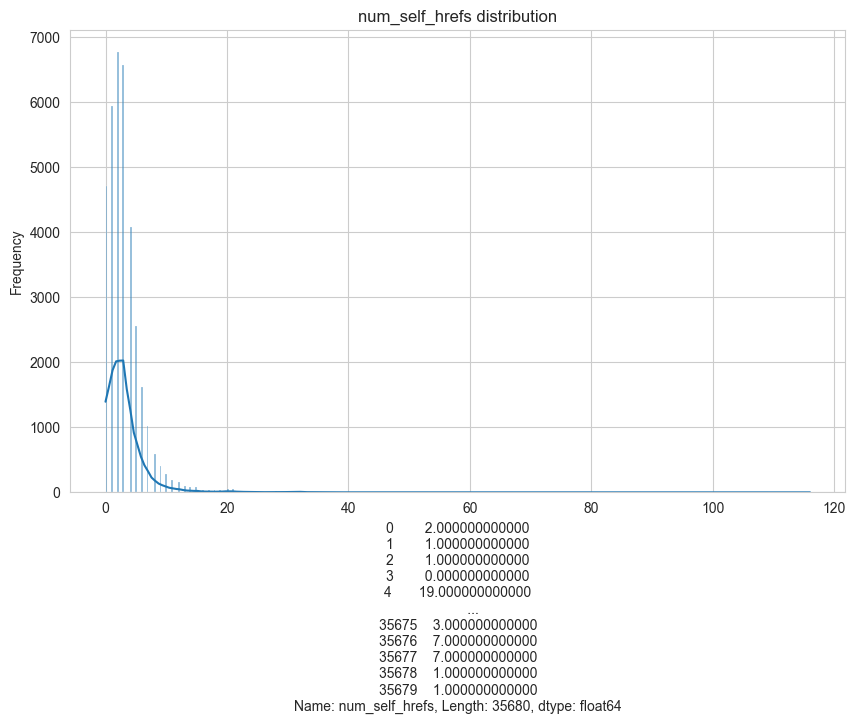

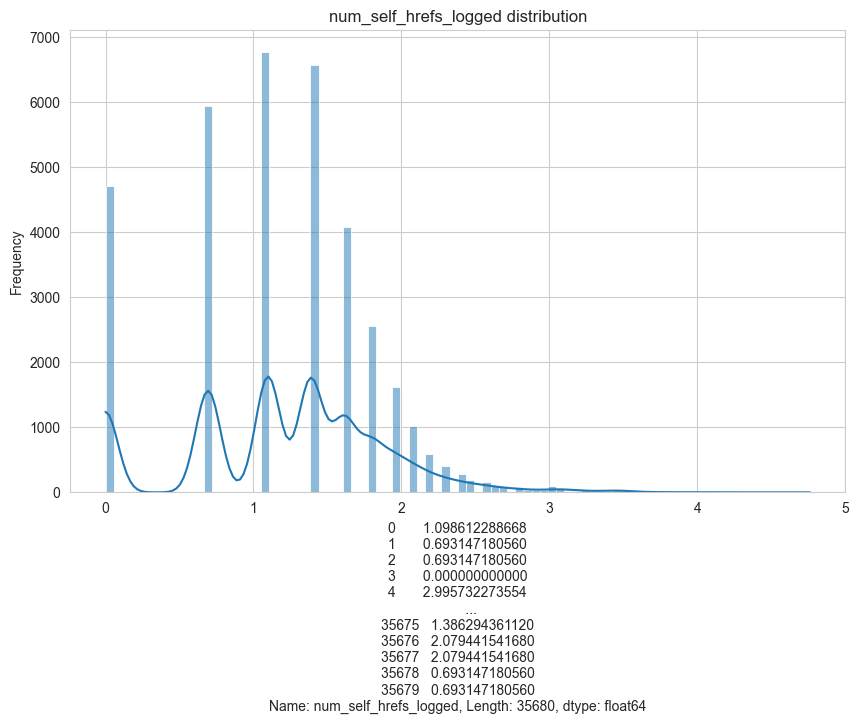

Pearson Correlation: 0.03907109418099027, p-value: 1.55043744566737e-13
Spearman Correlation: 0.03586129815862932, p-value: 1.2368848766318153e-11


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


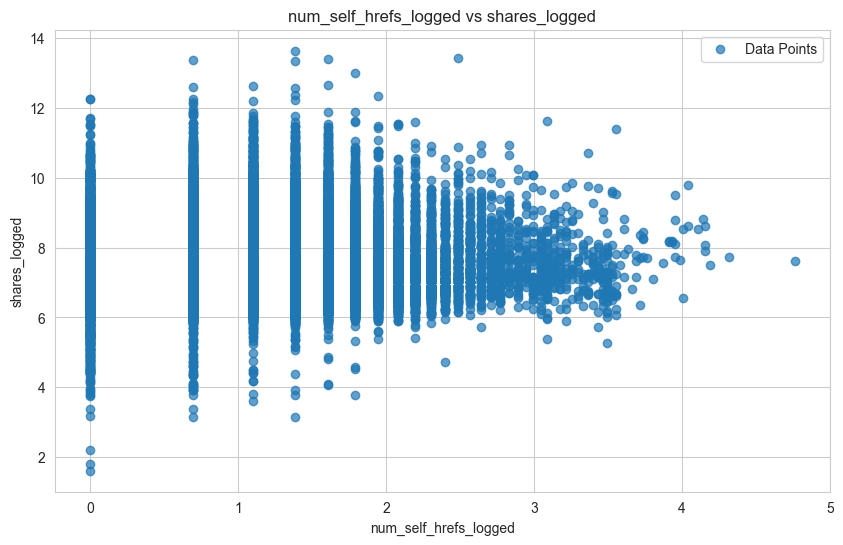

In [20]:
# Investigate 'num_self_hrefs'.
###############################################################################################################################################################################################################
print(f" No. of 'num_self_hrefs' Unique Values: {df['num_self_hrefs'].nunique()}") #57 unique values
# Earlier analysis showed there were 721 NaN values.

# Calculate the median of num_hrefs and replace NaN values
median_value = df['num_self_hrefs'].median()
df['num_self_hrefs'] = df['num_self_hrefs'].fillna(median_value)

print(df['num_self_hrefs'].describe())

create_histogram(x=df['num_self_hrefs'], data=df, title='num_self_hrefs distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a very long positive tail. 

# Apply clipping
# Q1 = df['num_self_hrefs'].quantile(0.25)
# Q3 = df['num_self_hrefs'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# df['num_self_hrefs_clipped'] = df['num_self_hrefs'].clip(lower_bound, upper_bound)

df['num_self_hrefs_logged'] = np.log1p(df['num_self_hrefs'])

create_histogram(x=df['num_self_hrefs_logged'], data=df, title='num_self_hrefs_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a long positive tail. 

correlation, p_value = pearsonr(df['num_self_hrefs_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: -0.0033345341358016955, p-value: 0.5287960988369079; no statistically significant linear relationship between the two variables, and the effect size is practically negligible.

correlation, p_value = spearmanr(df['num_self_hrefs_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.035740676069066044, p-value: 1.4478809625723156e-11; indicates a statistically significant but very weak positive monotonic relationship between the variables. The practical impact is minimal due to 
# the small effect size.

create_scatterplot(x=df['num_self_hrefs_logged'], y=df['shares_logged'], data=df, x_label='num_self_hrefs_logged', y_label='shares_logged', title='num_self_hrefs_logged vs shares_logged')
# Shows no overall pattern at all. 
###############################################################################################################################################################################################################


 No. of 'num_imgs' Unique Values: 89
count   35680.000000000000
mean        4.373290358744
std         8.122881108515
min         0.000000000000
25%         1.000000000000
50%         1.000000000000
75%         4.000000000000
max       128.000000000000
Name: num_imgs, dtype: float64


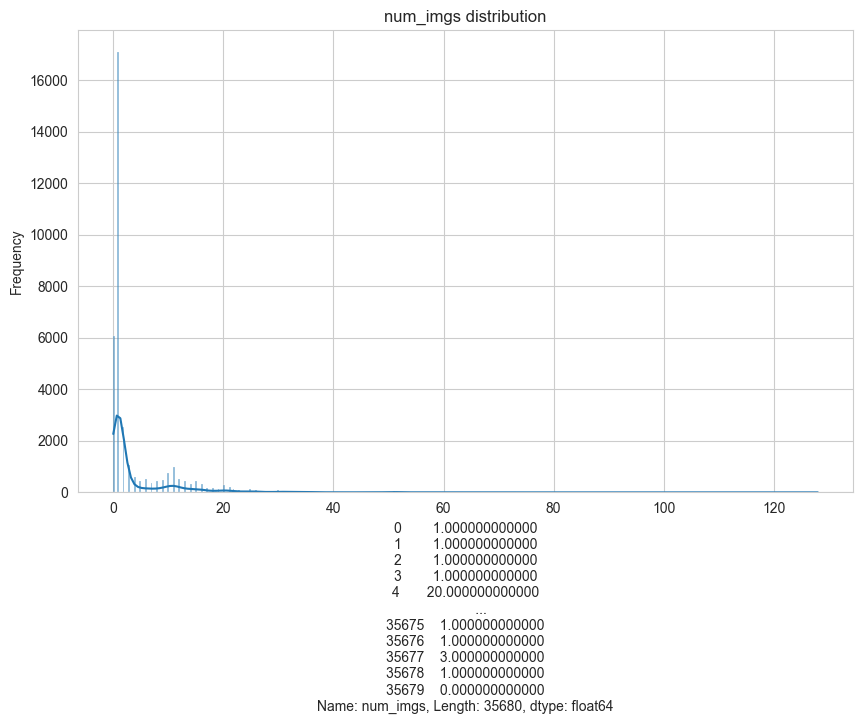

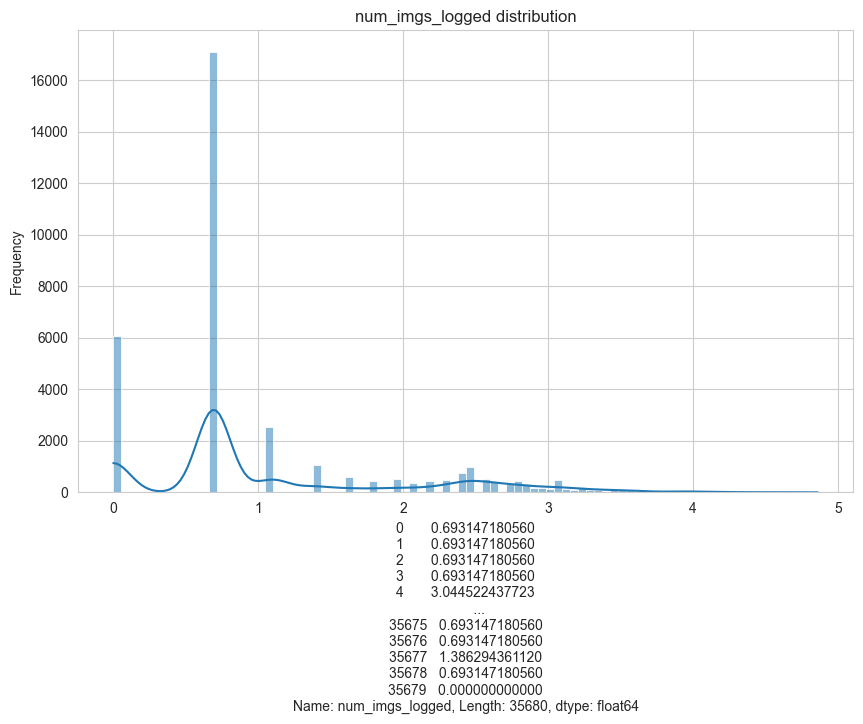

Pearson Correlation: 0.09615840806678061, p-value: 4.704771005997145e-74
Spearman Correlation: 0.0798755055553945, p-value: 1.3616529899899263e-51


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


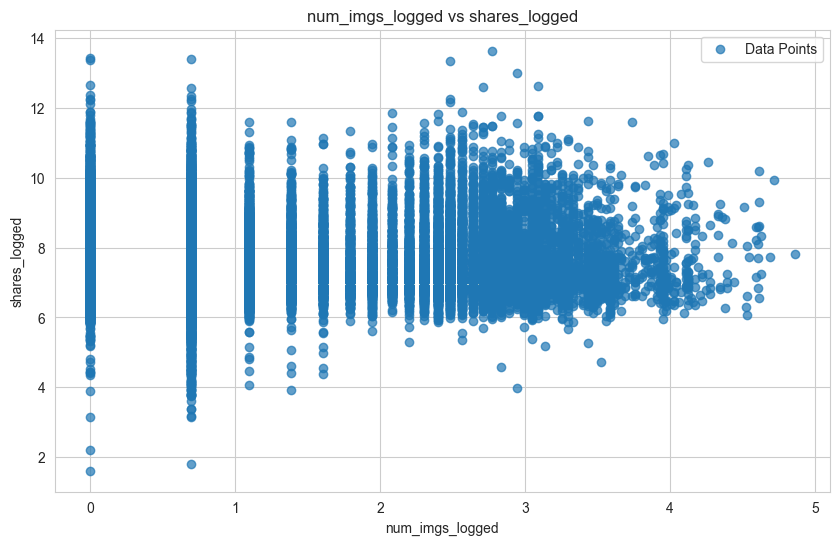

In [21]:
# Investigate 'num_imgs'.
###############################################################################################################################################################################################################
print(f" No. of 'num_imgs' Unique Values: {df['num_imgs'].nunique()}") #89 unique values
# Earlier analysis showed there were 698 NaN values.

# Calculate the median of num_hrefs and replace NaN values
median_value = df['num_imgs'].median()
df['num_imgs'] = df['num_imgs'].fillna(median_value)

print(df['num_imgs'].describe())

create_histogram(x=df['num_imgs'], data=df, title='num_imgs distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a very long positive tail. 

df['num_imgs_logged'] = np.log1p(df['num_imgs'])

create_histogram(x=df['num_imgs_logged'], data=df, title='num_imgs_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a long positive tail with a hook due to the clipping.

correlation, p_value = pearsonr(df['num_imgs_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: -0.0033345341358016955, p-value: 0.5287960988369079; no statistically significant linear relationship between the two variables, and the effect size is practically negligible.

correlation, p_value = spearmanr(df['num_imgs_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.035740676069066044, p-value: 1.4478809625723156e-11; indicates a statistically significant but very weak positive monotonic relationship between the variables. The practical impact is minimal due to 
# the small effect size.

create_scatterplot(x=df['num_imgs_logged'], y=df['shares_logged'], data=df, x_label='num_imgs_logged', y_label='shares_logged', title='num_imgs_logged vs shares_logged')
# Shows no overall pattern at all. 
###############################################################################################################################################################################################################


np.int64(16755)

count   18925.000000000000
mean        1.286446499339
std         4.148188833012
min         0.000000000000
25%         0.000000000000
50%         0.000000000000
75%         1.000000000000
max        91.000000000000
Name: num_videos, dtype: float64

 No. of 'num_imgs' Unique Values: 46
count   35680.000000000000
mean        0.682343049327
std         3.088525773722
min         0.000000000000
25%         0.000000000000
50%         0.000000000000
75%         0.000000000000
max        91.000000000000
Name: num_videos, dtype: float64


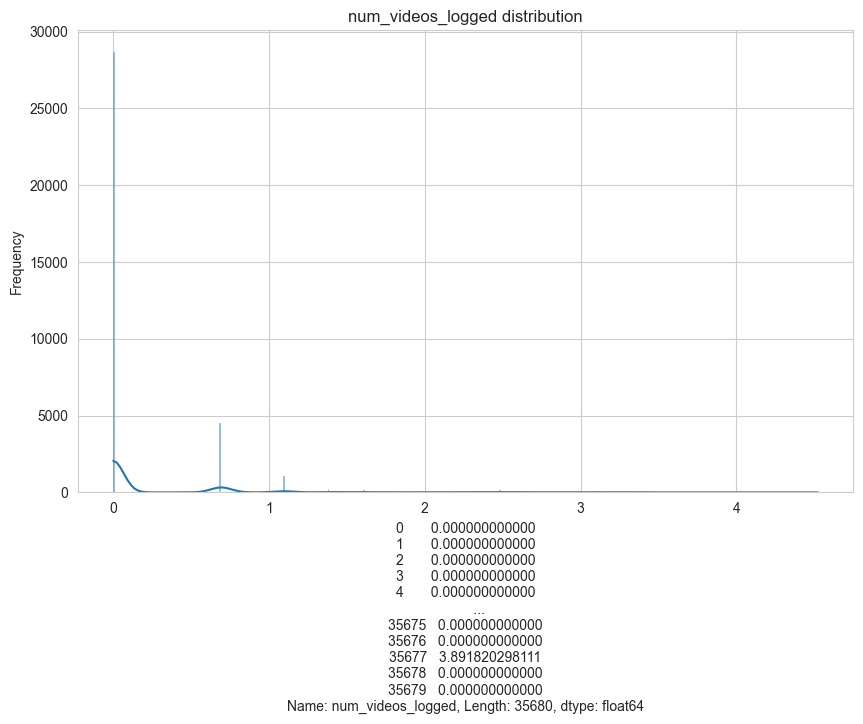

Pearson Correlation: 0.03983690977391617, p-value: 5.1690106382973105e-14
Spearman Correlation: 0.0316177412831058, p-value: 2.320647276425443e-09


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


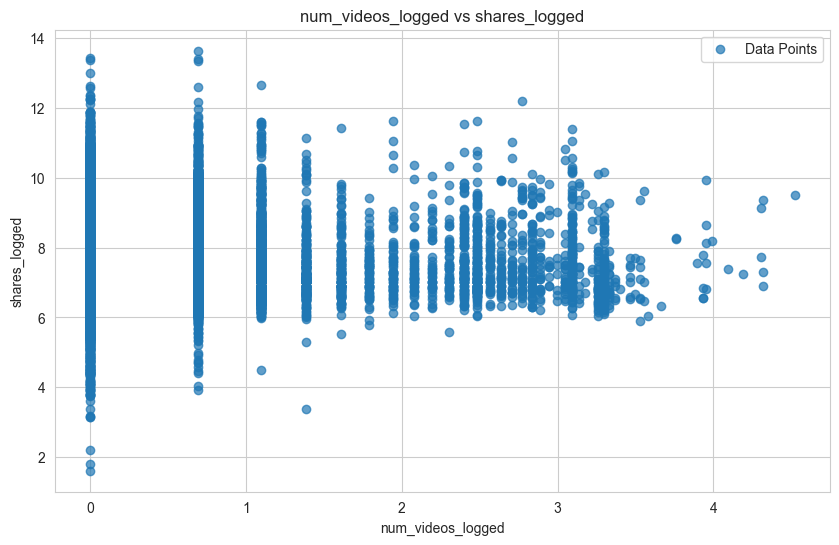

In [22]:
# Investigate 'num_videos'.
###############################################################################################################################################################################################################

display(df['num_videos'].isnull().sum()) # Shows there are 18925 non-null values; 16,755 NaN values.
display(df['num_videos'].describe())

print(f" No. of 'num_imgs' Unique Values: {df['num_videos'].nunique()}") #46 unique values

# Calculate the median of num_hrefs and replace NaN values
median_value = df['num_videos'].median()
df['num_videos'] = df['num_videos'].fillna(median_value)

print(df['num_videos'].describe())

df['num_videos_logged'] = np.log1p(df['num_videos'])

create_histogram(x=df['num_videos_logged'], data=df, title='num_videos_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a long positive tail. 

correlation, p_value = pearsonr(df['num_videos_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.01446443527377723, p-value: 0.006290222111598516; no statistically significant linear relationship between the two variables, and the effect size is practically negligible.

correlation, p_value = spearmanr(df['num_videos_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.0316177412831058, p-value: 2.320647276425444e-09; indicates a statistically significant but very weak positive monotonic relationship between the variables. The practical impact is minimal due to 
# the small effect size.

create_scatterplot(x=df['num_videos_logged'], y=df['shares_logged'], data=df, x_label='num_videos_logged', y_label='shares_logged', title='num_videos_logged vs shares_logged')
# Shows no overall pattern at all. 
###############################################################################################################################################################################################################


np.int64(0)

count   35680.000000000000
mean       94.122001121076
std       476.050346845325
min         0.000000000000
25%         2.000000000000
50%        16.000000000000
75%        78.000000000000
max     61790.000000000000
Name: n_comments, dtype: float64

 No. of 'n_comments' Unique Values: 834


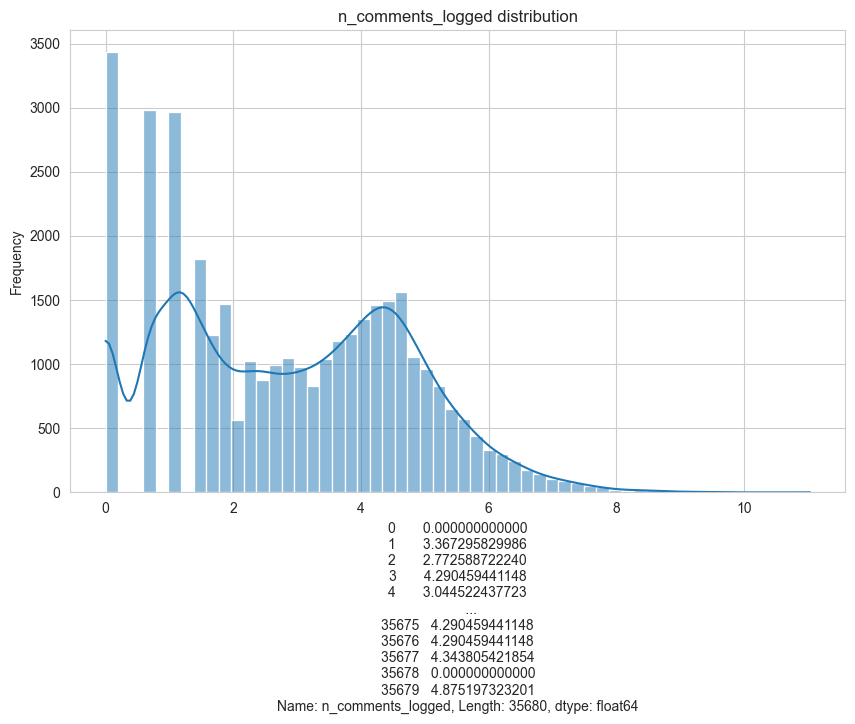

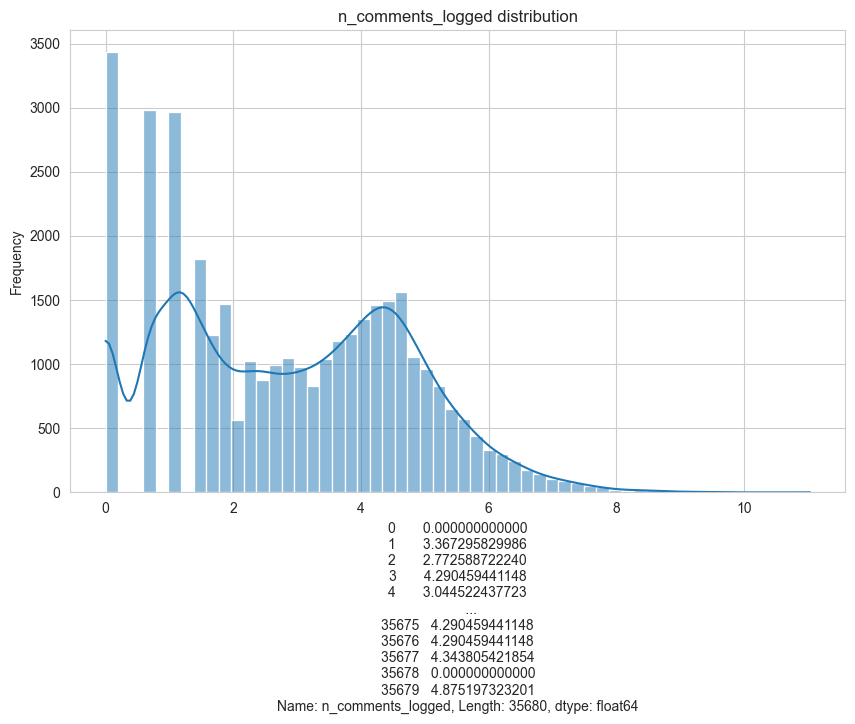

Pearson Correlation: 0.40395988361739965, p-value: 0.0
Spearman Correlation: 0.3617427077647914, p-value: 0.0
                            OLS Regression Results                            
Dep. Variable:          shares_logged   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     6957.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        20:40:52   Log-Likelihood:                -44806.
No. Observations:               35680   AIC:                         8.962e+04
Df Residuals:                   35678   BIC:                         8.963e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------

C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


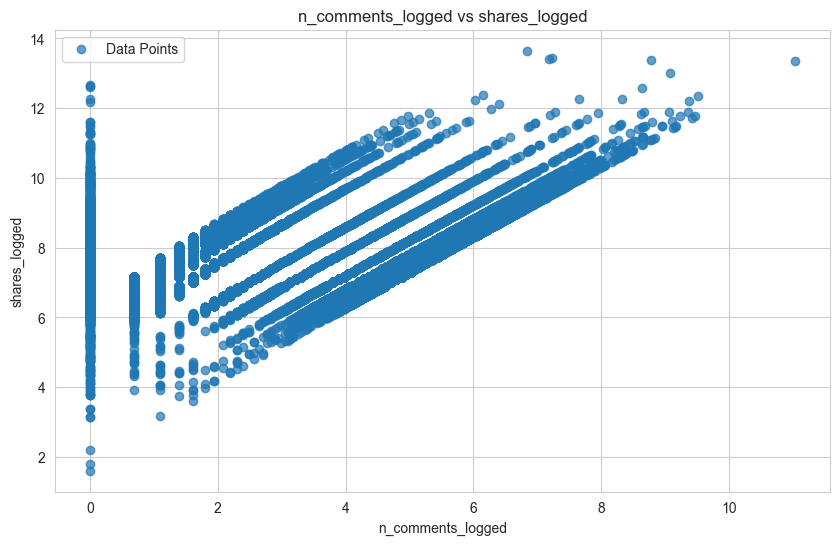

In [23]:
# Investigate 'n_comments'.
###############################################################################################################################################################################################################

display(df['n_comments'].isnull().sum()) # Shows there are no null values.
display(df['n_comments'].describe())

print(f" No. of 'n_comments' Unique Values: {df['n_comments'].nunique()}") #834 unique values

df['n_comments_logged'] = np.log1p(df['n_comments'])

create_histogram(x=df['n_comments_logged'], data=df, title='n_comments_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a very long positive tail. 

create_histogram(x=df['n_comments_logged'], data=df, title='n_comments_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a long positive tail with a hook due to the clipping.

correlation, p_value = pearsonr(df['n_comments_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.523029599368955, p-value: 0.0; quite a statistically significant linear relationship between the two variables, and the effect size is quite strong.

correlation, p_value = spearmanr(df['n_comments_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# SSpearman Correlation: 0.3617427077647914, p-value: 0.0; indicates a statistically significant and significant positive monotonic relationship between the variables. The correlation is weaker than
# Pearson though, so the correlation tends more toward direct proportional r/s. 

X = sm.add_constant(df['n_comments_logged'])
y = df['shares_logged']
model = sm.OLS(y, X).fit()
print(model.summary())
# Results show that the R2 is 27.4%; it means 27.4% of the variation in shares is explained by n_shares; by far the largest factor found so far.

create_scatterplot(x=df['n_comments_logged'], y=df['shares_logged'], data=df, x_label='n_comments_logged', y_label='shares_logged', title='n_comments_logged vs shares_logged')
# Shows a clear fan shape of as n_comments increase, the number of shares fan out in an increasing manner. However, it is in a fan shape, not a straight line. 

###############################################################################################################################################################################################################


np.int64(0)

count   35680.000000000000
mean        4.547799020530
std         0.843522004586
min         0.000000000000
25%         4.477958254250
50%         4.663366337000
75%         4.853694944500
max         8.041533546000
Name: average_token_length, dtype: float64

 No. of 'average_token_length' Unique Values: 27595


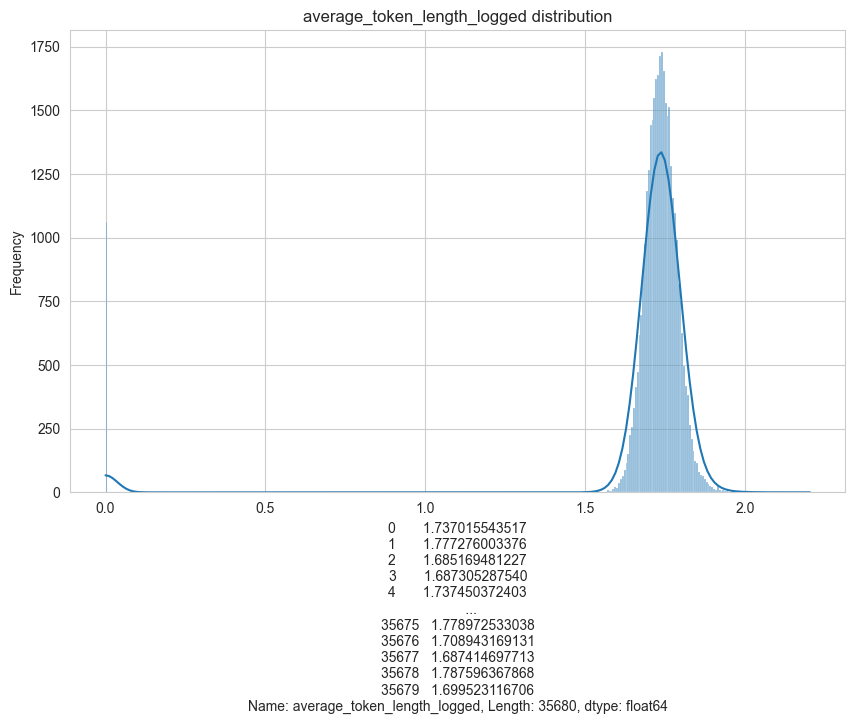

1061
Pearson Correlation: -0.03713377147886057, p-value: 2.2761223265519317e-12
Spearman Correlation: -0.05419759545860656, p-value: 1.2509461271370016e-24


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


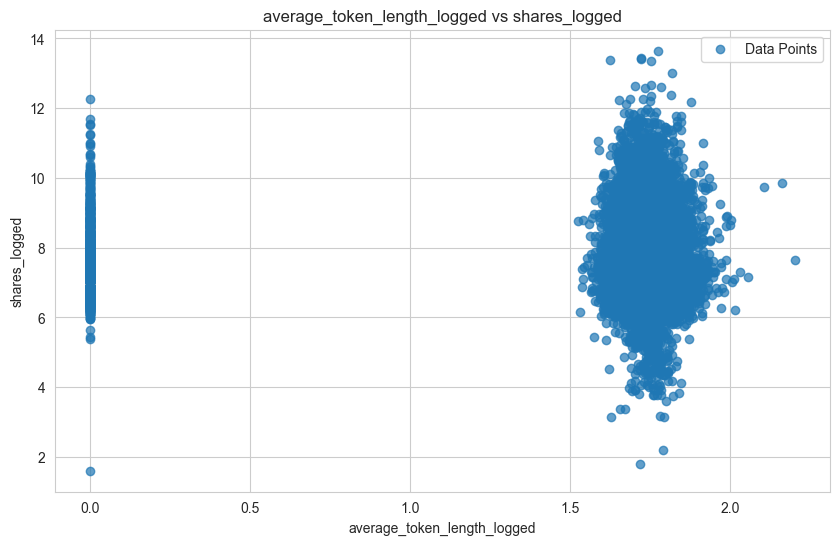

In [24]:
# Investigate 'average_token_length'.
###############################################################################################################################################################################################################

display(df['average_token_length'].isnull().sum()) # Shows there are no null values.
display(df['average_token_length'].describe())

print(f" No. of 'average_token_length' Unique Values: {df['average_token_length'].nunique()}") #27595 unique values

df['average_token_length_logged'] = np.log1p(df['average_token_length'])

create_histogram(x=df['average_token_length_logged'], data=df, title='average_token_length_logged distribution', xlabel=None)
# Shows a normal distribution but with 1000+ datapoints at average_token_length=0, which is logically impossible.

print((df['average_token_length']==0).sum()) #1061 zero values, which coincides with n_non_stop_words and n_non_stop_unique_tokens. There might be sloppy data-entry. 

correlation, p_value = pearsonr(df['average_token_length_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: -0.016973618522915637, p-value: 0.0013445796302787214; statistically significant linear relationship but very weak negative relationship between the two variables.

correlation, p_value = spearmanr(df['average_token_length_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: -0.05419759545860656, p-value: 1.250946127136984e-24; indicates a statistically significant but very weak negative r/s.

create_scatterplot(x=df['average_token_length_logged'], y=df['shares_logged'], data=df, x_label='average_token_length_logged', y_label='shares_logged', title='average_token_length_logged vs shares_logged')
# Shows no overall pattern. 

###############################################################################################################################################################################################################


np.int64(5462)

count     30218
unique        6
top       world
freq       7573
Name: data_channel, dtype: object

 No. of 'data_channel' Unique Values: 6
data_channel
world            7573
technology       6642
entertainment    6407
business         5623
social_media     2089
lifestyle        1884
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 35680 entries, 0 to 35679
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype        
---  ------                           --------------  -----        
 0   ID                               35680 non-null  int64        
 1   URL                              35680 non-null  str          
 2   timedelta                        35680 non-null  int64        
 3   weekday                          35680 non-null  str          
 4   shares                           35680 non-null  int64        
 5   n_tokens_title                   35680 non-null  int64        
 6   n_tokens_content                 35680 non-null  int64        
 7   n_unique_tokens                  35680 non-null  float64      
 8   n_non_stop_words   

C:\Users\User\AppData\Local\Temp\ipykernel_37800\1572892596.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['data_channel_enum'].fillna(mode_value, inplace=True)


np.int64(5462)

data_channel_enum
0.000000000000    7573
1.000000000000    6642
2.000000000000    6407
3.000000000000    5623
4.000000000000    2089
5.000000000000    1884
dtype: int64


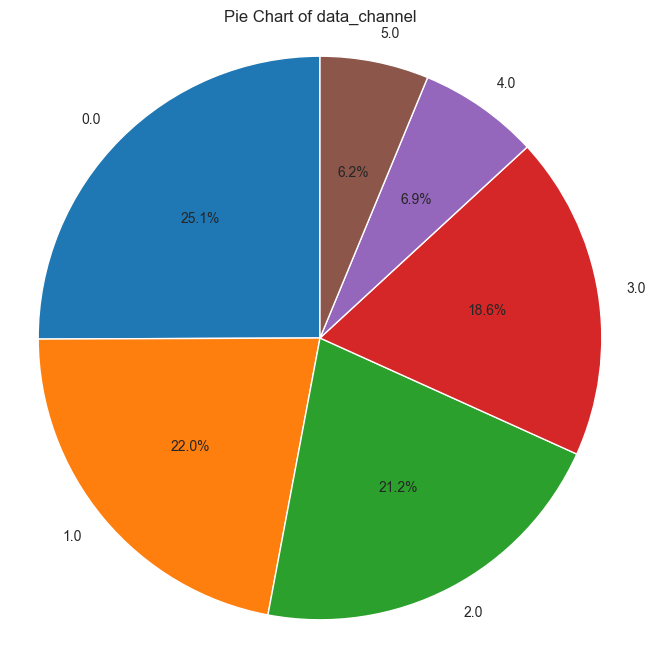

Chi-Square Statistic: 8425.517946008034, p-value: 2.2059604946069612e-60
Cramer's V: 0.23614591831807863
shares_binned         0     1     2    3    4    5    6    7    8    9
data_channel_enum                                                     
0.000000000000     1121  1067  1151  977  627  727  496  549  425  433
1.000000000000      355   463   579  672  622  901  740  903  801  606
2.000000000000      954   877   882  783  518  581  375  447  432  558
3.000000000000      548   535   673  628  504  653  559  612  531  380
4.000000000000       67    59    96  203  168  283  265  347  353  248
5.000000000000      146   135   158  196  181  214  195  218  214  227


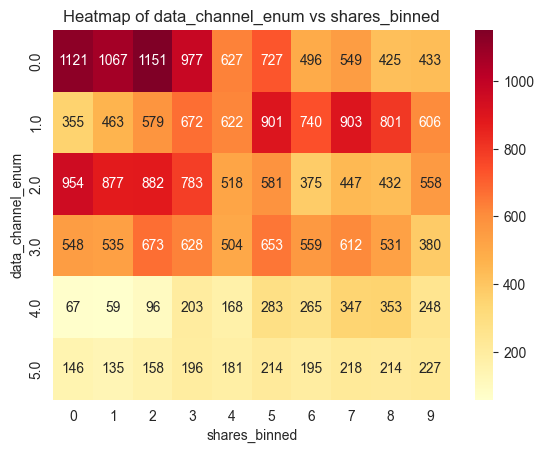

Chi-Square: 2313.209739369469, p-value: 0.0
Expected frequencies:
 [[799.70358727 785.91991528 886.91663909 866.86766166 656.60401085
  841.80643987 659.11013303 770.88318221 690.68727249 614.50115825]
 [701.3906281  689.30147594 777.88199087 760.29776954 575.88324839
  738.31749289 578.08127606 676.11330995 605.77642465 538.95638361]
 [676.57478986 664.9133629  750.35981865 733.39774307 555.50797538
  712.19514859 557.62823483 652.19180621 584.34350387 519.88761665]
 [593.78492951 583.55046661 658.54116752 643.65467602 487.53259647
  625.04656165 489.3934079  572.38559799 512.83963201 456.27096433]
 [220.59696208 216.79475809 244.65454365 239.12406513 181.12317162
  232.21096697 181.81448143 212.6468992  190.52498511 169.50916672]
 [198.94910318 195.52002118 220.64584023 215.65808459 163.34899729
  209.42339003 163.97246674 191.77920445 171.82818188 152.87471044]]


In [25]:
# Investigate 'data_channel'.
###############################################################################################################################################################################################################

display(df['data_channel'].isnull().sum()) # Shows there are 5462 null values.
display(df['data_channel'].describe()) # There are 6 categorizations; the most is 'world' at 7573 entries.

print(f" No. of 'data_channel' Unique Values: {df['data_channel'].nunique()}") # 6 unique values

# Get the count of unique values in the 'data_channel' column, sorted in descending order
data_channel_unique_counts = df.groupby('data_channel').size().sort_values(ascending=False)
print(data_channel_unique_counts) # world: 7573; technology: 6642; entertainment: 6407; business: 5623; social_media: 2089; lifestyle: 1884; NaN: 5462.

channel_mapping = {'world': 0, 'technology': 1, 'entertainment': 2, 'business': 3, 'social_media': 4, 'lifestyle': 5}

# Apply the mapping to the data_channel column
df['data_channel_enum'] = df['data_channel'].map(channel_mapping)

# There are 5462 NaN values. I would mode-impute for these values. 

mode_value = df['data_channel_enum'].mode()[0]
df['data_channel_enum'].fillna(mode_value, inplace=True)

# Select features for imputation 
print(df.info())

display(df['data_channel_enum'].isnull().sum()) # Shows there are no null values.

# Get the count of unique values in the 'data_channel_enum' column, sorted in descending order
data_channel_enum_unique_counts = df.groupby('data_channel_enum').size().sort_values(ascending=False)
print(data_channel_enum_unique_counts) # world: 7667; technology: 7491; entertainment: 9490; business: 6980; social_media: 2168; lifestyle: 1884.

create_pie_chart(data=data_channel_enum_unique_counts, labels=data_channel_enum_unique_counts.index, title='Pie Chart of data_channel')
# Shows more or less balanced pie chart except for social_media and lifestyle, which have smaller proportions. 

# Create a contingency table
contingency_table = pd.crosstab(df['shares_logged'], df['data_channel_enum'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2}, p-value: {p}")

# After creating contingency table
chi2 = chi2_contingency(contingency_table)[0]
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V: {cramers_v}")

# Results:
# Chi-Square Statistic: 8724.505870912393, p-value: 4.902362107574548e-38; Cramer's V: 0.22114289699369621. Shows a statistically significant correlation with shares but of limited influence. 
# The Chi-Square statistic (8724.51) and p-value (4.902362107574548e-38) indicate a highly significant association between the two categorical variables, while Cramer’s V (0.221) suggests a weak to moderate effect size. 

df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False)  # 10 quantiles
contingency_table = pd.crosstab(df['data_channel_enum'], df['shares_binned'])
print(contingency_table)
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of data_channel_enum vs shares_binned')
plt.show()

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}")
print("Expected frequencies:\n", expected)
# certain channels (e.g., 'entertainment', 'technology') tend to have higher shares in upper bins (8, 9), while others (e.g., 'world', 'business') are more distributed.

# Conclusion: There is some significance in the correlation between data_channel and shares, but not strong, and also certain channels e.g. entertainment, world, are more likely to be shared very widely. 

# Map back to original feature.
mapping_channel = {0: 'world', 1: 'technology', 2: 'entertainment', 3: 'business', 4: 'social_media', 5: 'lifestyle'}
df['data_channel'] = df['data_channel_enum'].map(mapping_channel)

###############################################################################################################################################################################################################


 No. of 'self_reference_min_shares' Unique Values: 1231
 No. of 'self_reference_max_shares' Unique Values: 1119
 No. of 'self_reference_avg_shares' Unique Values: 7853


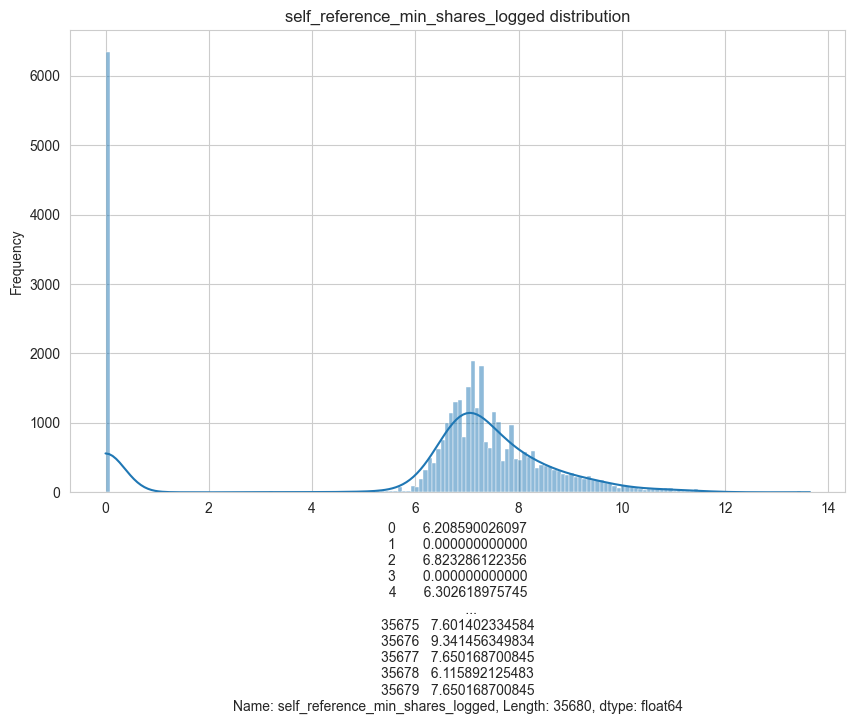

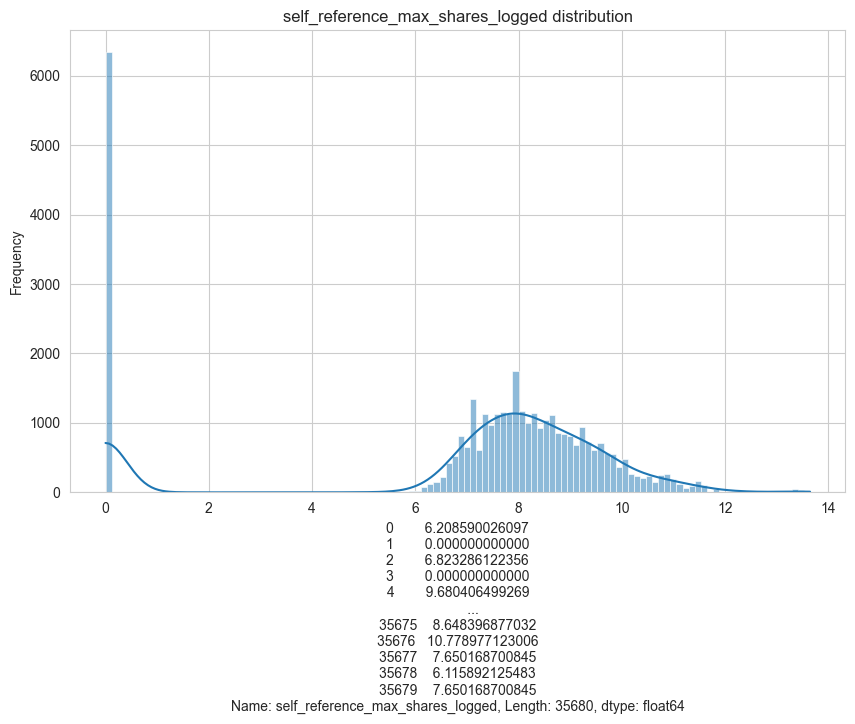

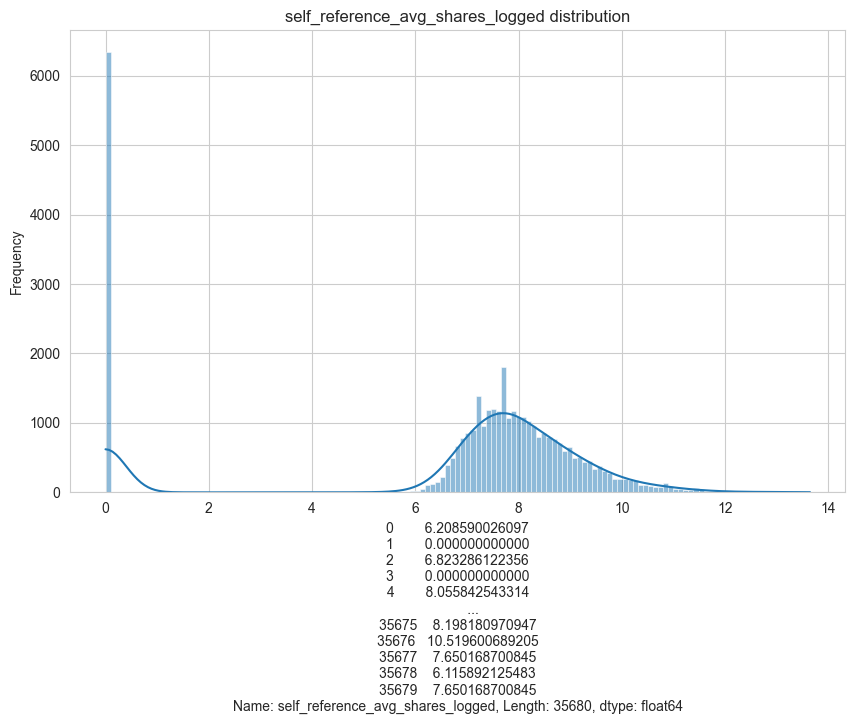

Pearson Correlation: 0.10380790646725077, p-value: 4.665735854512029e-86
Spearman Correlation: 0.17881229159720094, p-value: 4.100852876408551e-254
Pearson Correlation: 0.10244797622221513, p-value: 7.43137038430945e-84
Spearman Correlation: 0.1666746728951156, p-value: 1.3542759259214042e-220
Pearson Correlation: 0.10629279904554437, p-value: 3.705304787516116e-90
Spearman Correlation: 0.1897022482893297, p-value: 2.5262775993623983e-286


In [26]:
# Investigate 'self_reference_min_shares', 'self_reference_max_shares' and 'self_reference_avg_shares'.
###############################################################################################################################################################################################################

print(f" No. of 'self_reference_min_shares' Unique Values: {df['self_reference_min_shares'].nunique()}") #128 unique values
print(f" No. of 'self_reference_max_shares' Unique Values: {df['self_reference_max_shares'].nunique()}") #128 unique values
print(f" No. of 'self_reference_avg_shares' Unique Values: {df['self_reference_avg_shares'].nunique()}") #128 unique values
# Earlier analysis showed there were 721 NaN values.

# Calculate the median of num_hrefs and replace NaN values
median_value = df['self_reference_min_shares'].median()
df['self_reference_min_shares'] = df['self_reference_min_shares'].fillna(median_value)
median_value = df['self_reference_max_shares'].median()
df['self_reference_max_shares'] = df['self_reference_max_shares'].fillna(median_value)
median_value = df['self_reference_avg_shares'].median()
df['self_reference_avg_shares'] = df['self_reference_avg_shares'].fillna(median_value)

df['self_reference_min_shares_logged'] = np.log1p(df['self_reference_min_shares'])
df['self_reference_max_shares_logged'] = np.log1p(df['self_reference_max_shares'])
df['self_reference_avg_shares_logged'] = np.log1p(df['self_reference_avg_shares'])

create_histogram(x=df['self_reference_min_shares_logged'], data=df, title='self_reference_min_shares_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a very long positive tail. 
create_histogram(x=df['self_reference_max_shares_logged'], data=df, title='self_reference_max_shares_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a very long positive tail. 
create_histogram(x=df['self_reference_avg_shares_logged'], data=df, title='self_reference_avg_shares_logged distribution', xlabel=None)
# Shows a slanted-left normal distribution but with a very long positive tail. 

correlation, p_value = pearsonr(df['self_reference_min_shares_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.05759227106947316, p-value: 1.3244337320005199e-27; indicates a statistically significant but very weak positive proportional relationship between the variables. The practical impact is minimal due to 
# the small effect size.
correlation, p_value = spearmanr(df['self_reference_min_shares_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.17881229159720094, p-value: 4.1008528764077075e-254; indicates a statistically significant but very weak positive monotonic relationship between the variables. The practical impact is minimal due to 
# the small effect size.

correlation, p_value = pearsonr(df['self_reference_max_shares_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.04778995034515767, p-value: 1.6862447902930435e-19; indicates a statistically significant but very weak positive proportional relationship between the variables. The practical impact is minimal due to 
# the small effect size.
correlation, p_value = spearmanr(df['self_reference_max_shares_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.1666746728951156, p-value: 1.354275925921401e-220; indicates a statistically significant but very weak positive monotonic relationship between the variables. The practical impact is minimal due to 
# the small effect size.

correlation, p_value = pearsonr(df['self_reference_avg_shares_logged'], df['shares_logged'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.05877885827546515, p-value: 1.096192379435592e-28; indicates a statistically significant but very weak positive proportional relationship between the variables. The practical impact is minimal due to 
# the small effect size.
correlation, p_value = spearmanr(df['self_reference_avg_shares_logged'], df['shares_logged'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.1897022482893297, p-value: 2.5262775993627754e-286; indicates a statistically significant but very weak positive monotonic relationship between the variables. The practical impact is minimal due to 
# the small effect size.

###############################################################################################################################################################################################################


np.int64(0)

count   35680.000000000000
mean        7.220095291480
std         1.909603989123
min         1.000000000000
25%         6.000000000000
50%         7.000000000000
75%         9.000000000000
max        10.000000000000
Name: num_keywords, dtype: float64

 No. of 'num_keywords' Unique Values: 10
num_keywords
7     6572
6     6155
10    6017
8     5453
5     4359
9     4277
4     2192
3      568
1       49
2       38
dtype: int64


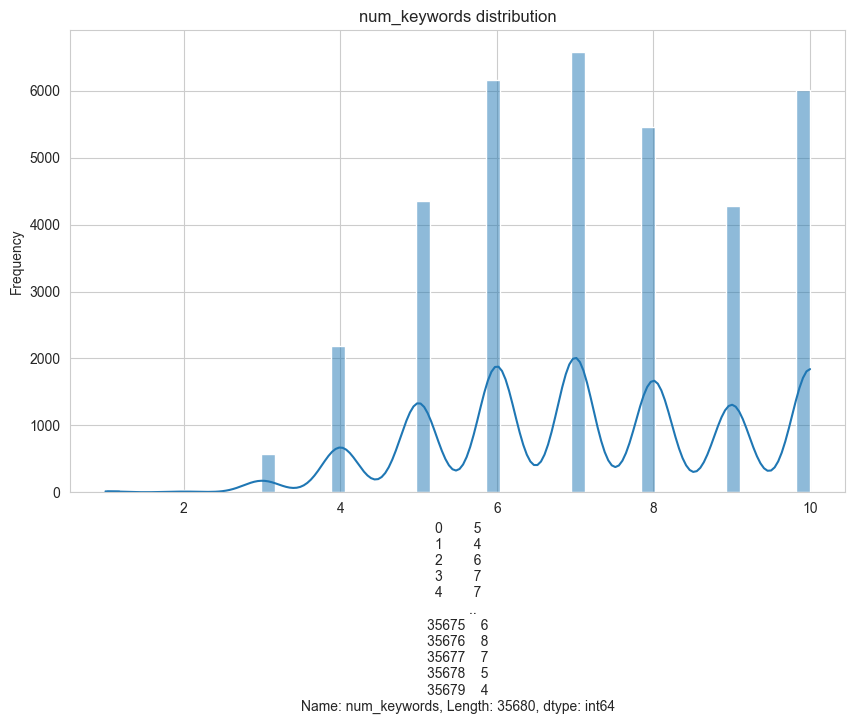

Pearson Correlation: 0.022312324321514497, p-value: 2.4979423660887174e-05
Spearman Correlation: 0.07160047563639713, p-value: 8.879712547903559e-42
R-squared: 0.0004978398166280984


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2437855826.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='viridis', alpha=0.7, marker='o', label='Data Points')


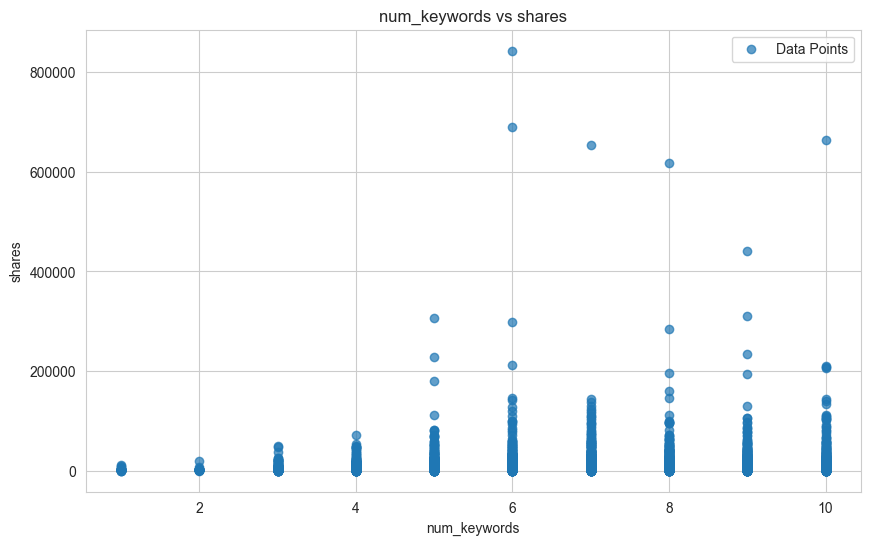

ANOVA F-Statistic: 3.2293209210907072, p-value: 0.0011247981497348003
Chi-Square Statistic: 16367.984689924595, p-value: 2.3138316932672937e-96
Cramer's V: 0.22576880148722261


In [27]:
# Investigate 'num_keywords'.
###############################################################################################################################################################################################################

display(df['num_keywords'].isnull().sum()) # Shows there are 0 null values.
display(df['num_keywords'].describe()) # Shows a more or less normal distribution.

print(f" No. of 'num_keywords' Unique Values: {df['num_keywords'].nunique()}") # 10 unique values

# Get the count of unique values in the 'num_keywords' column, sorted in descending order
num_keywords_unique_counts = df.groupby('num_keywords').size().sort_values(ascending=False)
print(num_keywords_unique_counts) # 7kw: 6572; 6kw: 6155; 10kw: 6017; 8kw: 5453; 5kw: 4359; 9kw: 4277; 4kw: 2192; 3kw: 568; 1kw: 49; 2kw: 38. 

create_histogram(x=df['num_keywords'], data=df, title='num_keywords distribution', xlabel=None)
# Cannot see any pattern to the graph. 

correlation, p_value = pearsonr(df['num_keywords'], df['shares'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: 0.022312324321514494, p-value: 2.4979423660887624e-05; indicates a statistically significant but very weak positive proportional relationship between the variables. The practical impact is minimal due to 
# the small effect size.
correlation, p_value = spearmanr(df['num_keywords'], df['shares'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: 0.07160047563639713, p-value: 8.879712547903596e-42; indicates a statistically significant but very weak positive monotonic relationship between the variables. The practical impact is minimal due to 
# the small effect size.

X = df['num_keywords'].values.reshape(-1, 1) # type: ignore
y = df['shares'].values
model = LinearRegression().fit(X, y) # type: ignore
r_squared = model.score(X, y) # type: ignore
print(f"R-squared: {r_squared}")
# R-squared: 0.0004978398166283204；num_keywords is a very weak predictor of shares. 

create_scatterplot(x=df['num_keywords'], y=df['shares'], data=df, x_label='num_keywords', y_label='shares', title='num_keywords vs shares')
# Shows that kw>=6 might have more viral articles.

# Example with 'shares' as continuous and 'num_keywords' as categorical
groups = [df[df['num_keywords'] == i]['shares'].dropna() for i in range(1, 10)]  
statistic, p_value = f_oneway(*groups)
print(f"ANOVA F-Statistic: {statistic}, p-value: {p_value}")
# Results: ANOVA F-Statistic: 3.229320921090708, p-value: 0.0011247981497568501
# There is a significant difference in the means of the continuous variable (e.g., 'shares') across the categories of the categorical variable (e.g., 'num_keywords'). Practical Significance: The F-statistic (3.22) is moderate, 
# indicating some variability between groups.

# Create a contingency table
contingency_table = pd.crosstab(df['shares'], df['num_keywords'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2}, p-value: {p}")

# After creating contingency table
chi2 = chi2_contingency(contingency_table)[0]
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V: {cramers_v}")
# Chi-Square Statistic: 16367.984689924595, p-value: 2.3138316932672937e-96; Cramer's V: 0.22576880148722261. There is a weak to moderate correlation r/s betw. shares and num_keywords.

###############################################################################################################################################################################################################


np.int64(0)

count   35680.000000000000
mean       26.169702914798
std        69.705812053221
min        -1.000000000000
25%        -1.000000000000
50%        -1.000000000000
75%         4.000000000000
max       377.000000000000
Name: kw_min_min, dtype: float64

0    0
1    0
2    0
3    0
4    0
Name: kw_min_min, dtype: int64

 No. of 'kw_min_min' Unique Values: 22
kw_min_min
-1      20660
 4      10727
 217     4184
 0         75
 47         5
 57         4
 86         4
 82         3
 88         2
 45         2
 294        2
 63         2
 41         1
 80         1
 116        1
 98         1
 129        1
 138        1
 184        1
 162        1
 201        1
 377        1
dtype: int64
Mean of kw_min_min (excluding strange values): 104.67647058823529


np.int64(0)

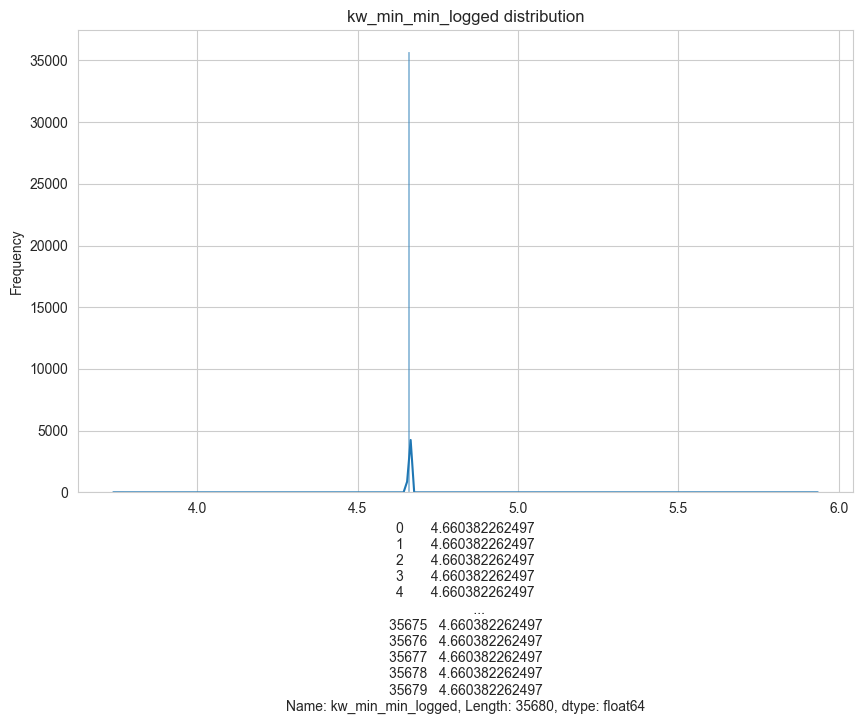

count   35680.000000000000
mean        4.660198403073
std         0.018741857520
min         3.737669618283
25%         4.660382262497
50%         4.660382262497
75%         4.660382262497
max         5.934894195620
Name: kw_min_min_logged, dtype: float64

0   4.660382262497
1   4.660382262497
2   4.660382262497
3   4.660382262497
4   4.660382262497
Name: kw_min_min_logged, dtype: float64

 No. of 'kw_min_min_logged' Unique Values: 19
kw_min_min_logged
4.660382262497    35646
3.871201010908        5
4.060443010546        4
4.465908118655        4
4.418840607797        3
4.488636369732        2
3.828641396489        2
5.686975356340        2
4.158883083360        2
3.737669618283        1
4.394449154672        1
4.595119850135        1
4.762173934798        1
4.934473933131        1
4.867534450456        1
5.093750200807        1
5.220355825078        1
5.308267697401        1
5.934894195620        1
dtype: int64
Chi-Square Statistic: 25728.619263349727, p-value: 0.16212664052348302
Cramer's V: 0.20015182976089857
Pearson Correlation: 0.0013886245740939362, p-value: 0.7930976241922275
Spearman Correlation: 0.0015057535330907149, p-value: 0.7760929436133782


In [28]:
# Investigate 'kw_min_min'.
###############################################################################################################################################################################################################

display(df['kw_min_min'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_min_min'].describe()) # Shows a very strange distribution.
display(df['kw_min_min'].head()) # 0 values in the first 5 rows. On examination of the first 75 rows of all kw features, they are all 0. 

print(f" No. of 'kw_min_min' Unique Values: {df['kw_min_min'].nunique()}") # 22 unique values

# Get the count of unique values in the 'kw_min_min' column, sorted in descending order
kw_min_min_unique_counts = df.groupby('kw_min_min').size().sort_values(ascending=False)
print(kw_min_min_unique_counts) # There are 20,660 datapoints of value -1! Definitely very strange. Value 4: 10,727; Value 217: 4,184; 0: 75. 

# There are too many entries with very strange value. I would KNN-impute this column.
strange_values = {-1, 4, 217, 0}

mean = df['kw_min_min'].replace(strange_values, np.nan).mean() # type: ignore
print(f"Mean of kw_min_min (excluding strange values): {mean}") # 71.0

# Replace strange values with NaN in the kw_min_min column
df['kw_min_min'] = df['kw_min_min'].replace(strange_values, mean) # type: ignore

display(df['kw_min_min'].isnull().sum()) # Shows there are no null values.

df['kw_min_min_logged'] = np.log1p(df['kw_min_min'])

create_histogram(x=df['kw_min_min_logged'], data=df, title='kw_min_min_logged distribution', xlabel=None)
# Has become a normal distribution with a very long tail on the right. 

display(df['kw_min_min_logged'].describe()) # Shows a more normal distribution.
display(df['kw_min_min_logged'].head()) # 176 values in the first 5 rows. 

print(f" No. of 'kw_min_min_logged' Unique Values: {df['kw_min_min_logged'].nunique()}") # 54 unique values

# Get the count of unique values in the 'kw_min_min_logged' column, sorted in descending order
kw_min_min_logged_unique_counts = df.groupby('kw_min_min_logged').size().sort_values(ascending=False)
print(kw_min_min_logged_unique_counts) # There are 32,812 datapoints of value 71! Definitely very strange, but better than previously.

# Create a contingency table
contingency_table = pd.crosstab(df['shares'], df['kw_min_min_logged'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2}, p-value: {p}")

# After creating contingency table
chi2 = chi2_contingency(contingency_table)[0]
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V: {cramers_v}")
# Chi-Square Statistic: 72945.91649498355, p-value: 0.9999999900594173; Cramer's V: 0.19640391247392752. There is no correlation.

correlation, p_value = pearsonr(df['kw_min_min_logged'], df['shares'])
print(f"Pearson Correlation: {correlation}, p-value: {p_value}")
# Pearson Correlation: -0.01367677839731726, p-value: 0.009781550600882651; indicates a statistically significant but very weak negative proportional relationship between the variables. The practical impact is minimal due to 
# the small effect size.
correlation, p_value = spearmanr(df['kw_min_min_logged'], df['shares'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")
# Spearman Correlation: -0.00123617253628199, p-value: 0.8153775196568435; There is no correlation.

###############################################################################################################################################################################################################


np.int64(0)

count    35680.000000000000
mean      1142.296850896861
std       3844.829034457443
min          0.000000000000
25%        445.000000000000
50%        658.000000000000
75%       1000.000000000000
max     298400.000000000000
Name: kw_max_min, dtype: float64

0   0.000000000000
1   0.000000000000
2   0.000000000000
3   0.000000000000
4   0.000000000000
Name: kw_max_min, dtype: float64

 No. of 'kw_max_min' Unique Values: 1064
kw_max_min
1100.000000000000      1369
1200.000000000000      1071
0.000000000000          763
1300.000000000000       735
1400.000000000000       724
                       ... 
26000.000000000000        1
36200.000000000000        1
34300.000000000000        1
36700.000000000000        1
158900.000000000000       1
Length: 1064, dtype: int64


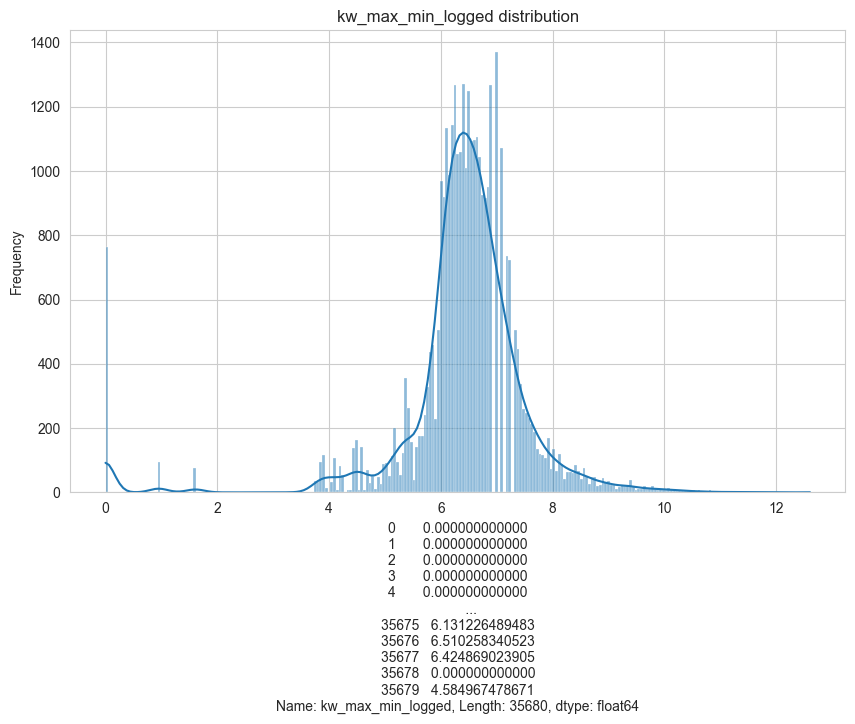

shares_binned        0    1    2    3    4    5    6    7    8    9
kw_max_min_binned                                                  
0                  485  441  451  468  276  349  242  342  294  283
1                  396  363  376  397  301  395  274  374  334  306
2                  407  364  420  369  320  380  320  318  335  345
3                  379  423  470  417  287  416  269  287  278  346
4                  348  360  427  358  326  411  306  356  338  315
5                  348  366  449  396  272  358  338  343  325  397
6                  324  364  392  391  306  388  324  377  327  357
7                  402  397  439  474  381  474  437  473  480  472
8                  219  225  253  304  246  320  253  338  308  281
9                  277  263  335  354  283  383  321  414  454  436
Chi-Square: 470.3820725487, p-value: 3.1557351647296013e-56
Expected frequencies:
 [[364.83001682 362.89646861 408.28396861 399.73565022 305.09355381
  394.24030269 313.84540359 368.59

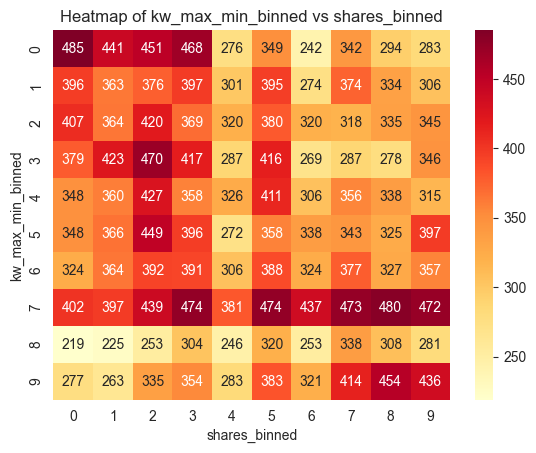

Recalculated Cramer's V: 0.034826338323995155
                            OLS Regression Results                            
Dep. Variable:          shares_logged   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     258.3
Date:                Fri, 08 May 2026   Prob (F-statistic):           6.59e-58
Time:                        20:40:59   Log-Likelihood:                -47855.
No. Observations:               35680   AIC:                         9.571e+04
Df Residuals:                   35678   BIC:                         9.573e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [29]:
# Investigate 'kw_max_min'.
###############################################################################################################################################################################################################

display(df['kw_max_min'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_max_min'].describe()) # Shows a very strange distribution.
display(df['kw_max_min'].head()) # 0 values in the first 5 rows. On examination of the first 75 rows of all kw features, they are all 0. 

print(f" No. of 'kw_max_min' Unique Values: {df['kw_max_min'].nunique()}") # 1064 unique values

# Get the count of unique values in the 'kw_max_min' column, sorted in descending order
kw_max_min_unique_counts = df.groupby('kw_max_min').size().sort_values(ascending=False)
print(kw_max_min_unique_counts) # Value 1100: 1369 instances; Value 1200: 1071 instances; Value 0: 763; Value 1300: 735; Value 1400: 724. 

df['kw_max_min_logged'] = np.log1p(df['kw_max_min'])

create_histogram(x=df['kw_max_min_logged'], data=df, title='kw_max_min_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_max_min_binned'] = pd.qcut(df['kw_max_min_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_max_min_binned'], df['shares_binned'])
print(contingency_table) # The table shows a relatively even distribution, with slight peaks (e.g., 472 in bin 9 for kw_max_min_binned=7), but no strong pattern. 

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
# Chi-Square: 470.3820725487, p-value: 3.1557351647296013e-56; A value of 470.38 is significant, indicating a notable deviation and suggesting an association. 
# p-value of approximately 3.1557351647296013e-56 is far below 0.05, indicating high statistical significance
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_max_min_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}") # a very weak association between kw_max_min_binned and shares_binned

X = sm.add_constant(df['kw_max_min_logged'])
y = df['shares_logged']
model = sm.OLS(y, X).fit() # OLS regression (R-squared = 0.0) suggests a negligible linear relationship. indicates that the association is non-linear or driven by 
# specific bin combinations rather than a consistent trend.
print(model.summary())
# The extreme skewness (34.411) and kurtosis (1830.603) in residuals suggest that outliers (e.g., shares > 843300) dominate, reducing the model’s explanatory power.

###############################################################################################################################################################################################################


np.int64(0)

count   35680.000000000000
mean      310.297441245207
std       616.961660301538
min        -1.000000000000
25%       141.440476150000
50%       235.428571400000
75%       357.000000000000
max     42827.857140000000
Name: kw_avg_min, dtype: float64

0   0.000000000000
1   0.000000000000
2   0.000000000000
3   0.000000000000
4   0.000000000000
Name: kw_avg_min, dtype: float64

 No. of 'kw_avg_min' Unique Values: 15949
kw_avg_min_logged
-inf              644
0.000000000000     77
3.789855371454     46
5.272999558564     39
2.525728644308     38
                 ... 
8.809887680741      1
8.732917286511      1
8.705082552514      1
8.684159360200      1
8.676855186691      1
Length: 15949, dtype: int64


c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


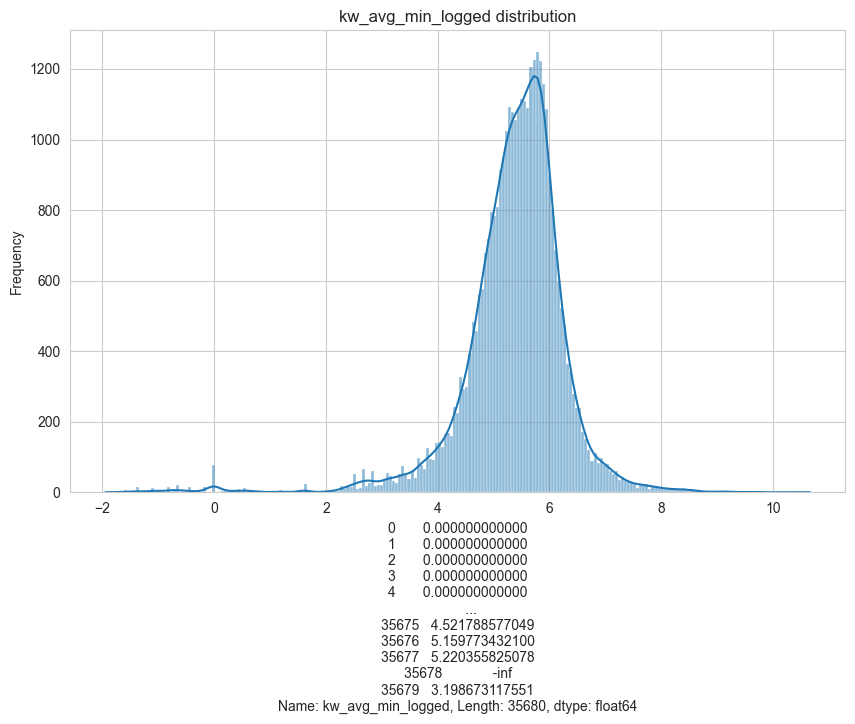

c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


shares_binned        0    1    2    3    4    5    6    7    8    9
kw_avg_min_binned                                                  
1.000000000000     400  413  419  398  322  367  242  360  309  349
2.000000000000     354  400  449  415  295  372  269  297  340  364
3.000000000000     338  380  458  374  295  414  300  308  356  354
4.000000000000     360  393  410  365  291  405  304  354  333  345
5.000000000000     314  354  423  414  320  379  304  352  333  375
6.000000000000     370  323  397  351  295  390  342  394  338  370
7.000000000000     339  336  364  387  311  393  370  388  344  333
8.000000000000     318  293  318  377  310  418  364  423  397  350
9.000000000000     288  240  310  362  288  394  347  438  455  446
Chi-Square: 342.35448798944384, p-value: 8.19564491866021e-37
Expected frequencies:
 [[343.41012146 349.09461227 395.46222361 383.75886017 303.95306758
  393.67885394 316.77103706 369.38044223 357.23123637 366.25954531]
 [341.10728745 346.7536593  392.

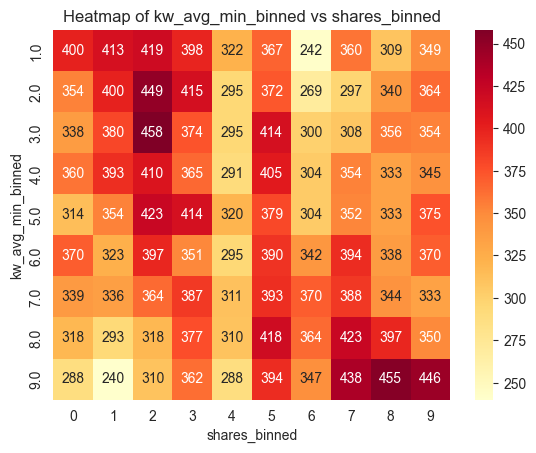

Recalculated Cramer's V: 0.03244546133210138


In [30]:
# Investigate 'kw_avg_min'.
###############################################################################################################################################################################################################

display(df['kw_avg_min'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_avg_min'].describe()) # Shows a very strange distribution.
display(df['kw_avg_min'].head()) # 0 values in the first 5 rows. On examination of the first 75 rows of all kw features, they are all 0. 

print(f" No. of 'kw_avg_min' Unique Values: {df['kw_avg_min'].nunique()}") # 15949 unique values

df['kw_avg_min_logged'] = np.log1p(df['kw_avg_min'])
# df['kw_avg_min'] = df['kw_avg_min'].clip(lower=0, upper=50000) # 50000 is a reasonable value upon examining max @ 42827.

# Get the count of unique values in the 'kw_avg_min_logged' column, sorted in descending order
kw_avg_min_unique_counts = df.groupby('kw_avg_min_logged').size().sort_values(ascending=False)
print(kw_avg_min_unique_counts) # Value 0: 844 instances; Value 43.25: 46 instances; Value 194: 39; Value 11.5: 38; Value 80.5: 37. 

create_histogram(x=df['kw_avg_min_logged'], data=df, title='kw_avg_min_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_avg_min_binned'] = pd.qcut(df['kw_avg_min_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_avg_min_binned'], df['shares_binned'])
print(contingency_table) # The table shows a relatively even distribution, with slight peaks (e.g., 504 in bin 9 for kw_avg_min_binned=0), but no strong pattern. 
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
# Chi-Square: 547.8149094662832, p-value: 1.9360719214451927e-70; A value of 547.8149 is significant, indicating a notable deviation and suggesting an association. 
# p-value of approximately 1.9360719214451927e-70 is far below 0.05, indicating high statistical significance
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_avg_min_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}") # Cramer's V: 0.03813224789833934 is a very weak association between kw_avg_min_binned and shares_binned

###############################################################################################################################################################################################################


np.int64(0)

count    35680.000000000000
mean     13533.498850896862
std      57623.779315987114
min          0.000000000000
25%          0.000000000000
50%       1400.000000000000
75%       7800.000000000000
max     843300.000000000000
Name: kw_min_max, dtype: float64

0    0
1    0
2    0
3    0
4    0
Name: kw_min_max, dtype: int64

 No. of 'kw_min_max' Unique Values: 1006
kw_min_max
0       15402
1500      351
1400      334
1200      327
1300      325
        ...  
245         1
248         1
733         1
734         1
997         1
Length: 1006, dtype: int64


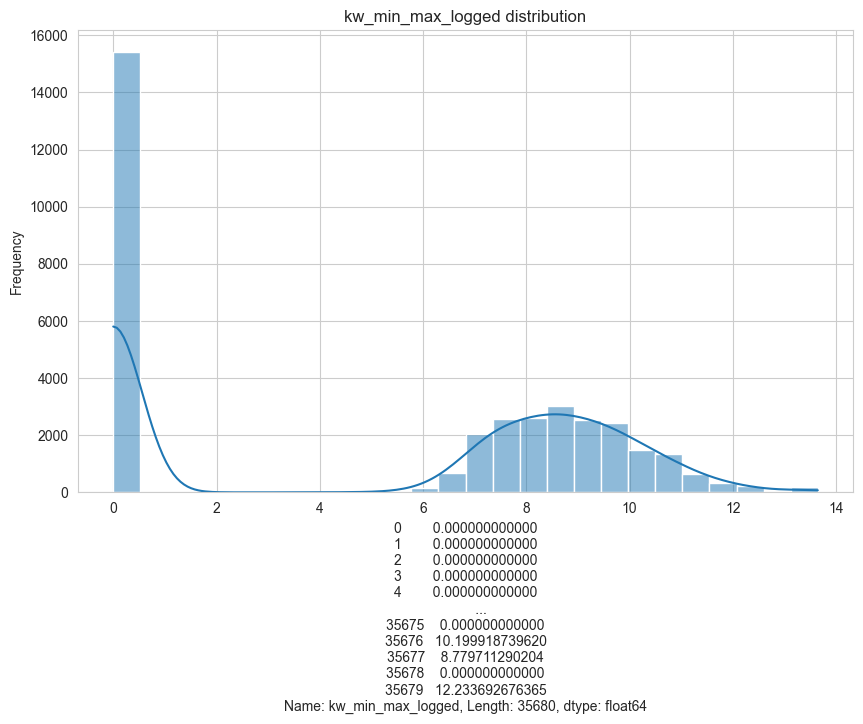

shares_binned         0     1     2     3     4     5     6     7     8     9
kw_min_max_binned                                                            
0                  2052  1912  2042  1974  1446  1928  1521  1780  1619  1679
1                   404   408   468   392   336   391   303   309   305   249
2                   293   299   386   421   334   409   304   368   353   328
3                   276   324   377   400   314   407   324   402   374   375
4                   286   331   378   379   275   379   316   358   415   429
5                   274   292   361   362   293   360   316   405   407   478
Chi-Square: 348.3713578705531, p-value: 1.6353855435142103e-48
Expected frequencies:
 [[1803.85383969 1794.29366592 2018.70616592 1976.44013453 1508.494787
  1949.26911435 1551.76715247 1822.47102018 1747.49913117 1780.20498879]
 [ 358.19857063  356.30016816  400.86266816  392.46973094  299.54792601
   387.0742713   308.14069507  361.89545964  347.00798767  353.50252242]
 [

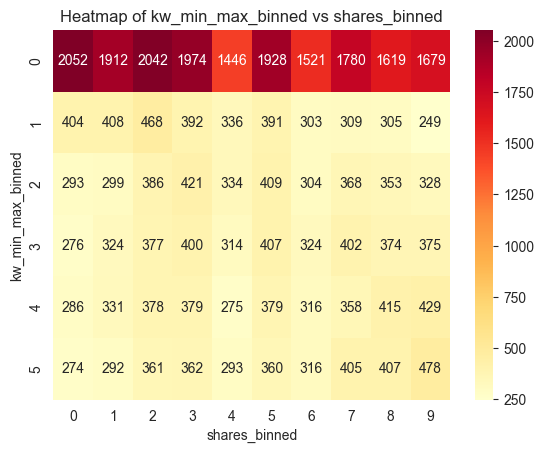

Recalculated Cramer's V: 0.041240069901400535
                            OLS Regression Results                            
Dep. Variable:          shares_logged   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     36.80
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.32e-09
Time:                        20:46:59   Log-Likelihood:                -47966.
No. Observations:               35680   AIC:                         9.594e+04
Df Residuals:                   35678   BIC:                         9.595e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [31]:
# Investigate 'kw_min_max'.
###############################################################################################################################################################################################################

display(df['kw_min_max'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_min_max'].describe()) # Shows a very strange distribution.
display(df['kw_min_max'].head()) # 0 values in the first 5 rows. On examination of the first 75 rows of all kw features, they are all 0. 

print(f" No. of 'kw_min_max' Unique Values: {df['kw_min_max'].nunique()}") # 15949 unique values

# Get the count of unique values in the 'kw_min_min' column, sorted in descending order
kw_min_max_unique_counts = df.groupby('kw_min_max').size().sort_values(ascending=False)
print(kw_min_max_unique_counts) 

df['kw_min_max_logged'] = np.log1p(df['kw_min_max'])

create_histogram(x=df['kw_min_max_logged'], data=df, title='kw_min_max_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_min_max_binned'] = pd.qcut(df['kw_min_max_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_min_max_binned'], df['shares_binned'])
print(contingency_table) 
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_min_max_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}") 

X = sm.add_constant(df['kw_min_max_logged'])
y = df['shares_logged']
model = sm.OLS(y, X).fit() # OLS regression (R-squared = 0.0) suggests a negligible linear relationship. indicates that the association is non-linear or driven by specific bin combinations rather than a consistent trend.
print(model.summary())
# The extreme skewness and kurtosis  in residuals suggest that outliers (e.g., shares > 42000) dominate, reducing the model’s explanatory power.

###############################################################################################################################################################################################################


np.int64(0)

count    35680.000000000000
mean    752318.562219730928
std     214391.922961118486
min          0.000000000000
25%     843300.000000000000
50%     843300.000000000000
75%     843300.000000000000
max     843300.000000000000
Name: kw_max_max, dtype: float64

0    0
1    0
2    0
3    0
4    0
Name: kw_max_max, dtype: int64

 No. of 'kw_max_max' Unique Values: 31
kw_max_max
843300    27175
690400     3581
617900     2057
69100      1131
51900       743
80400       368
39400       138
28000       115
37400       112
17100        84
0            75
227300       66
306100        7
104100        5
663600        3
73100         2
441000        2
118700        2
67500         2
15000         1
11100         1
18200         1
27700         1
53100         1
41600         1
35800         1
86200         1
139600        1
93800         1
310800        1
233400        1
dtype: int64


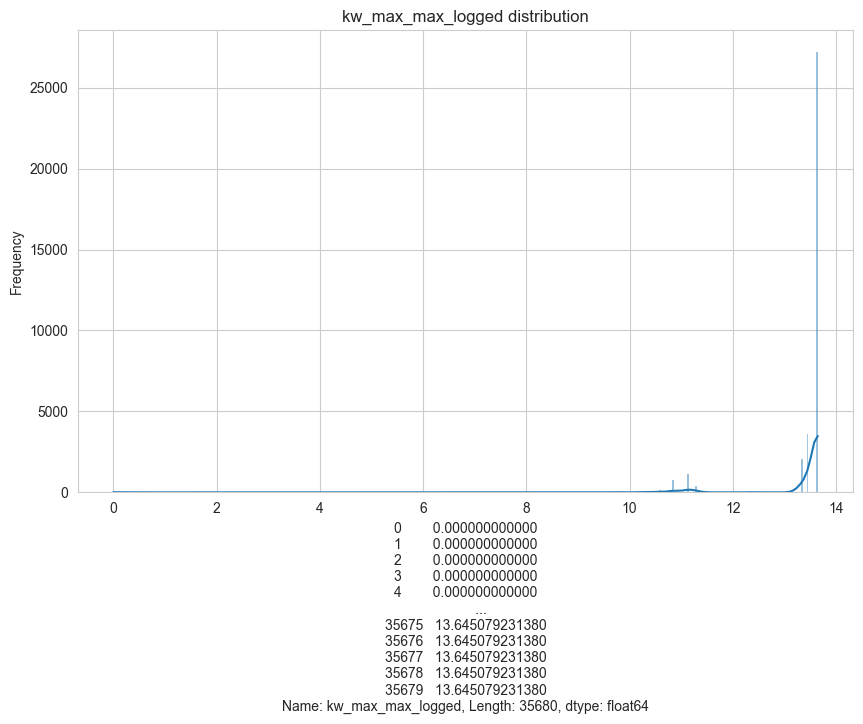

shares_binned         0     1     2     3     4     5     6     7     8     9
kw_max_max_binned                                                            
0                   437   335   405   521   418   627   550   619   523   486
1                   504   330   361   347   285   369   335   385   351   317
2                  2644  2901  3246  3060  2295  2878  2199  2618  2599  2735
Chi-Square: 310.43648933407223, p-value: 3.4230841112957614e-55
Expected frequencies:
 [[ 494.44464686  491.82415919  553.33665919  541.75134529  413.48536996
   534.3036435   425.34652466  499.54770179  478.99756166  487.96238789]
 [ 360.10762332  358.19910314  402.99910314  394.56143498  301.14439462
   389.13721973  309.78295964  363.82421525  348.8573991   355.38654709]
 [2730.44772982 2715.97673767 3055.66423767 2991.68721973 2283.37023543
  2950.55913677 2348.8705157  2758.62808296 2645.14503924 2694.65106502]]


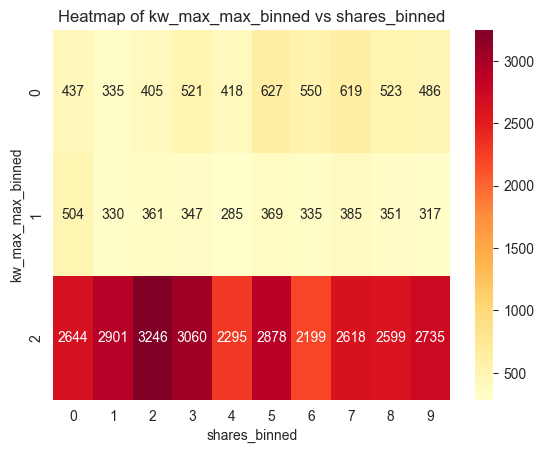

Recalculated Cramer's V: 0.064017713439699
                            OLS Regression Results                            
Dep. Variable:          shares_logged   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     6.374
Date:                Fri, 08 May 2026   Prob (F-statistic):             0.0116
Time:                        20:47:21   Log-Likelihood:                -47981.
No. Observations:               35680   AIC:                         9.597e+04
Df Residuals:                   35678   BIC:                         9.598e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [32]:
# Investigate 'kw_max_max'.
###############################################################################################################################################################################################################

display(df['kw_max_max'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_max_max'].describe()) # Shows a very strange distribution.
display(df['kw_max_max'].head()) 

print(f" No. of 'kw_max_max' Unique Values: {df['kw_max_max'].nunique()}") # 15949 unique values

# Get the count of unique values in the 'kw_min_min' column, sorted in descending order
kw_max_max_unique_counts = df.groupby('kw_max_max').size().sort_values(ascending=False)
print(kw_max_max_unique_counts) 

df['kw_max_max_logged'] = np.log1p(df['kw_max_max'])
create_histogram(x=df['kw_max_max_logged'], data=df, title='kw_max_max_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_max_max_binned'] = pd.qcut(df['kw_max_max_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_max_max_binned'], df['shares_binned'])
print(contingency_table) 
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_max_max_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}") 

X = sm.add_constant(df['kw_max_max_logged'])
y = df['shares_logged']
model = sm.OLS(y, X).fit() # OLS regression (R-squared = 0.0) suggests a negligible linear relationship. indicates that the association is non-linear or driven by specific bin combinations rather than a consistent trend.
print(model.summary())
# The extreme skewness and kurtosis  in residuals suggest that outliers (e.g., shares > 42000) dominate, reducing the model’s explanatory power.

###############################################################################################################################################################################################################


np.int64(0)

count    35680.000000000000
mean    259143.787814606476
std     135080.424059677898
min          0.000000000000
25%     172595.649999999994
50%     244133.333299999998
75%     330980.000000000000
max     843300.000000000000
Name: kw_avg_max, dtype: float64

0   0.000000000000
1   0.000000000000
2   0.000000000000
3   0.000000000000
4   0.000000000000
Name: kw_avg_max, dtype: float64

 No. of 'kw_avg_max' Unique Values: 28284
kw_avg_max
0.000000000000         75
843300.000000000000    51
406425.000000000000    44
384225.000000000000    43
534200.000000000000    35
                       ..
3871.428571000000       1
3842.200000000000       1
3833.333333000000       1
3616.666667000000       1
3516.666667000000       1
Length: 28284, dtype: int64


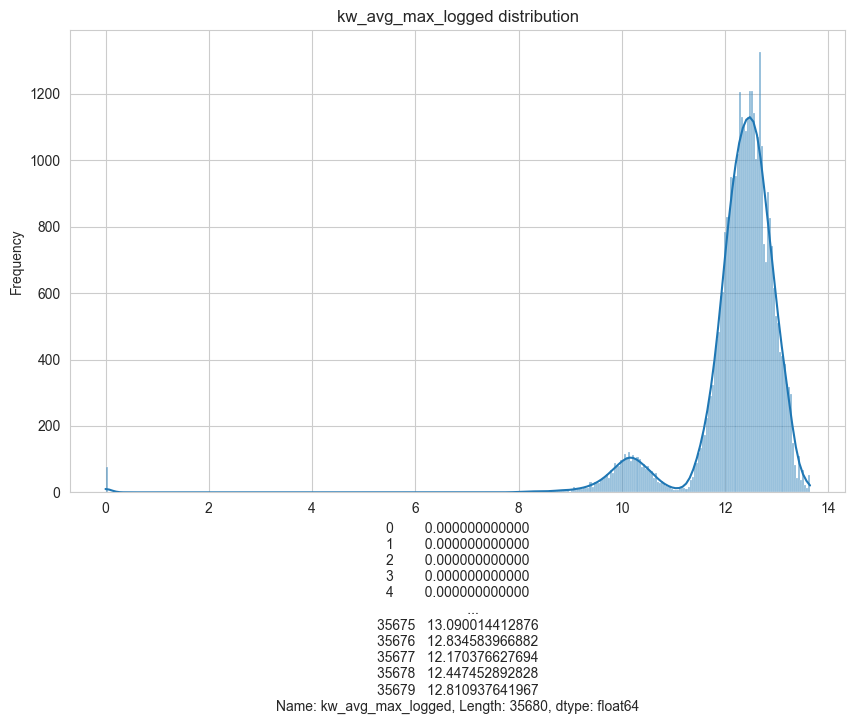

shares_binned        0    1    2    3    4    5    6    7    8    9
kw_avg_max_binned                                                  
0                  463  259  280  363  273  452  382  422  364  310
1                  351  309  367  384  297  421  340  424  354  321
2                  346  407  407  414  317  382  322  326  326  321
3                  375  420  445  409  299  382  301  324  302  311
4                  400  398  453  430  275  356  298  358  309  293
5                  388  423  450  394  319  382  264  353  293  303
6                  364  380  402  405  309  381  275  325  358  366
7                  277  363  415  379  307  397  285  359  372  415
8                  335  302  397  363  321  363  315  387  376  409
9                  286  305  396  387  281  358  302  344  419  489
Chi-Square: 473.58933329922047, p-value: 8.29157497106008e-57
Expected frequencies:
 [[358.5        356.6        401.2        392.8        299.8
  387.4        308.4        362.2      

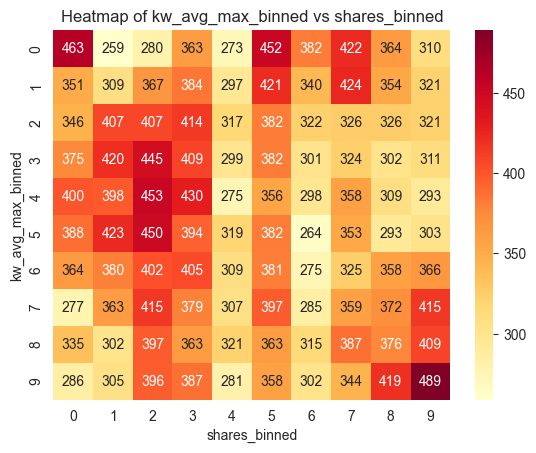

Recalculated Cramer's V: 0.034969473743130884
                            OLS Regression Results                            
Dep. Variable:          shares_logged   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     53.72
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.36e-13
Time:                        20:47:40   Log-Likelihood:                -47957.
No. Observations:               35680   AIC:                         9.592e+04
Df Residuals:                   35678   BIC:                         9.594e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [33]:
# Investigate 'kw_avg_max'.
###############################################################################################################################################################################################################

display(df['kw_avg_max'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_avg_max'].describe()) # Shows a very strange distribution.
display(df['kw_avg_max'].head()) 

print(f" No. of 'kw_avg_max' Unique Values: {df['kw_avg_max'].nunique()}")

# Get the count of unique values in the 'kw_min_min' column, sorted in descending order
kw_avg_max_unique_counts = df.groupby('kw_avg_max').size().sort_values(ascending=False)
print(kw_avg_max_unique_counts) 

df['kw_avg_max_logged'] = np.log1p(df['kw_avg_max'])

create_histogram(x=df['kw_avg_max_logged'], data=df, title='kw_avg_max_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_avg_max_binned'] = pd.qcut(df['kw_avg_max_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_avg_max_binned'], df['shares_binned'])
print(contingency_table) 
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_avg_max_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}")

X = sm.add_constant(df['kw_avg_max_logged'])
y = df['shares_logged']
model = sm.OLS(y, X).fit() # OLS regression (R-squared = 0.0) suggests a negligible linear relationship. indicates that the association is non-linear or driven by specific bin combinations rather than a consistent trend.
print(model.summary())
# The extreme skewness and kurtosis  in residuals suggest that outliers (e.g., shares > 42000) dominate, reducing the model’s explanatory power.

###############################################################################################################################################################################################################


np.int64(0)

count   35680.000000000000
mean     1115.670961350437
std      1136.741357733063
min        -1.000000000000
25%         0.000000000000
50%      1020.667532000000
75%      2058.093422500000
max      3610.124972000000
Name: kw_min_avg, dtype: float64

0   0.000000000000
1   0.000000000000
2   0.000000000000
3   0.000000000000
4   0.000000000000
Name: kw_min_avg, dtype: float64

 No. of 'kw_min_avg' Unique Values: 14686
kw_min_avg
0.000000000000       15396
1100.000000000000      141
1200.000000000000      121
1300.000000000000      104
1400.000000000000      101
                     ...  
3587.938774000000        1
3588.021940000000        1
1104.500000000000        1
1104.625000000000        1
135.000000000000         1
Length: 14686, dtype: int64


c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


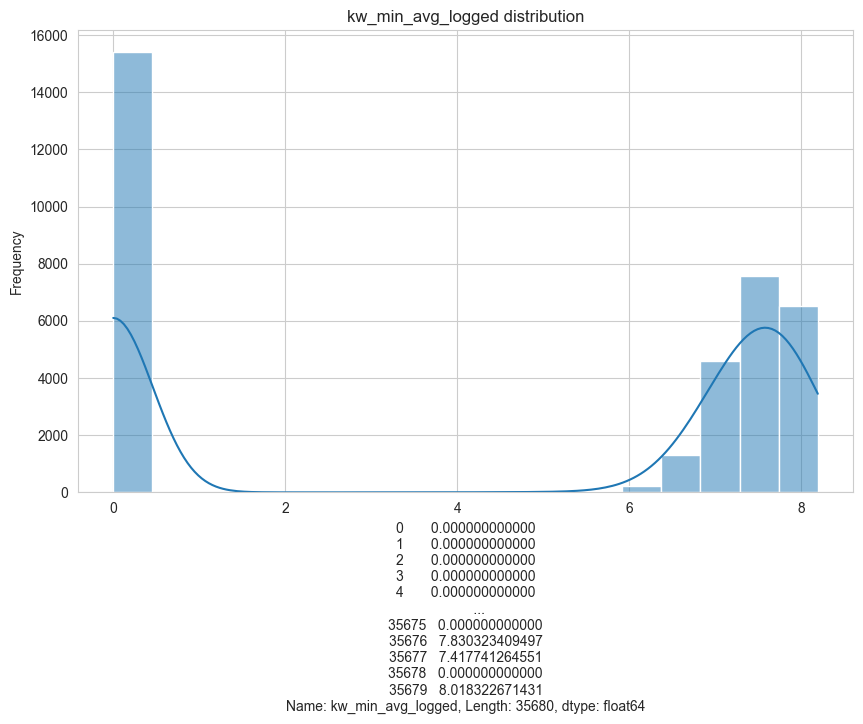

c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


shares_binned        0    1    2    3    4    5    6    7    8    9
kw_min_avg_binned                                                  
1.000000000000     387  368  405  289  181  220  152  171  131  134
2.000000000000     483  463  528  470  305  393  266  227  242  191
3.000000000000     332  370  440  441  358  429  311  344  278  267
4.000000000000     313  356  388  424  325  383  301  396  346  334
5.000000000000     174  213  302  337  314  439  382  468  492  447
6.000000000000     201  226  284  306  258  351  331  416  539  656
Chi-Square: 1602.0923133750393, p-value: 1.4908159604479472e-306
Expected frequencies:
 [[227.23246869 239.97672354 282.17703916 272.5587336  209.31837459
  266.30683499 209.55883223 243.10267285 243.82404576 243.94427458]
 [332.55350626 351.20465529 412.96459217 398.88825328 306.33632508
  389.738633   306.68823355 355.77946543 356.83519085 357.01114508]
 [332.73991518 351.40151889 413.19607456 399.11184535 306.50803827
  389.95709636 306.860144   355

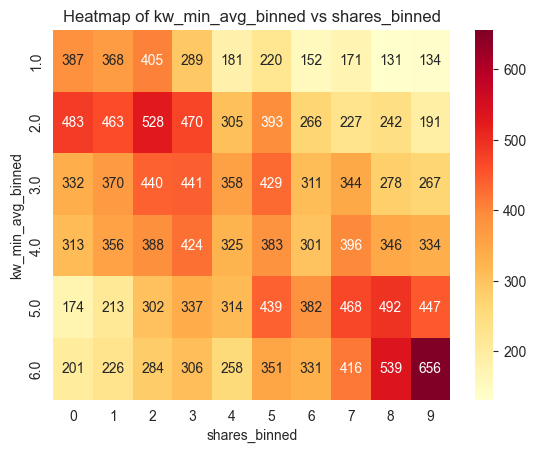

Recalculated Cramer's V: 0.12394039079767448


In [34]:
# Investigate 'kw_min_avg'.
###############################################################################################################################################################################################################

display(df['kw_min_avg'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_min_avg'].describe()) # Shows a very strange distribution.
display(df['kw_min_avg'].head()) 

print(f" No. of 'kw_min_avg' Unique Values: {df['kw_min_avg'].nunique()}") 

# Get the count of unique values in the 'kw_min_avg' column, sorted in descending order
kw_min_avg_unique_counts = df.groupby('kw_min_avg').size().sort_values(ascending=False)
print(kw_min_avg_unique_counts) 

df['kw_min_avg_logged'] = np.log1p(df['kw_min_avg'])

create_histogram(x=df['kw_min_avg_logged'], data=df, title='kw_min_avg_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_min_avg_binned'] = pd.qcut(df['kw_min_avg_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_min_avg_binned'], df['shares_binned'])
print(contingency_table)  
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_min_avg_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}") 

###############################################################################################################################################################################################################


np.int64(0)

count    35680.000000000000
mean      5637.977837673655
std       6026.965361560130
min          0.000000000000
25%       3559.646658000000
50%       4348.584651000000
75%       6015.434737500000
max     298400.000000000000
Name: kw_max_avg, dtype: float64

0   0.000000000000
1   0.000000000000
2   0.000000000000
3   0.000000000000
4   0.000000000000
Name: kw_max_avg, dtype: float64

 No. of 'kw_max_avg' Unique Values: 18053
kw_max_avg
0.000000000000         75
3517.727146000000      41
3483.305109000000      38
3445.033990000000      38
3399.331393000000      34
                       ..
2223.633333000000       1
2322.500000000000       1
2406.375000000000       1
112787.166700000002     1
116503.500000000000     1
Length: 18053, dtype: int64


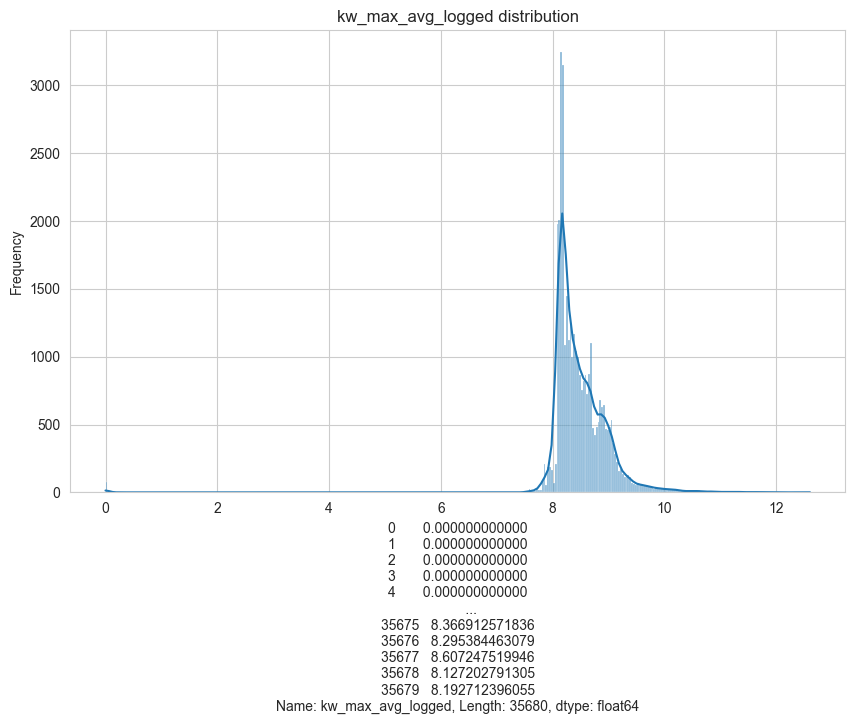

shares_binned        0    1    2    3    4    5    6    7    8    9
kw_max_avg_binned                                                  
0                  662  456  411  390  261  368  295  299  251  175
1                  538  508  553  474  313  358  237  281  188  145
2                  350  453  581  514  333  414  273  270  192  167
3                  348  366  437  407  320  464  318  375  295  233
4                  314  302  379  405  359  404  341  398  361  304
5                  275  312  360  406  315  441  355  413  354  337
6                  331  307  345  367  266  395  340  419  437  361
7                  285  321  348  369  288  367  308  379  418  485
8                  265  273  276  310  282  334  303  379  508  639
9                  217  268  322  286  261  329  314  409  469  692
Chi-Square: 2464.5384072278507, p-value: 0.0
Expected frequencies:
 [[358.5        356.6        401.2        392.8        299.8
  387.4        308.4        362.2        347.3        35

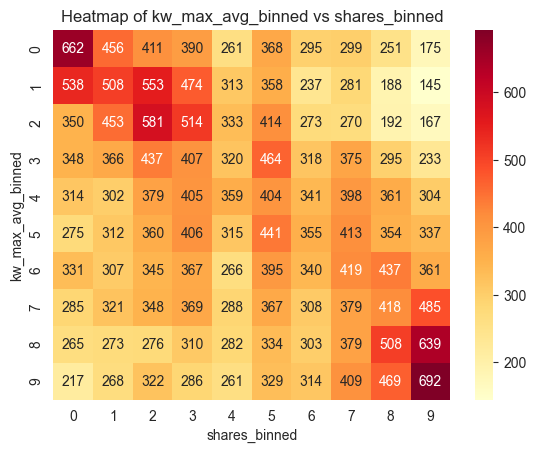

Recalculated Cramer's V: 0.08616521478162757


In [35]:
# Investigate 'kw_max_avg'.
###############################################################################################################################################################################################################

display(df['kw_max_avg'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_max_avg'].describe()) # Shows a very strange distribution.
display(df['kw_max_avg'].head())  

print(f" No. of 'kw_max_avg' Unique Values: {df['kw_max_avg'].nunique()}") 

# Get the count of unique values in the 'kw_max_avg' column, sorted in descending order
kw_max_avg_unique_counts = df.groupby('kw_max_avg').size().sort_values(ascending=False)
print(kw_max_avg_unique_counts) 

df['kw_max_avg_logged'] = np.log1p(df['kw_max_avg'])

create_histogram(x=df['kw_max_avg_logged'], data=df, title='kw_max_avg_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_max_avg_binned'] = pd.qcut(df['kw_max_avg_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_max_avg_binned'], df['shares_binned'])
print(contingency_table)  
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_max_avg_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}") 

###############################################################################################################################################################################################################


np.int64(0)

count   35680.000000000000
mean     3130.799666687934
std      1311.012947828404
min         0.000000000000
25%      2379.762289500000
50%      2867.991455500000
75%      3595.530145250000
max     43567.659950000001
Name: kw_avg_avg, dtype: float64

0   0.000000000000
1   0.000000000000
2   0.000000000000
3   0.000000000000
4   0.000000000000
Name: kw_avg_avg, dtype: float64

 No. of 'kw_avg_avg' Unique Values: 35394
kw_avg_avg
0.000000000000        75
2688.989334000000      6
2902.801465000000      4
2637.319336000000      3
2814.360326000000      3
                      ..
33952.817550000000     1
36023.424520000000     1
36717.233110000001     1
37607.521650000002     1
488.982313500000       1
Length: 35394, dtype: int64


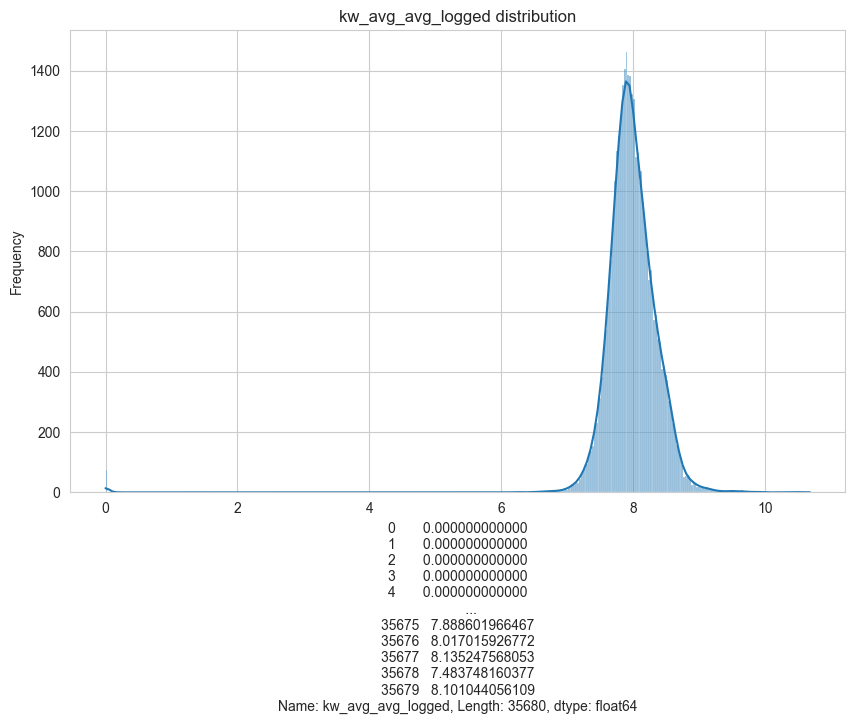

shares_binned        0    1    2    3    4    5    6    7    8    9
kw_avg_avg_binned                                                  
0                  658  460  474  405  294  369  261  260  213  174
1                  510  504  515  423  279  372  254  282  238  191
2                  468  455  494  479  294  383  291  300  226  178
3                  409  416  483  468  321  420  284  325  251  191
4                  325  367  450  431  333  423  308  356  301  274
5                  295  315  367  430  326  437  363  404  360  271
6                  247  300  327  359  313  446  339  448  387  402
7                  256  262  316  348  291  370  357  443  467  458
8                  223  264  319  315  298  332  324  411  495  587
9                  194  223  267  270  249  322  303  393  535  812
Chi-Square: 2830.3408613980655, p-value: 0.0
Expected frequencies:
 [[358.5 356.6 401.2 392.8 299.8 387.4 308.4 362.2 347.3 353.8]
 [358.5 356.6 401.2 392.8 299.8 387.4 308.4 362.2 347

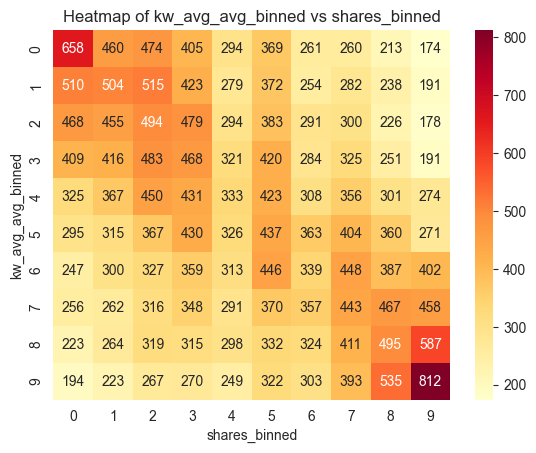

Recalculated Cramer's V: 0.09254121956699152
                            OLS Regression Results                            
Dep. Variable:          shares_logged   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     1219.
Date:                Fri, 08 May 2026   Prob (F-statistic):          1.37e-262
Time:                        20:48:26   Log-Likelihood:                -47385.
No. Observations:               35680   AIC:                         9.477e+04
Df Residuals:                   35678   BIC:                         9.479e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [36]:

# Investigate 'kw_avg_avg'.
###############################################################################################################################################################################################################

display(df['kw_avg_avg'].isnull().sum()) # Shows there are 0 null values.
display(df['kw_avg_avg'].describe()) # Shows a very strange distribution.
display(df['kw_avg_avg'].head()) 

print(f" No. of 'kw_avg_avg' Unique Values: {df['kw_avg_avg'].nunique()}") 

# Get the count of unique values in the 'kw_avg_avg' column, sorted in descending order
kw_avg_avg_unique_counts = df.groupby('kw_avg_avg').size().sort_values(ascending=False)
print(kw_avg_avg_unique_counts) 

df['kw_avg_avg_logged'] = np.log1p(df['kw_avg_avg'])

create_histogram(x=df['kw_avg_avg_logged'], data=df, title='kw_avg_avg_logged distribution', xlabel=None)
# Half a normal distribution with a very long tail on the right. 

df['kw_avg_avg_binned'] = pd.qcut(df['kw_avg_avg_logged'], q=10, labels=False, duplicates='drop')
df['shares_binned'] = pd.qcut(df['shares_logged'], q=10, labels=False, duplicates='drop')
contingency_table = pd.crosstab(df['kw_avg_avg_binned'], df['shares_binned'])
print(contingency_table) 
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square: {chi2}, p-value: {p}") 
print("Expected frequencies:\n", expected)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap of kw_avg_avg_binned vs shares_binned')
plt.show()

n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"Recalculated Cramer's V: {cramers_v}") 

X = sm.add_constant(df['kw_avg_avg_logged'])
y = df['shares_logged']
model = sm.OLS(y, X).fit() # OLS regression (R-squared = 0.0) suggests a negligible linear relationship. indicates that the association is non-linear or driven by specific bin combinations rather than a consistent trend.
print(model.summary())
# The extreme skewness and kurtosis  in residuals suggest that outliers (e.g., shares > 42000) dominate, reducing the model’s explanatory power.
###############################################################################################################################################################################################################


In [37]:
# Model development and training
###############################################################################################################################################################################################################

# Display the current df
display(df.info())

# Separate the data into features and target. 
# Define the list of columns you want
selected_columns = [
    'weekday', 'data_channel', 'n_comments_logged',
    'n_tokens_content_logged', 'n_unique_tokens_logged', 'average_token_length',
    'num_hrefs_logged', 'num_self_hrefs_logged', 'num_imgs_logged', 'average_token_length_logged', 
    'self_reference_min_shares_logged', 'self_reference_max_shares_logged', 'self_reference_avg_shares_logged',
    'kw_min_min_logged', 'kw_max_min_logged', 'kw_avg_min_logged',
    'kw_min_max_logged', 'kw_max_max_logged', 'kw_avg_max_logged',
    'kw_min_avg_logged', 'kw_max_avg_logged', 'kw_avg_avg_logged'
]
# Expanded feature set for better performance (added content, self-ref, and more kw features).
# Trees handle extra/missing features well; preprocessor imputes.

# Create feature matrix X
X = df[selected_columns]

print(X.shape)
print(X.head())
# Show X - Note the uppercases
display(X.head())

# Show y - Note the lowercase
y = df['shares_logged']
print(y.shape)
display(y.head())

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Display the shapes of the splits to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

<class 'pandas.DataFrame'>
RangeIndex: 35680 entries, 0 to 35679
Data columns (total 67 columns):
 #   Column                            Non-Null Count  Dtype        
---  ------                            --------------  -----        
 0   ID                                35680 non-null  int64        
 1   URL                               35680 non-null  str          
 2   timedelta                         35680 non-null  int64        
 3   weekday                           35680 non-null  str          
 4   shares                            35680 non-null  int64        
 5   n_tokens_title                    35680 non-null  int64        
 6   n_tokens_content                  35680 non-null  int64        
 7   n_unique_tokens                   35680 non-null  float64      
 8   n_non_stop_words                  35680 non-null  float64      
 9   n_non_stop_unique_tokens          35680 non-null  float64      
 10  num_hrefs                         35680 non-null  float64      
 11  

None

(35680, 22)
  weekday   data_channel  n_comments_logged  n_tokens_content_logged  \
0  monday  entertainment     0.000000000000           5.393627546352   
1  monday       business     3.367295829986           5.545177444480   
2  monday       business     2.772588722240           5.356586274672   
3  monday  entertainment     4.290459441148           6.276643489342   
4  monday     technology     3.044522437723           6.978213742631   

   n_unique_tokens_logged  average_token_length  num_hrefs_logged  \
0          0.508980602961        4.680365297000    1.609437912434   
1          0.472963669625        4.913725490000    1.386294361120   
2          0.454337510801        4.393364929000    1.386294361120   
3          0.407987177017        4.404896422000    2.302585092994   
4          0.347585693468        4.682835821000    2.995732273554   

   num_self_hrefs_logged  num_imgs_logged  average_token_length_logged  ...  \
0         1.098612288668   0.693147180560               1.737

,weekday,data_channel,n_comments_logged,n_tokens_content_logged,n_unique_tokens_logged,average_token_length,num_hrefs_logged,num_self_hrefs_logged,num_imgs_logged,average_token_length_logged,...,self_reference_avg_shares_logged,kw_min_min_logged,kw_max_min_logged,kw_avg_min_logged,kw_min_max_logged,kw_max_max_logged,kw_avg_max_logged,kw_min_avg_logged,kw_max_avg_logged,kw_avg_avg_logged
0,monday,entertainment,0.000000000000,5.393627546352,0.508980602961,4.680365297000,1.609437912434,1.098612288668,0.693147180560,1.737015543517,...,6.208590026097,4.660382262497,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
1,monday,business,3.367295829986,5.545177444480,0.472963669625,4.913725490000,1.386294361120,0.693147180560,0.693147180560,1.777276003376,...,0.000000000000,4.660382262497,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
2,monday,business,2.772588722240,5.356586274672,0.454337510801,4.393364929000,1.386294361120,0.693147180560,0.693147180560,1.685169481227,...,6.823286122356,4.660382262497,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
3,monday,entertainment,4.290459441148,6.276643489342,0.407987177017,4.404896422000,2.302585092994,0.000000000000,0.693147180560,1.687305287540,...,0.000000000000,4.660382262497,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
4,monday,technology,3.044522437723,6.978213742631,0.347585693468,4.682835821000,2.995732273554,2.995732273554,3.044522437723,1.737450372403,...,8.055842543314,4.660382262497,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000


(35680,)


0   6.386879319363
1   6.568077911412
2   7.313886831633
3   7.090909822080
4   6.226536669287
Name: shares_logged, dtype: float64

Training set shape: (28544, 22) (28544,)
Validation set shape: (3568, 22) (3568,)
Test set shape: (3568, 22) (3568,)


In [40]:
from sklearn.impute import SimpleImputer

# Define numerical features to be standardized
numerical_features = [
    'n_comments_logged',
    'n_tokens_content_logged', 'n_unique_tokens_logged', 'average_token_length',
    'num_hrefs_logged', 'num_self_hrefs_logged', 'num_imgs_logged', 'average_token_length_logged', 
    'self_reference_min_shares_logged', 'self_reference_max_shares_logged', 'self_reference_avg_shares_logged',
    'kw_min_min_logged', 'kw_max_min_logged', 'kw_avg_min_logged',
    'kw_min_max_logged', 'kw_max_max_logged', 'kw_avg_max_logged',
    'kw_min_avg_logged', 'kw_max_avg_logged', 'kw_avg_avg_logged'
]
# Expanded to match selected_columns. Imputer handles any remaining NaNs (e.g. num_videos not included here).

# Create a numerical transformer pipeline. Linear models cannot fit NaN values,
# so impute missing values before scaling.
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Define nominal features to be one-hot encoded
nominal_features = ['weekday', 'data_channel']

# Create a nominal transformer pipeline. 
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features)
    ],
    remainder='drop',
    n_jobs=-1
)

preprocessor # type: ignore

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``"

In [41]:
# ...existing code...
import numpy as np
import pandas as pd

def replace_inf_with_nan(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].replace([np.inf, -np.inf], np.nan)
    return out

X_train = replace_inf_with_nan(X_train)
X_val = replace_inf_with_nan(X_val)

# Optional: quick diagnostics
num_cols = X_train.select_dtypes(include=[np.number]).columns
bad_cols = [c for c in num_cols if not np.isfinite(X_train[c].to_numpy(dtype="float64", na_value=np.nan)).all()]
print("Columns with non-finite values:", bad_cols)

# Ensure your numeric preprocessor includes imputation, e.g.:
# SimpleImputer(strategy="median")
# ...existing code...

# Create the pipeline with a linear regression model. 
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline # type: ignore

# Fit the pipeline to the training data.
lr_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = lr_pipeline.predict(X_val)

display(y_val_pred)

# Calculate regression metrics for validation set.
lr_val_mae = mean_absolute_error(y_val, y_val_pred)
lr_val_mse = mean_squared_error(y_val, y_val_pred)
lr_val_rmse = root_mean_squared_error(y_val, y_val_pred) #RMSE is the square root of MSE
lr_val_r2 = r2_score(y_val, y_val_pred) 

# Display the metrics
print(f"Linear Regression Validation MAE: {lr_val_mae}")
print(f"Linear Regression Validation MSE: {lr_val_mse}")
print(f"Linear Regression Validation RMSE: {lr_val_rmse}")
print(f"Linear Regression Validation R2: {lr_val_r2}")

Columns with non-finite values: ['kw_avg_min_logged', 'kw_min_avg_logged']


array([8.2248774 , 7.30862513, 7.575716  , ..., 7.9941835 , 7.9776905 ,
       7.49378885], shape=(3568,))

Linear Regression Validation MAE: 0.623528471637395
Linear Regression Validation MSE: 0.6903034185460402
Linear Regression Validation RMSE: 0.8308450027207482
Linear Regression Validation R2: 0.207918473214597


In [42]:
# Fit Ridge Regression with lambda (alpha in scikit-learn)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('regressor', Ridge(alpha=1))
])
ridge_pipeline.fit(X_train, y_train)

# Predict on the validation set with Ridge Regression
y_val_pred_ridge = ridge_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Ridge Regression
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = root_mean_squared_error(y_val, y_val_pred_ridge) # RMSE is the square root of MSE.
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

# Display the metrics for Ridge Regression
print("Ridge Regression MetricsL")
print(f"Ridge Validation MAE: {val_mae_ridge}")
print(f"Ridge Validation MSE: {val_mse_ridge}")
print(f"Ridge Validation RMSE: {val_rmse_ridge}")
print(f"Ridge Validation R2: {val_r2_ridge}")

Ridge Regression MetricsL
Ridge Validation MAE: 0.6235387826955154
Ridge Validation MSE: 0.6903011384776895
Ridge Validation RMSE: 0.8308436305814045
Ridge Validation R2: 0.20792108945547294


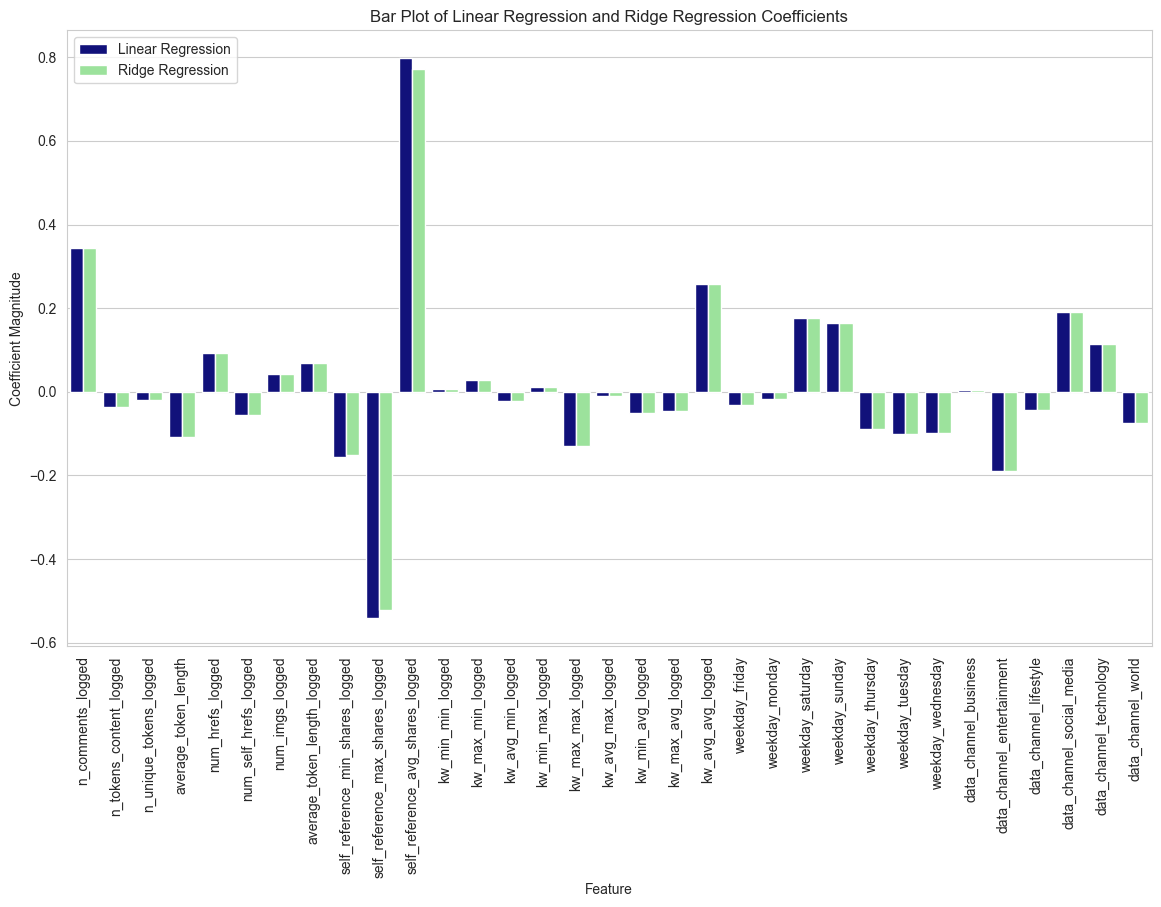

In [43]:
# Extract the coefficients of the linear regression model. 
lr_coefs = lr_pipeline.named_steps['regressor'].coef_

# Extract the oefficients of the ridge regression model. 
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_

# Assuming feature_names contains the names of the features after preprocessing.
feature_names = (
    numerical_features + 
    list(ridge_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(nominal_features))
)

# Create a DataFrame for plotting.
coef_df = pd.DataFrame({ 
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'Ridge Regression': ridge_coefs 
})

# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn. 
plt.figure(figsize=(14,8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'lightgreen'])
plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and Ridge Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True,axis='y')
plt.legend(loc='upper left')
plt.show()


In [45]:
# Create the pipeline with XGBoost regressor
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', 
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

xgb_pipeline # type: ignore

# Fit the XGBoost pipeline to the training data
xgb_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred_xgb = xgb_pipeline.predict(X_val)

# Evaluate XGBoost on validation set
val_mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
val_mse_xgb = mean_squared_error(y_val, y_val_pred_xgb)
val_rmse_xgb = root_mean_squared_error(y_val, y_val_pred_xgb)
val_r2_xgb = r2_score(y_val, y_val_pred_xgb)

print("XGBoost Validation Metrics:")
print(f"Validation MAE: {val_mae_xgb}")
print(f"Validation MSE: {val_mse_xgb}")
print(f"Validation RMSE: {val_rmse_xgb}")
print(f"Validation R²: {val_r2_xgb}")

XGBoost Validation Metrics:
Validation MAE: 0.5049483332196524
Validation MSE: 0.5018064303204296
Validation RMSE: 0.7083829686832043
Validation R²: 0.42420739518266026


In [46]:
# Create the pipeline with LGBM regressor
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(objective='regression', 
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1))
])

lgb_pipeline # type: ignore

# Fit the LGBoost pipeline to the training data
lgb_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred_xgb = lgb_pipeline.predict(X_val)

# Evaluate LGBoost on validation set
val_mae_lgb = mean_absolute_error(y_val, y_val_pred_xgb)
val_mse_lgb = mean_squared_error(y_val, y_val_pred_xgb)
val_rmse_lgb = root_mean_squared_error(y_val, y_val_pred_xgb)
val_r2_lgb = r2_score(y_val, y_val_pred_xgb)

print("LGBM Validation Metrics:")
print(f"Validation MAE: {val_mae_lgb}")
print(f"Validation MSE: {val_mse_lgb}")
print(f"Validation RMSE: {val_rmse_lgb}")
print(f"Validation R²: {val_r2_lgb}")

LGBM Validation Metrics:
Validation MAE: 0.5026204076075148
Validation MSE: 0.4990476624237252
Validation RMSE: 0.7064330558685127
Validation R²: 0.42737291490769747


c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [47]:
# Create the pipeline with RF regressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100, max_depth=5, random_state=42, n_jobs=-1))
])

rf_pipeline # type: ignore

# Fit the RF pipeline to the training data
rf_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred_rf = rf_pipeline.predict(X_val)

# Evaluate RF on validation set
val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
val_mse_rf = mean_squared_error(y_val, y_val_pred_rf)
val_rmse_rf = root_mean_squared_error(y_val, y_val_pred_rf)
val_r2_rf = r2_score(y_val, y_val_pred_rf)

print("RF Validation Metrics:")
print(f"Validation MAE: {val_mae_rf}")
print(f"Validation MSE: {val_mse_rf}")
print(f"Validation RMSE: {val_rmse_rf}")
print(f"Validation R²: {val_r2_rf}")

RF Validation Metrics:
Validation MAE: 0.5364891221616027
Validation MSE: 0.5438913188060426
Validation RMSE: 0.7374898770871656
Validation R²: 0.3759175246261892


In [48]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# ====================== HYPERPARAMETER TUNING FOR LIGHTGBM ======================

# Define the parameter distribution
param_dist = {
    'regressor__n_estimators': [200, 300, 400, 500, 600],
    'regressor__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'regressor__max_depth': [5, 7, 9, 11, -1],           # -1 = no limit
    'regressor__num_leaves': [31, 63, 127, 255],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'regressor__reg_alpha': [0, 0.1, 1, 5],               # L1 regularization
    'regressor__reg_lambda': [0, 0.1, 1, 5],              # L2 regularization
    'regressor__min_child_samples': [5, 10, 20, 30]
}

# Create the pipeline (use your existing preprocessor)
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(
        objective='regression',
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=lgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,                    # Increase to 50-80 if you have time
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

print("Starting hyperparameter tuning for LightGBM...")
random_search.fit(X_train, y_train)

# ====================== RESULTS ======================

print("\n✅ Best Parameters:")
print(random_search.best_params_)

print(f"\nBest Cross-Validation R²: {random_search.best_score_:.5f}")

# Evaluate on Validation Set
best_lgb = random_search.best_estimator_
y_val_pred = best_lgb.predict(X_val) # type: ignore

val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print("\nBest LightGBM Model - Validation Metrics:")
print(f"Validation MAE:  {val_mae:.4f}")
print(f"Validation MSE:  {val_mse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation R²:   {val_r2:.5f}")

Starting hyperparameter tuning for LightGBM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Parameters:
{'regressor__subsample': 1.0, 'regressor__reg_lambda': 0, 'regressor__reg_alpha': 1, 'regressor__num_leaves': 63, 'regressor__n_estimators': 600, 'regressor__min_child_samples': 5, 'regressor__max_depth': -1, 'regressor__learning_rate': 0.03, 'regressor__colsample_bytree': 0.8}

Best Cross-Validation R²: 0.45479

Best LightGBM Model - Validation Metrics:
Validation MAE:  0.5000
Validation MSE:  0.4943
Validation RMSE: 0.7031
Validation R²:   0.43277


c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [49]:
# Save the best model
import joblib
joblib.dump(best_lgb, 'best_lgb_model.pkl')

X_test = replace_inf_with_nan(X_test)
X_val = replace_inf_with_nan(X_val)

# For final test set evaluation
y_test_pred = best_lgb.predict(X_test) # type: ignore
test_r2 = r2_score(y_test, y_test_pred)
print(f"Final Test R²: {test_r2:.5f}")

Final Test R²: 0.45593


c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Top 12 Most Important Features:
                             Feature  Importance
0                  n_comments_logged        4437
18                 kw_max_avg_logged        2564
19                 kw_avg_avg_logged        2482
1            n_tokens_content_logged        2384
16                 kw_avg_max_logged        2377
2             n_unique_tokens_logged        2306
13                 kw_avg_min_logged        2134
12                 kw_max_min_logged        2031
3               average_token_length        1990
4                   num_hrefs_logged        1950
8   self_reference_min_shares_logged        1723
9   self_reference_max_shares_logged        1482


C:\Users\User\AppData\Local\Temp\ipykernel_37800\2331121853.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), y='Feature', x='Importance', palette='viridis')


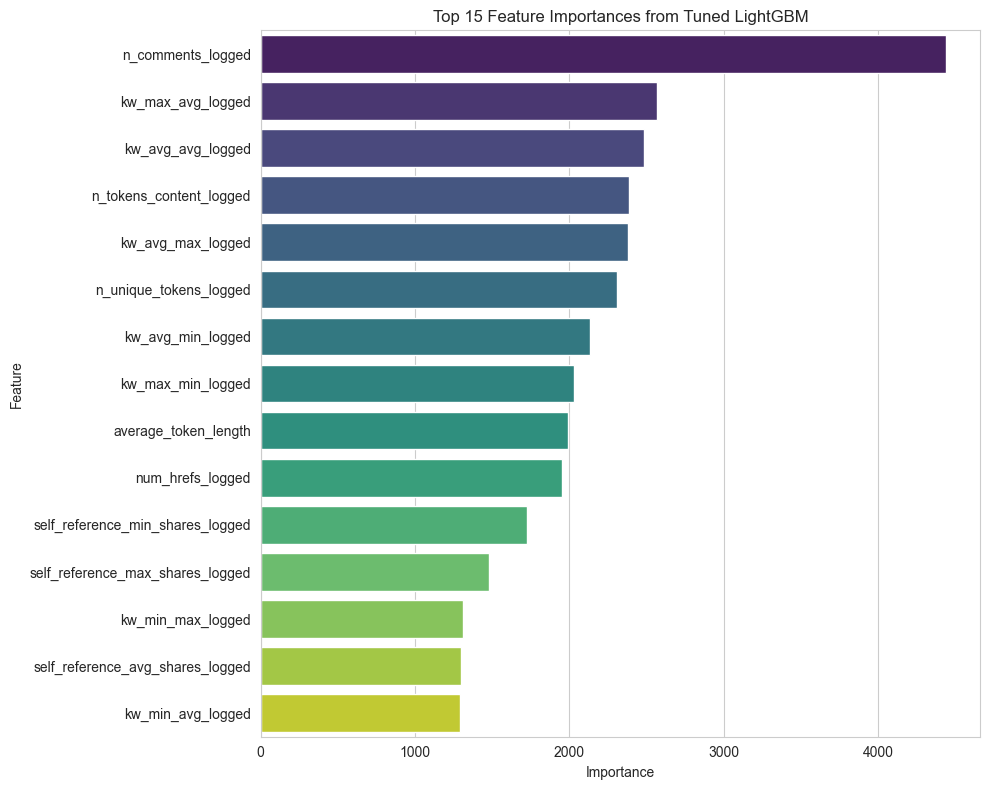

In [51]:
# ====================== FEATURE IMPORTANCE (from Tuned LGBM) ======================
# This helps justify which features matter and can guide further selection.

importances = best_lgb.named_steps['regressor'].feature_importances_ # type: ignore
# Get feature names after preprocessing (onehot expands nominal)
ohe = best_lgb.named_steps['preprocessor'].named_transformers_['nom'].named_steps['onehot'] # type: ignore
nom_feature_names = ohe.get_feature_names_out(nominal_features)
all_feature_names = numerical_features + list(nom_feature_names)

feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 12 Most Important Features:')
print(feat_imp_df.head(12))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df.head(15), y='Feature', x='Importance', palette='viridis')
plt.title('Top 15 Feature Importances from Tuned LightGBM')
plt.tight_layout()
plt.show()

# Optional: Keep only top 20 features for even simpler model
# top_features = feat_imp_df.head(20)['Feature'].tolist()
# Then re-run preprocessor and models with reduced set if desired.

In [55]:

# ====================== STACKING ENSEMBLE (Optional - to improve R² further) ======================
# Combine strong models. Often gives 0.01-0.05 R² lift.

from sklearn.ensemble import StackingRegressor
from sklearn.base import clone

estimators = [
    ('lgb', best_lgb),  # Already a pipeline with preprocessor
    ('xgb', Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('regressor', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42))
    ])),
    ('ridge', Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('regressor', Ridge(alpha=1.0))
    ]))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=0.5),
    cv=5,
    n_jobs=-1
)
print(X_train.head())

stack.fit(X_train, y_train)
y_val_pred_stack = stack.predict(X_val)

print('Stacking Validation R²:', r2_score(y_val, y_val_pred_stack))
print('Stacking Test R²:', r2_score(y_test, stack.predict(X_test)))

# If this improves, save stack as final model instead of best_lgb


         weekday   data_channel  n_comments_logged  n_tokens_content_logged  \
26699     monday      lifestyle     2.197224577336           6.419994928147   
22771     friday     technology     1.386294361120           6.464588303690   
6489     tuesday     technology     1.098612288668           4.997212273764   
32878     monday  entertainment     1.386294361120           6.079933195096   
19885  wednesday  entertainment     0.000000000000           7.404279118037   

       n_unique_tokens_logged  average_token_length  num_hrefs_logged  \
26699          0.424620622804        4.954323002000    3.135494215929   
22771          0.368325560467        4.430577223000    2.639057329615   
6489           0.482851769149        4.863945578000    1.609437912434   
32878          0.393100189276        4.373853211000    1.098612288668   
19885          0.397591051598        4.582825822000    2.079441541680   

       num_self_hrefs_logged  num_imgs_logged  average_token_length_logged  \
26699   

c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Stacking Validation R²: 0.4326794799887512


c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Stacking Test R²: 0.45696875330940134


c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== Test Set Performance (Original Shares Scale) ===
MAE (original shares): 1712.2
MAPE: 65.32%
Median Absolute % Error: 35.60%
R² (log scale): 0.4559


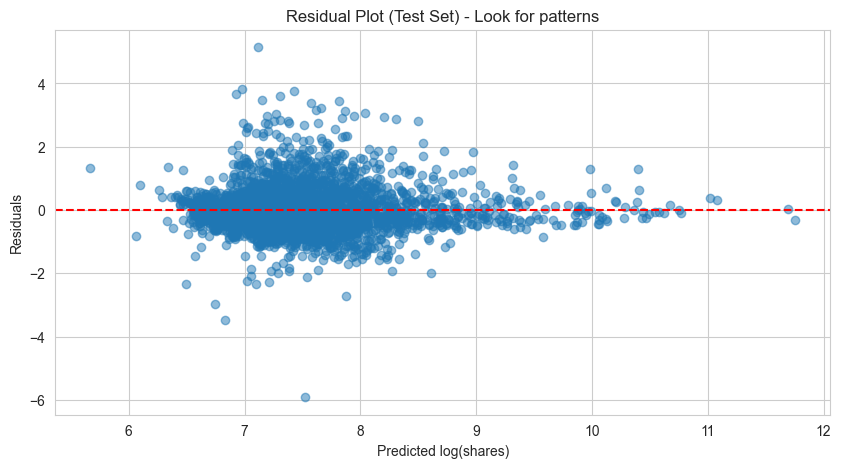


=== How to reach 0.48-0.55 R² ===
1. The expanded feature set + importance already helps.
2. Try Optuna for better hyperparams or more n_iter in RandomizedSearch.
3. Add feature interactions (e.g. PolynomialFeatures on top numericals).
4. Use the Stacking cell above and compare.
5. Engineer more features: is_weekend, kw_engagement_ratio, content_sentiment_interactions.
6. Consider target encoding for data_channel instead of one-hot if high cardinality issues.


In [56]:
# ====================== FINAL EVALUATION & INSIGHTS ======================
# Back-transform to original shares scale for business interpretability

y_test_pred_log = best_lgb.predict(X_test) # type: ignore
y_test_pred = np.expm1(y_test_pred_log)  # back to original scale
y_test_orig = np.expm1(y_test)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test_orig, y_test_pred)
median_ape = np.median(np.abs(y_test_orig - y_test_pred) / (y_test_orig + 1e-8)) * 100

print('=== Test Set Performance (Original Shares Scale) ===')
print(f'MAE (original shares): {mean_absolute_error(y_test_orig, y_test_pred):.1f}')
print(f'MAPE: {mape*100:.2f}%')
print(f'Median Absolute % Error: {median_ape:.2f}%')
print(f'R² (log scale): {r2_score(y_test, y_test_pred_log):.4f}')

# Residual plot
residuals = y_test - y_test_pred_log
plt.figure(figsize=(10, 5))
plt.scatter(y_test_pred_log, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted log(shares)')
plt.ylabel('Residuals')
plt.title('Residual Plot (Test Set) - Look for patterns')
plt.show()

print('\n=== How to reach 0.48-0.55 R² ===')
print('1. The expanded feature set + importance already helps.')
print('2. Try Optuna for better hyperparams or more n_iter in RandomizedSearch.')
print('3. Add feature interactions (e.g. PolynomialFeatures on top numericals).')
print('4. Use the Stacking cell above and compare.')
print('5. Engineer more features: is_weekend, kw_engagement_ratio, content_sentiment_interactions.')
print('6. Consider target encoding for data_channel instead of one-hot if high cardinality issues.')